Loading all data...


/tmp/ipykernel_757318/4191498491.py:126: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat(df_list, ignore_index=True)


Total loaded: 4869 points.
Suppressing count: 2264
Enhancing count:   2210


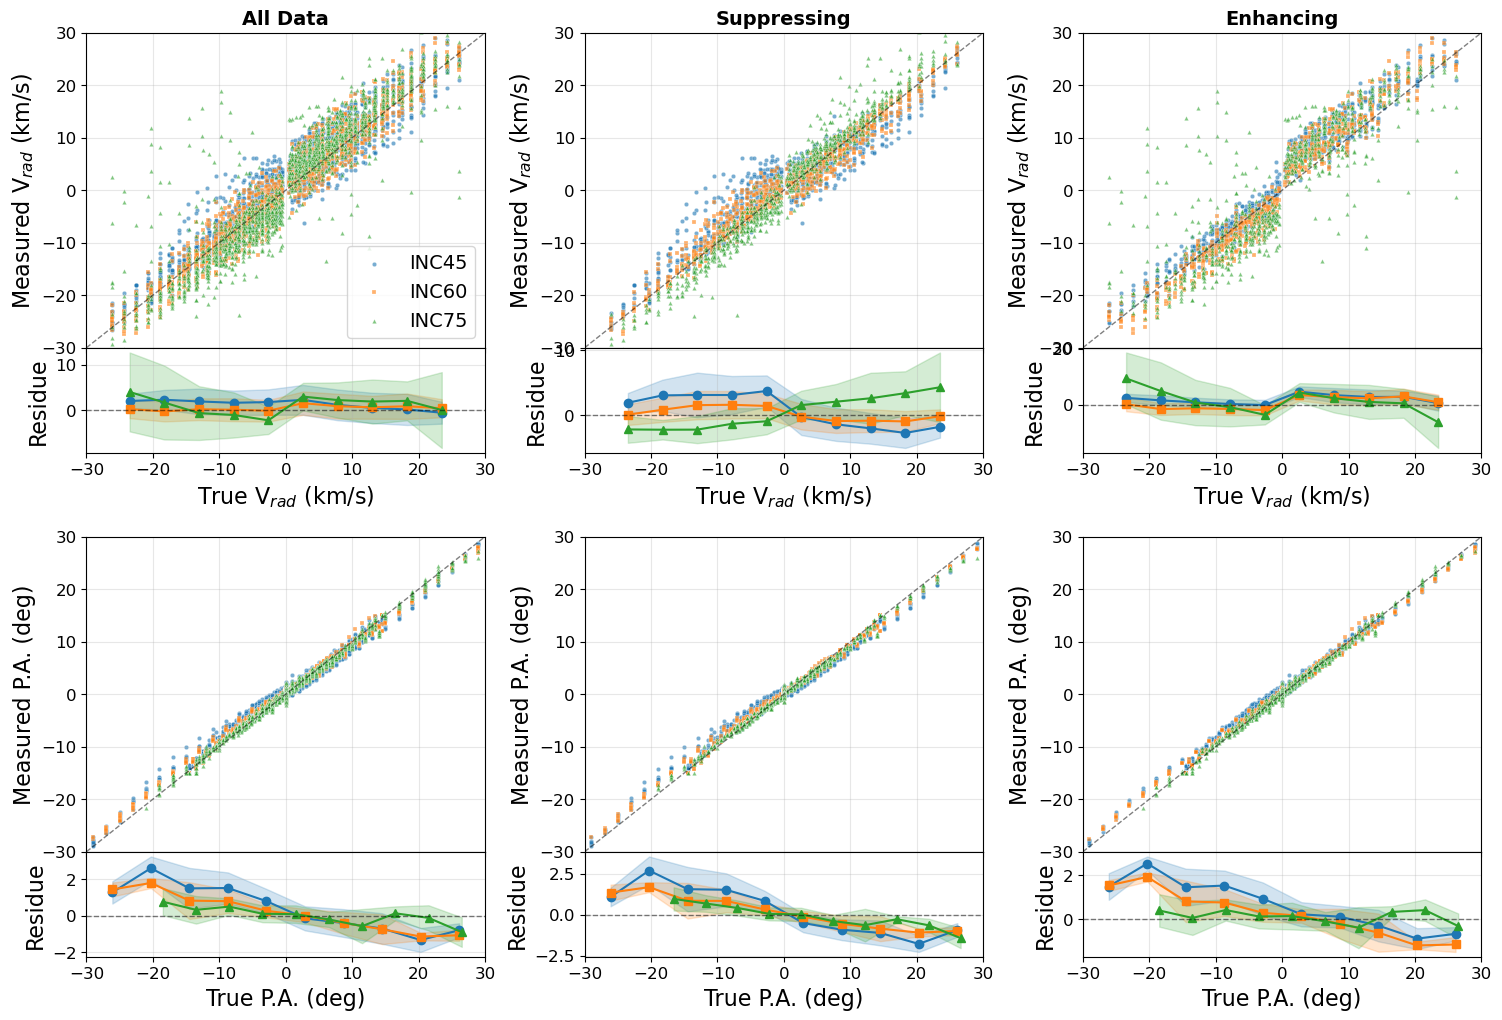

In [13]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ==========================================
# 1. 配置与路径 (CONFIG)
# ==========================================
RING_BASE      = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/"
RING_MODEL1123 = RING_BASE + "model1123/"

INITIAL_BASE   = "/net/dataserver3/data/users/linn/para_initial/test_more_model/"
INITIAL_1123   = "/net/dataserver3/data/users/linn/para_initial/test_more_model/model1123/"

# 绘图样式配置
INC_STYLES = {
    45: dict(color="#1f77b4", marker="o", label="INC45"),
    60: dict(color="#ff7f0e", marker="s", label="INC60"),
    75: dict(color="#2ca02c", marker="^", label="INC75"),
}

# ==========================================
# 2. 文件名解析与辅助函数
# ==========================================
pat_fname = re.compile(
    r"^(?:\d+_)?ring_"
    r"v(?P<v>\d+)_R(?P<R>\d+)_"
    r"(?:(?:PAfixed)|PAk(?P<pa_k>-?\d*\.?\d+)_TP(?P<pa_tp>\d+))_"
    r"VR(?:(?:k(?P<vr_k>-?\d*\.?\d+)_TP(?P<vr_tp>\d+))|(?P<vr_fixed>0))_"
    r"INC(?P<inc>\d+)"
)

def compute_sign(pa_k, vr_k):
    """
    计算 sign:
    sign > 0 (同号) -> 定义为 Suppressing
    sign < 0 (异号) -> 定义为 Enhancing
    """
    if pa_k is None: return 0
    if vr_k is None: return 0
    if vr_k == 0: return 0
    return 1 if pa_k * vr_k > 0 else -1

# ==========================================
# 3. 数据加载函数 (DATA LOADING)
# ==========================================
def load_single_file(file_name, ring_root):
    """读取单个文件的 True vs Measured 数据"""
    m = pat_fname.match(file_name)
    if not m: return None

    g = m.groupdict()
    pa_k = float(g["pa_k"]) if g.get("pa_k") else None
    vr_k = float(g["vr_k"]) if g.get("vr_k") else None
    inc_val = int(g["inc"])

    # 1. 确定 Initial (True) 路径
    if "model1123" in ring_root:
        in_path = os.path.join(INITIAL_1123, file_name)
    else:
        in_path = os.path.join(INITIAL_BASE, file_name)

    if not os.path.exists(in_path): return None

    try: inputf = pd.read_csv(in_path, delimiter=r"\s+")
    except: return None

    # 2. 确定 Measured (Output) 路径
    base_name, _ = os.path.splitext(file_name)
    out_path = os.path.join(ring_root, base_name, "second_step_check_sinw", "rings_final2.txt")
    if not os.path.exists(out_path): return None

    try: outputf = pd.read_csv(out_path, delimiter=r"\s+")
    except: return None

    # 3. 对齐与合并
    n = min(len(inputf), len(outputf))
    df = pd.DataFrame({
        "True_VRAD": inputf["VRAD(km/s)"][:n].values,
        "Measured_VRAD": outputf["VRAD(km/s)"][:n].values,
        "True_PA": inputf["P.A.(deg)"][:n].values,
        "Measured_PA": outputf["P.A.(deg)"][:n].values,
        "INC": inc_val,
        "pa_k": pa_k,
        "vr_k": vr_k,
        "sign": compute_sign(pa_k, vr_k),
        "file": file_name
    })
    
    # 过滤无效点
    df = df[df["True_VRAD"] != 0].reset_index(drop=True)
    return df

def load_all_data():
    """读取所有符合条件的数据"""
    df_list = []
    
    # 1. model1123: INC45, INC75, INC60
    files_1123 = sorted(glob.glob(os.path.join(RING_MODEL1123, "*.txt")))
    for fp in files_1123:
        fname = os.path.basename(fp)
        if "v200" not in fname: continue
        if "INC45" in fname or "INC75" in fname or "INC60" in fname:
            df = load_single_file(fname, RING_MODEL1123)
            if df is not None: df_list.append(df)

    # 2. test_more_model (Base): INC60
    files_base = sorted(glob.glob(os.path.join(RING_BASE, "*.txt")))
    for fp in files_base:
        fname = os.path.basename(fp)
        if "v200" not in fname: continue
        if "INC60" in fname:
            df = load_single_file(fname, RING_BASE)
            if df is not None: df_list.append(df)

    if not df_list:
        print("No data loaded!")
        return pd.DataFrame()
        
    return pd.concat(df_list, ignore_index=True)

# ==========================================
# 4. 绘图与统计函数 (PLOTTING)
# ==========================================
def bin_stats(x_plot, y_plot, nbins=10):
    """计算残差的 Mean 和 1-Sigma"""
    temp_df = pd.DataFrame({'x': np.array(x_plot), 'y': np.array(y_plot)})
    temp_df['res'] = temp_df['y'] - temp_df['x']

    if temp_df['x'].empty:
        return [], [], []
        
    bin_edges = np.linspace(temp_df['x'].min(), temp_df['x'].max(), nbins + 1)
    temp_df['bin_cat'] = pd.cut(temp_df['x'], bins=bin_edges, include_lowest=True)

    grouped = temp_df.groupby('bin_cat', observed=False)
    mean_res = grouped['res'].mean().values
    sigma_res = grouped['res'].std().values
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    return bin_centers, mean_res, sigma_res

def plot_combined_panel(ax_scatter, ax_resid, x, y, inc_col, label_prefix, is_pa=False, show_legend=False):
    """
    画单个Panel: 上部 Scatter, 下部 Residual
    """
    if x.empty or y.empty: return

    for inc, style in INC_STYLES.items():
        sub = inc_col[inc_col == inc].index
        if len(sub) == 0: continue
        
        x_sub = x.loc[sub]
        y_sub = y.loc[sub]
        
        if is_pa:
            x_plot = x_sub - 120
            y_plot = y_sub - 120
        else:
            x_plot = x_sub
            y_plot = y_sub
            
        # --- Scatter ---
        ax_scatter.scatter(
            x_plot, y_plot,
            s=10, alpha=0.6, edgecolor="white", linewidth=0.3,
            **style
        )
        
        # --- Residual ---
        bin_centers, mean_res, sigma_res = bin_stats(x_plot, y_plot)
        if len(bin_centers) > 0:
            ax_resid.plot(bin_centers, mean_res, **style)
            fill_style = {k: v for k, v in style.items() if k not in ['marker', 'label']}
            ax_resid.fill_between(bin_centers, mean_res - sigma_res, mean_res + sigma_res, alpha=0.2, **fill_style)

    # --- 装饰 Scatter ---
    ax_scatter.set_xlim(-30, 30)
    ax_scatter.set_ylim(-30, 30)
    ax_scatter.plot([-30, 30], [-30, 30], "k--", lw=1, alpha=0.5)
    ax_scatter.grid(True, alpha=0.3)
    ax_scatter.set_ylabel(f"Measured {label_prefix}")
    ax_scatter.tick_params(labelbottom=False) # 隐藏Scatter的x轴标签
    
    # 图例只在需要的 Panel 显示
    if show_legend:
        ax_scatter.legend(loc='lower right', fontsize=14, frameon=True)

    # --- 装饰 Residue ---
    ax_resid.axhline(0, color='k', linestyle='--', lw=1, alpha=0.5)
    ax_resid.grid(True, alpha=0.3)
    ax_resid.set_xlabel(f"True {label_prefix}")
    ax_resid.set_ylabel("Residue")
    # sharex 已经自动处理了 X 轴范围

def plot_six_panel_figure(df_all, df_supp, df_enh):
    """
    绘制 2排3列 的大图
    Row 1: VRAD (All, Suppressing, Enhancing)
    Row 2: PA   (All, Suppressing, Enhancing)
    每个子图内部: 上2/3 Scatter, 下1/3 Residual
    """
    fig = plt.figure(figsize=(18, 12))
    
    # 使用 GridSpec 定义外层布局: 2行, 3列
    # height_ratios=[1, 1] 表示上下两排高度一致
    outer_grid = gridspec.GridSpec(2, 3, height_ratios=[1, 1], hspace=0.2, wspace=0.25)

    # 数据集列表 [ (Title, DataFrame), ... ]
    datasets = [
        ("All Data", df_all),
        ("Suppressing", df_supp),
        ("Enhancing", df_enh)
    ]

    # ==========================
    # 第一排: VRAD
    # ==========================
    for col_idx, (name, df) in enumerate(datasets):
        # 在外层 Grid 的对应位置创建一个内层 GridSpec (2行1列, 3:1)
        inner_grid = gridspec.GridSpecFromSubplotSpec(
            2, 1, 
            subplot_spec=outer_grid[0, col_idx], 
            height_ratios=[3, 1], 
            hspace=0.0  # Scatter 和 Residue 紧贴
        )
        
        ax_sc = fig.add_subplot(inner_grid[0])
        ax_rs = fig.add_subplot(inner_grid[1], sharex=ax_sc)
        
        # 仅在第一列显示图例
        show_leg = (col_idx == 0)
        
        plot_combined_panel(
            ax_sc, ax_rs, 
            df["True_VRAD"], df["Measured_VRAD"], df["INC"], 
            label_prefix="V$_{rad}$ (km/s)", is_pa=False, show_legend=show_leg
        )
        
        ax_sc.set_title(f"{name}", fontsize=14, fontweight='bold')

    # ==========================
    # 第二排: P.A.
    # ==========================
    for col_idx, (name, df) in enumerate(datasets):
        # 在外层 Grid 的对应位置创建一个内层 GridSpec
        inner_grid = gridspec.GridSpecFromSubplotSpec(
            2, 1, 
            subplot_spec=outer_grid[1, col_idx], 
            height_ratios=[3, 1], 
            hspace=0.0
        )
        
        ax_sc = fig.add_subplot(inner_grid[0])
        ax_rs = fig.add_subplot(inner_grid[1], sharex=ax_sc)
        
        plot_combined_panel(
            ax_sc, ax_rs, 
            df["True_PA"], df["Measured_PA"], df["INC"], 
            label_prefix="P.A. (deg)", is_pa=True, show_legend=False
        )
        
        #ax_sc.set_title(f"{name} - P.A.", fontsize=14, fontweight='bold')
    plt.savefig("figure3-incforincfixedgalaxies.pdf")
    plt.show()

# ==========================================
# 5. 主执行逻辑 (MAIN)  
# ==========================================
if __name__ == "__main__":
    print("Loading all data...")
    df_all = load_all_data()
    print(f"Total loaded: {len(df_all)} points.")
    
    if not df_all.empty:
        # 拆分数据集
        df_supp = df_all[df_all["sign"] > 0].reset_index(drop=True)
        df_enh  = df_all[df_all["sign"] < 0].reset_index(drop=True)
        
        print(f"Suppressing count: {len(df_supp)}")
        print(f"Enhancing count:   {len(df_enh)}")

        # 绘图
        plot_six_panel_figure(df_all, df_supp, df_enh)

Loading all data...


/tmp/ipykernel_987397/140226587.py:128: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat(df_list, ignore_index=True)


Total loaded: 4869 points.
Suppressing count: 2264
Enhancing count:   2210


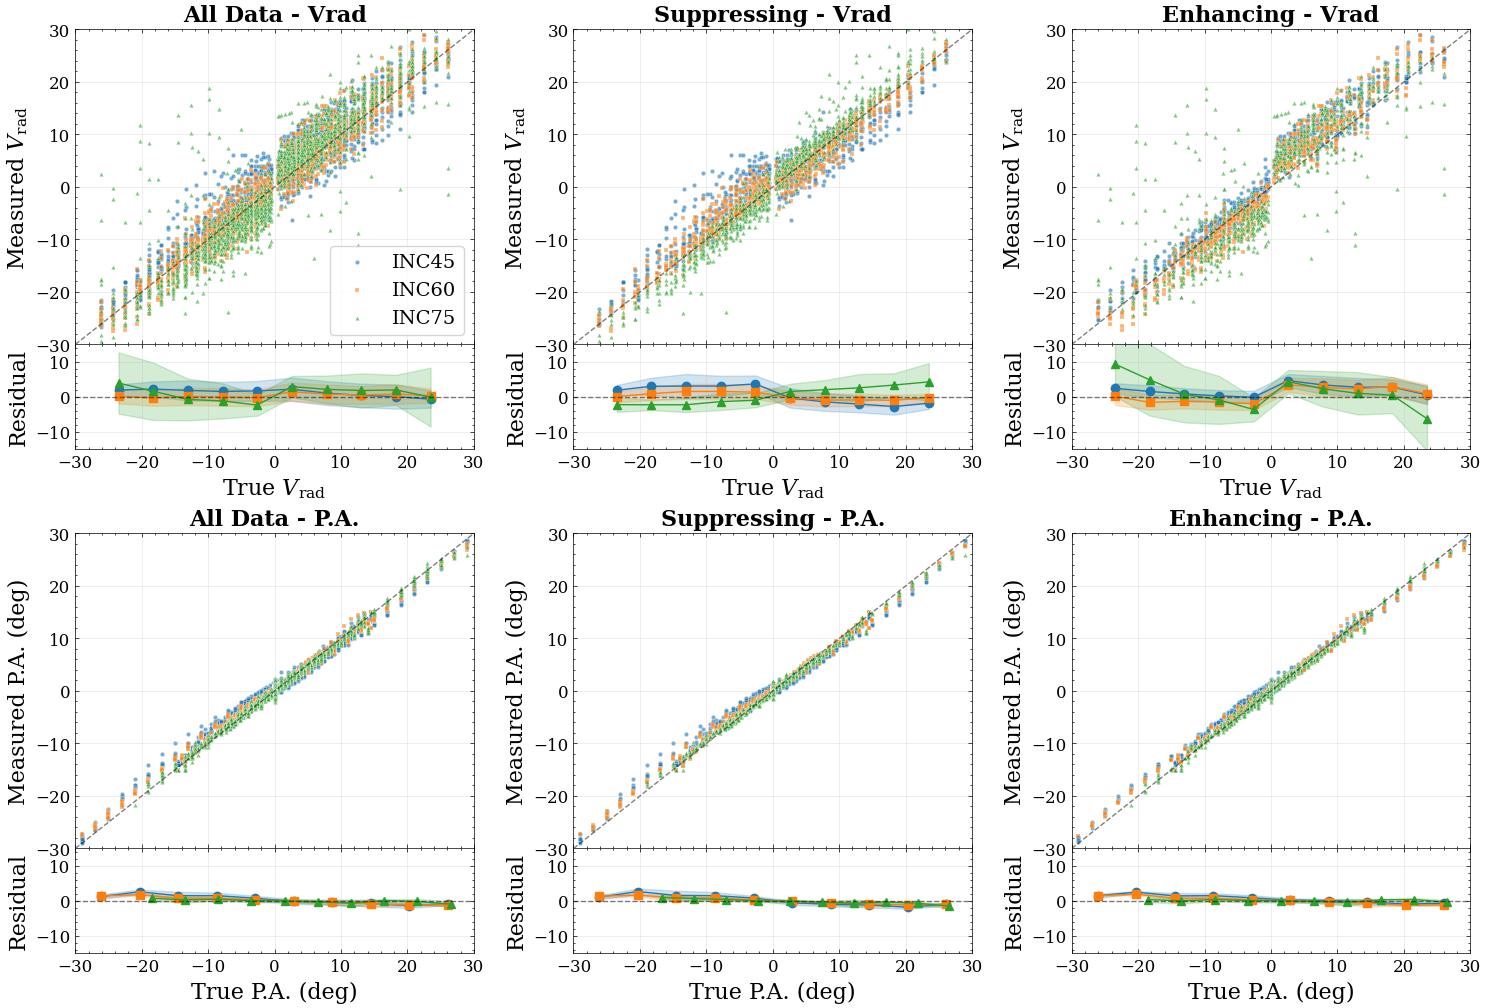

In [3]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ==========================================
# 1. 配置与路径 (CONFIG)
# ==========================================

plt.style.use("/net/dataserver3/data/users/linn/pic_style/science3.mplstyle")
RING_BASE      = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/"
RING_MODEL1123 = RING_BASE + "model1123/"

INITIAL_BASE   = "/net/dataserver3/data/users/linn/para_initial/test_more_model/"
INITIAL_1123   = "/net/dataserver3/data/users/linn/para_initial/test_more_model/model1123/"

# 绘图样式配置
INC_STYLES = {
    45: dict(color="#1f77b4", marker="o", label="INC45"),
    60: dict(color="#ff7f0e", marker="s", label="INC60"),
    75: dict(color="#2ca02c", marker="^", label="INC75"),
}

# ==========================================
# 2. 文件名解析与辅助函数
# ==========================================
pat_fname = re.compile(
    r"^(?:\d+_)?ring_"
    r"v(?P<v>\d+)_R(?P<R>\d+)_"
    r"(?:(?:PAfixed)|PAk(?P<pa_k>-?\d*\.?\d+)_TP(?P<pa_tp>\d+))_"
    r"VR(?:(?:k(?P<vr_k>-?\d*\.?\d+)_TP(?P<vr_tp>\d+))|(?P<vr_fixed>0))_"
    r"INC(?P<inc>\d+)"
)

def compute_sign(pa_k, vr_k):
    """
    计算 sign:
    sign > 0 (同号) -> 定义为 Suppressing
    sign < 0 (异号) -> 定义为 Enhancing
    """
    if pa_k is None: return 0
    if vr_k is None: return 0
    if vr_k == 0: return 0
    return 1 if pa_k * vr_k > 0 else -1

# ==========================================
# 3. 数据加载函数 (DATA LOADING)
# ==========================================
def load_single_file(file_name, ring_root):
    """读取单个文件的 True vs Measured 数据"""
    m = pat_fname.match(file_name)
    if not m: return None

    g = m.groupdict()
    pa_k = float(g["pa_k"]) if g.get("pa_k") else None
    vr_k = float(g["vr_k"]) if g.get("vr_k") else None
    inc_val = int(g["inc"])

    # 1. 确定 Initial (True) 路径
    if "model1123" in ring_root:
        in_path = os.path.join(INITIAL_1123, file_name)
    else:
        in_path = os.path.join(INITIAL_BASE, file_name)

    if not os.path.exists(in_path): return None

    try: inputf = pd.read_csv(in_path, delimiter=r"\s+")
    except: return None

    # 2. 确定 Measured (Output) 路径
    base_name, _ = os.path.splitext(file_name)
    out_path = os.path.join(ring_root, base_name, "second_step_check_sinw", "rings_final2.txt")
    if not os.path.exists(out_path): return None

    try: outputf = pd.read_csv(out_path, delimiter=r"\s+")
    except: return None

    # 3. 对齐与合并
    n = min(len(inputf), len(outputf))
    df = pd.DataFrame({
        "True_VRAD": inputf["VRAD(km/s)"][:n].values,
        "Measured_VRAD": outputf["VRAD(km/s)"][:n].values,
        "True_PA": inputf["P.A.(deg)"][:n].values,
        "Measured_PA": outputf["P.A.(deg)"][:n].values,
        "INC": inc_val,
        "pa_k": pa_k,
        "vr_k": vr_k,
        "sign": compute_sign(pa_k, vr_k),
        "file": file_name
    })
    
    # 过滤无效点
    df = df[df["True_VRAD"] != 0].reset_index(drop=True)
    return df

def load_all_data():
    """读取所有符合条件的数据"""
    df_list = []
    
    # 1. model1123: INC45, INC75, INC60
    files_1123 = sorted(glob.glob(os.path.join(RING_MODEL1123, "*.txt")))
    for fp in files_1123:
        fname = os.path.basename(fp)
        if "v200" not in fname: continue
        if "INC45" in fname or "INC75" in fname or "INC60" in fname:
            df = load_single_file(fname, RING_MODEL1123)
            if df is not None: df_list.append(df)

    # 2. test_more_model (Base): INC60
    files_base = sorted(glob.glob(os.path.join(RING_BASE, "*.txt")))
    for fp in files_base:
        fname = os.path.basename(fp)
        if "v200" not in fname: continue
        if "INC60" in fname:
            df = load_single_file(fname, RING_BASE)
            if df is not None: df_list.append(df)

    if not df_list:
        print("No data loaded!")
        return pd.DataFrame()
        
    return pd.concat(df_list, ignore_index=True)

# ==========================================
# 4. 绘图与统计函数 (PLOTTING)
# ==========================================
def bin_stats(x_plot, y_plot, nbins=10):
    """计算残差的 Mean 和 1-Sigma"""
    temp_df = pd.DataFrame({'x': np.array(x_plot), 'y': np.array(y_plot)})
    temp_df['res'] = temp_df['y'] - temp_df['x']

    if temp_df['x'].empty:
        return [], [], []
        
    bin_edges = np.linspace(temp_df['x'].min(), temp_df['x'].max(), nbins + 1)
    temp_df['bin_cat'] = pd.cut(temp_df['x'], bins=bin_edges, include_lowest=True)

    grouped = temp_df.groupby('bin_cat', observed=False)
    mean_res = grouped['res'].mean().values
    sigma_res = grouped['res'].std().values
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    return bin_centers, mean_res, sigma_res

def plot_combined_panel(ax_scatter, ax_resid, x, y, inc_col, label_prefix, is_pa=False, show_legend=False):
    """
    画单个Panel: 上部 Scatter, 下部 Residual
    """
    if x.empty or y.empty: return

    for inc, style in INC_STYLES.items():
        sub = inc_col[inc_col == inc].index
        if len(sub) == 0: continue
        
        x_sub = x.loc[sub]
        y_sub = y.loc[sub]
        
        if is_pa:
            x_plot = x_sub - 120
            y_plot = y_sub - 120
        else:
            x_plot = x_sub
            y_plot = y_sub
            
        # --- Scatter ---
        ax_scatter.scatter(
            x_plot, y_plot,
            s=10, alpha=0.6, edgecolor="white", linewidth=0.3,
            **style
        )
        
        # --- Residual ---
        bin_centers, mean_res, sigma_res = bin_stats(x_plot, y_plot)
        if len(bin_centers) > 0:
            ax_resid.plot(bin_centers, mean_res, **style)
            fill_style = {k: v for k, v in style.items() if k not in ['marker', 'label']}
            ax_resid.fill_between(bin_centers, mean_res - sigma_res, mean_res + sigma_res, alpha=0.2, **fill_style)

    # --- 装饰 Scatter ---
    ax_scatter.set_xlim(-30, 30)
    ax_scatter.set_ylim(-30, 30)
    ax_scatter.plot([-30, 30], [-30, 30], "k--", lw=1, alpha=0.5)
    ax_scatter.grid(True, alpha=0.3)
    ax_scatter.set_ylabel(f"Measured {label_prefix}")
    ax_scatter.tick_params(labelbottom=False) # 隐藏Scatter的x轴标签
    
    # 图例只在需要的 Panel 显示
    if show_legend:
        ax_scatter.legend(loc='lower right', fontsize=14, frameon=True)

    # --- 装饰 Residue ---
    ax_resid.set_ylim(-15, 15)
    ax_resid.axhline(0, color='k', linestyle='--', lw=1, alpha=0.5)
    ax_resid.grid(True, alpha=0.3)
    ax_resid.set_xlabel(f"True {label_prefix}")
    ax_resid.set_ylabel("Residual")
    # sharex 已经自动处理了 X 轴范围

def plot_six_panel_figure(df_all, df_supp, df_enh):
    """
    绘制 2排3列 的大图
    Row 1: VRAD (All, Suppressing, Enhancing)
    Row 2: PA   (All, Suppressing, Enhancing)
    每个子图内部: 上2/3 Scatter, 下1/3 Residual
    """
    fig = plt.figure(figsize=(18, 12))
    
    # 使用 GridSpec 定义外层布局: 2行, 3列
    # height_ratios=[1, 1] 表示上下两排高度一致
    outer_grid = gridspec.GridSpec(2, 3, height_ratios=[1, 1], hspace=0.2, wspace=0.25)

    # 数据集列表 [ (Title, DataFrame), ... ]
    datasets = [
        ("All Data", df_all),
        ("Suppressing", df_supp),
        ("Enhancing", df_enh)
    ]

    # ==========================
    # 第一排: VRAD
    # ==========================
    for col_idx, (name, df) in enumerate(datasets):
        # 在外层 Grid 的对应位置创建一个内层 GridSpec (2行1列, 3:1)
        inner_grid = gridspec.GridSpecFromSubplotSpec(
            2, 1, 
            subplot_spec=outer_grid[0, col_idx], 
            height_ratios=[3, 1], 
            hspace=0.0  # Scatter 和 Residue 紧贴
        )
        
        ax_sc = fig.add_subplot(inner_grid[0])
        ax_rs = fig.add_subplot(inner_grid[1], sharex=ax_sc)
        
        # 仅在第一列显示图例
        show_leg = (col_idx == 0)
        
        plot_combined_panel(
            ax_sc, ax_rs, 
            df["True_VRAD"], df["Measured_VRAD"], df["INC"], 
            label_prefix=r"$V_{\rm rad}$", is_pa=False, show_legend=show_leg
        )
        
        ax_sc.set_title(f"{name} - Vrad", fontsize=16, fontweight='bold')

    # ==========================
    # 第二排: P.A.
    # ==========================
    for col_idx, (name, df) in enumerate(datasets):
        # 在外层 Grid 的对应位置创建一个内层 GridSpec
        inner_grid = gridspec.GridSpecFromSubplotSpec(
            2, 1, 
            subplot_spec=outer_grid[1, col_idx], 
            height_ratios=[3, 1], 
            hspace=0.0
        )
        
        ax_sc = fig.add_subplot(inner_grid[0])
        ax_rs = fig.add_subplot(inner_grid[1], sharex=ax_sc)
        
        plot_combined_panel(
            ax_sc, ax_rs, 
            df["True_PA"], df["Measured_PA"], df["INC"], 
            label_prefix="P.A. (deg)", is_pa=True, show_legend=False
        )
        
        ax_sc.set_title(f"{name} - P.A.", fontsize=16, fontweight='bold')
    plt.savefig("figure3-incforincfixedgalaxies.pdf")
    plt.show()

# ==========================================
# 5. 主执行逻辑 (MAIN)  
# ==========================================
if __name__ == "__main__":
    print("Loading all data...")
    df_all = load_all_data()
    print(f"Total loaded: {len(df_all)} points.")
    
    if not df_all.empty:
        # 拆分数据集
        df_supp = df_all[df_all["sign"] > 0].reset_index(drop=True)
        df_enh  = df_all[df_all["sign"] < 0].reset_index(drop=True)
        
        print(f"Suppressing count: {len(df_supp)}")
        print(f"Enhancing count:   {len(df_enh)}")

        # 绘图
        plot_six_panel_figure(df_all, df_supp, df_enh)

In [2]:
def quantify_performance(df):
    """
    计算不同 INC 下的统计指标：Bias, Scatter (Std), RMSE
    """
    if df.empty:
        return

    # 定义要计算的变量
    targets = [
        ("VRAD", "True_VRAD", "Measured_VRAD"),
        ("P.A.", "True_PA",   "Measured_PA")
    ]
    
    results = []

    # 按 INC 分组计算
    for inc_val, group in df.groupby("INC"):
        row = {"INC": inc_val}
        
        for name, col_true, col_meas in targets:
            # 计算残差
            # 对于 PA，如果涉及到周期性(比如跨越360度)需要特殊处理，但这里假设是局部变化
            # 如果 PA 是 -120 这种偏移量，直接相减即可
            residuals = group[col_meas] - group[col_true]
            
            # 1. Bias (平均偏差)
            bias = np.mean(residuals)
            
            # 2. Scatter (标准差)
            scatter = np.std(residuals)
            
            # 3. RMSE (均方根误差) - 最核心的排名指标
            rmse = np.sqrt(np.mean(residuals**2))
            
            # 4. Outlier Rate (比如残差 > 3倍整体Sigma的比例) - 可选
            # global_sigma = df[col_meas].sub(df[col_true]).std()
            # outlier_rate = (np.abs(residuals) > 3 * global_sigma).mean() * 100

            # 存入字典，保留2位小数方便查看
            row[f"{name}_Bias"]    = f"{bias:.3f}"
            row[f"{name}_Scatter"] = f"{scatter:.3f}"
            row[f"{name}_RMSE"]    = rmse  # 保持数值以便排序
        
        results.append(row)

    # 转为 DataFrame
    res_df = pd.DataFrame(results)
    
    # 格式化一下显示
    # 我们把 RMSE 作为数值保留，方便找出最小值
    return res_df

# ================= 使用示例 =================
if __name__ == "__main__":
    # 假设你已经运行了前面的代码，内存里有 df_all
    # 如果没有，请先运行 load_all_data()
    # df_all = load_all_data() 
    
    print("\n========== Performance Quantification ==========")
    metrics_df = quantify_performance(df_all)
    
    # 为了展示好看，我们可以单独打印 VRAD 和 PA 的排名
    
    print("\n--- VRAD Performance (Ranked by RMSE, Lower is Better) ---")
    vrad_cols = ["INC", "VRAD_RMSE", "VRAD_Bias", "VRAD_Scatter"]
    print(metrics_df[vrad_cols].sort_values("VRAD_RMSE").to_string(index=False))

    print("\n--- P.A. Performance (Ranked by RMSE, Lower is Better) ---")
    pa_cols = ["INC", "P.A._RMSE", "P.A._Bias", "P.A._Scatter"]
    print(metrics_df[pa_cols].sort_values("P.A._RMSE").to_string(index=False))


========== Performance Quantification ==========

--- VRAD Performance (Ranked by RMSE, Lower is Better) ---
 INC  VRAD_RMSE VRAD_Bias VRAD_Scatter
  60   2.631732     0.462        2.591
  45   3.432409     1.470        3.102
  75   5.207487     0.659        5.166

--- P.A. Performance (Ranked by RMSE, Lower is Better) ---
 INC  P.A._RMSE P.A._Bias P.A._Scatter
  75   0.603488     0.050        0.601
  60   0.772431     0.172        0.753
  45   1.195027     0.504        1.084


Loading data...
All: 4869, Supp: 2264, Enh: 2210
Saved to dispersion_3col_split.pdf


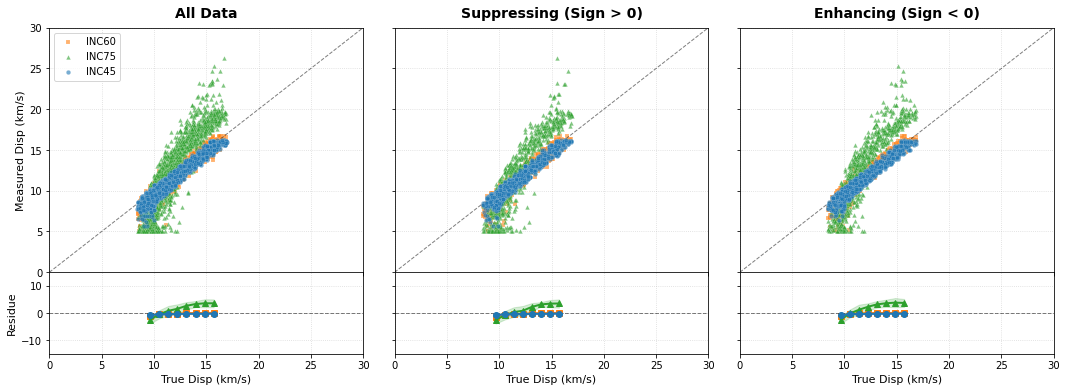

In [9]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ==========================================
# 1. 配置与路径 (CONFIG)
# ==========================================
RING_MODEL1123 = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/model1123/"
RING_ALL       = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/"

INITIAL_BASE   = "/net/dataserver3/data/users/linn/para_initial/test_more_model/"
INITIAL_1123   = "/net/dataserver3/data/users/linn/para_initial/test_more_model/model1123/"

# 绘图样式配置 (加入 zorder 控制图层顺序)
INC_STYLES = {
    60: dict(color="#ff7f0e", marker="s", label="INC60", zorder=2), # 最底层
    75: dict(color="#2ca02c", marker="^", label="INC75", zorder=3),
    45: dict(color="#1f77b4", marker="o", label="INC45", zorder=4), # 最上层
}

# ==========================================
# 2. 文件名解析逻辑 (用于区分 Enhance/Suppress)
# ==========================================
# 正则表达式：用于提取 pa_k 和 vr_k
pat_fname = re.compile(
    r"^(?:\d+_)?ring_"
    r"v(?P<v>\d+)_R(?P<R>\d+)_"
    r"(?:(?:PAfixed)|PAk(?P<pa_k>-?\d*\.?\d+)_TP(?P<pa_tp>\d+))_"
    r"VR(?:(?:k(?P<vr_k>-?\d*\.?\d+)_TP(?P<vr_tp>\d+))|(?P<vr_fixed>0))_"
    r"INC(?P<inc>\d+)"
)

def compute_sign(pa_k, vr_k):
    """
    sign > 0 (同号) -> Suppressing
    sign < 0 (异号) -> Enhancing
    """
    if pa_k is None: return 0
    if vr_k is None: return 0
    if vr_k == 0: return 0
    return 1 if pa_k * vr_k > 0 else -1

# ==========================================
# 3. 数据加载函数
# ==========================================
def load_single_file(file_name, ring_root):
    # 解析文件名参数
    m = pat_fname.match(file_name)
    if not m: return None

    g = m.groupdict()
    pa_k = float(g["pa_k"]) if g.get("pa_k") else None
    vr_k = float(g["vr_k"]) if g.get("vr_k") else None
    inc_val = int(g["inc"])

    # 确定路径
    if "model1123" in ring_root:
        in_path = os.path.join(INITIAL_1123, file_name)
    else:
        in_path = os.path.join(INITIAL_BASE, file_name)

    if not os.path.exists(in_path): return None

    try: inputf = pd.read_csv(in_path, delimiter=r"\s+")
    except: return None

    base_name, _ = os.path.splitext(file_name)
    out_path = os.path.join(ring_root, base_name, "second_step_check_sinw", "rings_final2.txt")
    if not os.path.exists(out_path): return None

    try: outputf = pd.read_csv(out_path, delimiter=r"\s+")
    except: return None

    n = min(len(inputf), len(outputf))
    
    # 查找 Dispersion 列名
    col_disp_true = next((c for c in ["VDISP(km/s)", "DISP(km/s)", "DISP"] if c in inputf.columns), None)
    col_disp_meas = next((c for c in ["VDISP(km/s)", "DISP(km/s)", "DISP"] if c in outputf.columns), None)

    true_disp = inputf[col_disp_true][:n].values if col_disp_true else np.zeros(n)
    meas_disp = outputf[col_disp_meas][:n].values if col_disp_meas else np.zeros(n)
    true_vrad = inputf["VRAD(km/s)"][:n].values if "VRAD(km/s)" in inputf.columns else np.zeros(n)

    df = pd.DataFrame({
        "True_DISP": true_disp,
        "Measured_DISP": meas_disp,
        "True_VRAD": true_vrad,
        "INC": inc_val,
        "sign": compute_sign(pa_k, vr_k)
    })
    
    # 过滤无效点 (根据 VRAD!=0 的逻辑，保留主要区域)
    df = df[df["True_VRAD"] != 0].reset_index(drop=True)
    return df

def load_all_data():
    df_list = []
    # 1. model1123: INC45, INC75
    for fp in sorted(glob.glob(os.path.join(RING_MODEL1123, "*.txt"))):
        fname = os.path.basename(fp)
        if "v200" in fname and ("INC45" in fname or "INC75" in fname):
            df = load_single_file(fname, RING_MODEL1123)
            if df is not None: df_list.append(df)
    # 2. Base: INC60
    for fp in sorted(glob.glob(os.path.join(RING_ALL, "*.txt"))):
        fname = os.path.basename(fp)
        if "v200" in fname and "INC60" in fname:
            df = load_single_file(fname, RING_ALL)
            if df is not None: df_list.append(df)
    # 3. model1123: INC60 (补全)
    for fp in sorted(glob.glob(os.path.join(RING_MODEL1123, "*.txt"))):
        fname = os.path.basename(fp)
        if "v200" in fname and "INC60" in fname:
            df = load_single_file(fname, RING_MODEL1123)
            if df is not None: df_list.append(df)

    if not df_list: return pd.DataFrame()
    return pd.concat(df_list, ignore_index=True)

# ==========================================
# 4. 绘图核心函数
# ==========================================
def bin_stats(x_plot, y_plot, nbins=8):
    temp_df = pd.DataFrame({'x': np.array(x_plot), 'y': np.array(y_plot)})
    temp_df['res'] = temp_df['y'] - temp_df['x']
    if temp_df['x'].empty: return [], [], []
    
    bin_edges = np.linspace(temp_df['x'].min(), temp_df['x'].max(), nbins + 1)
    temp_df['bin_cat'] = pd.cut(temp_df['x'], bins=bin_edges, include_lowest=True)
    grouped = temp_df.groupby('bin_cat', observed=False)
    
    return 0.5 * (bin_edges[:-1] + bin_edges[1:]), grouped['res'].mean().values, grouped['res'].std().values

def plot_single_panel(ax_scatter, ax_resid, df_subset, show_ylabel=False, show_legend=False):
    """画单个子图：包含 Scatter (带抖动) 和 Residual"""
    if df_subset.empty: return

    x_col, y_col = "True_DISP", "Measured_DISP"

    for inc, style in INC_STYLES.items():
        sub_df = df_subset[df_subset["INC"] == inc]
        if sub_df.empty: continue
        
        x_raw = sub_df[x_col].values
        y_raw = sub_df[y_col].values
        
        # --- 核心修改：添加 Jitter (抖动) ---
        # 生成随机噪声，范围 [-0.8, 0.8]
        jitter = np.random.uniform(-0.8, 0.8, len(x_raw))
        x_jittered = x_raw + jitter
        
        # 1. Scatter
        ax_scatter.scatter(
            x_jittered, y_raw,
            s=20, alpha=0.6, edgecolor="white", linewidth=0.2, # 调小点的大小和边框
            **style
        )
        
        # 2. Residual (用原始数据计算!)
        bc, mean_r, sig_r = bin_stats(x_raw, y_raw)
        if len(bc) > 0:
            ax_resid.plot(bc, mean_r, lw=2, **style)
            fstyle = {k:v for k,v in style.items() if k not in ['marker','label','zorder']}
            ax_resid.fill_between(bc, mean_r-sig_r, mean_r+sig_r, alpha=0.2, **fstyle)

    # 装饰
    limit_min, limit_max = 0, 30
    ax_scatter.set_xlim(limit_min, limit_max)
    ax_scatter.set_ylim(limit_min, limit_max)
    ax_scatter.plot([limit_min, limit_max], [limit_min, limit_max], "k--", lw=1, alpha=0.5)
    ax_scatter.grid(True, ls=':', alpha=0.5)
    
    # 标签控制
    if show_ylabel:
        ax_scatter.set_ylabel("Measured Disp (km/s)", fontsize=11)
        ax_resid.set_ylabel("Residue", fontsize=11)
    else:
        ax_scatter.tick_params(labelleft=False)
        ax_resid.tick_params(labelleft=False)
        
    ax_scatter.tick_params(labelbottom=False)
    ax_resid.set_xlabel("True Disp (km/s)", fontsize=11)
    ax_resid.axhline(0, c='k', ls='--', lw=1, alpha=0.5)
    ax_resid.set_ylim(-15, 15)
    ax_resid.grid(True, ls=':', alpha=0.5)
    
    if show_legend:
        ax_scatter.legend(loc='upper left', fontsize=10, frameon=True)

def plot_3_column_dispersion(df_all, df_supp, df_enh):
    """
    绘制 1排3列: All | Suppressing | Enhancing
    """
    fig = plt.figure(figsize=(18, 6)) # 宽一点，矮一点
    
    # 外层 GridSpec: 1行3列
    outer = gridspec.GridSpec(1, 3, wspace=0.1)
    
    datasets = [
        ("All Data", df_all),
        ("Suppressing (Sign > 0)", df_supp),
        ("Enhancing (Sign < 0)", df_enh)
    ]
    
    for i, (title, data) in enumerate(datasets):
        # 内层 GridSpec: 2行1列 (Scatter:Residual = 3:1)
        inner = gridspec.GridSpecFromSubplotSpec(
            2, 1, subplot_spec=outer[i], height_ratios=[3, 1], hspace=0.0
        )
        
        ax_sc = fig.add_subplot(inner[0])
        ax_rs = fig.add_subplot(inner[1], sharex=ax_sc)
        
        # 只在第一列显示 Y 轴标签和图例
        is_first = (i == 0)
        
        plot_single_panel(ax_sc, ax_rs, data, show_ylabel=is_first, show_legend=is_first)
        ax_sc.set_title(title, fontsize=14, fontweight='bold', pad=10)

    out_file = "dispersion_3col_split.pdf"
    fig.savefig(out_file, dpi=150, bbox_inches='tight')
    print(f"Saved to {out_file}")

# ==========================================
# 5. 主执行 (MAIN)
# ==========================================
if __name__ == "__main__":
    print("Loading data...")
    df = load_all_data()
    
    if not df.empty:
        # 拆分数据
        df_supp = df[df["sign"] > 0]
        df_enh  = df[df["sign"] < 0]
        
        print(f"All: {len(df)}, Supp: {len(df_supp)}, Enh: {len(df_enh)}")
        plot_3_column_dispersion(df, df_supp, df_enh)
    else:
        print("No data found.")

In [10]:
def quantify_performance_by_mode(df):
    """
    分别计算 Suppressing 和 Enhancing 模式下的 RMSE，并按 INC 对比
    """
    if df.empty:
        print("Data is empty.")
        return

    results = []
    
    # 按倾角分组，因为我们已知倾角对结果影响很大
    for inc_val in sorted(df["INC"].unique()):
        # 获取当前 INC 的数据
        df_inc = df[df["INC"] == inc_val]
        
        # 拆分 Suppressing (Sign > 0) 和 Enhancing (Sign < 0)
        df_supp = df_inc[df_inc["sign"] > 0]
        df_enh  = df_inc[df_inc["sign"] < 0]
        
        row = {"INC": inc_val}
        
        # --- Helper: 计算 RMSE ---
        def calc_rmse(subset, col_true, col_meas):
            if subset.empty: return np.nan
            res = subset[col_meas] - subset[col_true]
            return np.sqrt(np.mean(res**2))
            
        # --- 1. VRAD RMSE ---
        row["VRAD_RMSE_Supp"] = calc_rmse(df_supp, "True_VRAD", "Measured_VRAD")
        row["VRAD_RMSE_Enh"]  = calc_rmse(df_enh,  "True_VRAD", "Measured_VRAD")
        
        # --- 2. PA RMSE ---
        row["PA_RMSE_Supp"] = calc_rmse(df_supp, "True_PA", "Measured_PA")
        row["PA_RMSE_Enh"]  = calc_rmse(df_enh,  "True_PA", "Measured_PA")

        # --- 3. Dispersion RMSE (如果有) ---
        if "True_DISP" in df.columns:
            row["DISP_RMSE_Supp"] = calc_rmse(df_supp, "True_DISP", "Measured_DISP")
            row["DISP_RMSE_Enh"]  = calc_rmse(df_enh,  "True_DISP", "Measured_DISP")

        results.append(row)

    # 创建 DataFrame 并格式化
    res_df = pd.DataFrame(results)
    
    # 计算 Diff (Enhancing - Suppressing)，正值代表 Enhancing 误差更大
    res_df["VRAD_Diff"] = res_df["VRAD_RMSE_Enh"] - res_df["VRAD_RMSE_Supp"]
    res_df["PA_Diff"]   = res_df["PA_RMSE_Enh"]   - res_df["PA_RMSE_Supp"]
    
    return res_df

# ================= 主执行部分 =================
if __name__ == "__main__":
    # 假设你已经加载了 df_all
    # df_all = load_all_data() 
    
    print("\n========== RMSE Comparison: Suppressing vs Enhancing ==========")
    comp_df = quantify_performance_by_mode(df_all)
    
    # 设置打印格式，保留3位小数
    pd.options.display.float_format = '{:.3f}'.format
    
    # 打印结果
    print(comp_df.to_string(index=False))


========== RMSE Comparison: Suppressing vs Enhancing ==========
 INC  VRAD_RMSE_Supp  VRAD_RMSE_Enh  PA_RMSE_Supp  PA_RMSE_Enh  VRAD_Diff  PA_Diff
  45           3.698          3.348         1.293        1.165     -0.350   -0.129
  60           2.209          3.200         0.805        0.802      0.991   -0.003
  75           3.358          6.811         0.620        0.631      3.453    0.012


In [11]:
# 筛选 Sign = 0 的数据
df_neutral = df_all[df_all["sign"] == 0]
rmse_neutral = np.sqrt(np.mean((df_neutral["Measured_PA"] - df_neutral["True_PA"])**2))
print(f"Neutral (Sign=0) RMSE: {rmse_neutral}")

Neutral (Sign=0) RMSE: 0.4158003263495653


In [4]:
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ==========================================
# 1. 配置与路径 (CONFIG)
# ==========================================
# Updated base path to the SNR testing directory
RING_BASE = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/snr_res_testing/"
INITIAL_BASE = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/snr_res_testing/new_res_output"

# Define SNR styles (Common values based on your filename: 10, 20, 50, etc.)
# If SNR is continuous, we could use a colormap, but keeping the style-dict for consistency.
SNR_STYLES = {
    10: dict(color="#d62728", marker="o", label="SNR 10"),
    20: dict(color="#ff7f0e", marker="s", label="SNR 20"),
    5: dict(color="#2ca02c", marker="^", label="SNR 5"),
}

# ==========================================
# 2. 文件名解析 (Updated for SNR)
# ==========================================
# Example: ring_v200_R50_PAfixed_VR0_INC75_Res15_SNR10
pat_fname = re.compile(
    r"^ring_"
    r"v(?P<v>\d+)_R(?P<R>\d+)_"
    r"(?P<pa_mode>PAfixed|(?:PAk(?P<pa_k>-?\d*\.?\d+)_TP(?P<pa_tp>\d+)))_"
    r"(?P<vr_mode>VR(?:(?:k(?P<vr_k>-?\d*\.?\d+)_TP(?P<vr_tp>\d+))|(?P<vr_fixed>0)))_"
    r"INC(?P<inc>\d+)_Res(?P<res>\d+)_SNR(?P<snr>\d+)"
)

def compute_sign(pa_k, vr_k):
    if pa_k is None or vr_k is None or vr_k == 0: return 0
    return 1 if float(pa_k) * float(vr_k) > 0 else -1

# ==========================================
# 3. 数据加载函数
# ==========================================
def load_single_file(file_name, ring_root):
    m = pat_fname.match(file_name)
    if not m: return None

    g = m.groupdict()
    snr_val = int(g["snr"])
    pa_k = g.get("pa_k")
    vr_k = g.get("vr_k")

    # Path for True (Initial) data
    in_path = os.path.join(INITIAL_BASE, file_name + ".txt" if not file_name.endswith(".txt") else file_name)
    
    # Path for Measured (Output) data
    base_name = file_name.replace(".txt", "")
    out_path = os.path.join(ring_root, base_name, "second_step_check_sinw", "rings_final2.txt")

    if not os.path.exists(in_path) or not os.path.exists(out_path):
        return None

    try:
        inputf = pd.read_csv(in_path, delimiter=r"\s+")
        outputf = pd.read_csv(out_path, delimiter=r"\s+")
        
        n = min(len(inputf), len(outputf))
        df = pd.DataFrame({
            "True_VRAD": inputf["VRAD(km/s)"][:n].values,
            "Measured_VRAD": outputf["VRAD(km/s)"][:n].values,
            "True_PA": inputf["P.A.(deg)"][:n].values,
            "Measured_PA": outputf["P.A.(deg)"][:n].values,
            "SNR": snr_val,
            "sign": compute_sign(pa_k, vr_k),
        })
        return df[df["True_VRAD"] != 0].reset_index(drop=True)
    except Exception as e:
        return None

def load_all_data():
    df_list = []
    # Search for directories or files in the SNR testing folder
    files = sorted(glob.glob(os.path.join(RING_BASE, "ring_*")))
    for fp in files:
        fname = os.path.basename(fp)
        # Filters
        if "v200" not in fname: continue
        
        df = load_single_file(fname, RING_BASE)
        if df is not None: df_list.append(df)

    return pd.concat(df_list, ignore_index=True) if df_list else pd.DataFrame()

# ==========================================
# 4. 绘图逻辑 (Updated for SNR)
# ==========================================
def bin_stats(x_plot, y_plot, nbins=10):
    temp_df = pd.DataFrame({'x': x_plot, 'y': y_plot})
    temp_df['res'] = temp_df['y'] - temp_df['x']
    if temp_df.empty: return [], [], []
    
    bin_edges = np.linspace(temp_df['x'].min(), temp_df['x'].max(), nbins + 1)
    temp_df['bin_cat'] = pd.cut(temp_df['x'], bins=bin_edges, include_lowest=True)
    grouped = temp_df.groupby('bin_cat', observed=False)
    
    return 0.5 * (bin_edges[:-1] + bin_edges[1:]), grouped['res'].mean().values, grouped['res'].std().values

def plot_combined_panel(ax_scatter, ax_resid, x, y, snr_col, label_prefix, is_pa=False, show_legend=False):
    if x.empty: return

    # Loop through SNR categories instead of INC
    unique_snrs = sorted(snr_col.unique())
    for snr in unique_snrs:
        mask = (snr_col == snr)
        if not mask.any(): continue
        
        style = SNR_STYLES.get(snr, dict(color="gray", marker=".", label=f"SNR {snr}"))
        
        x_p = (x[mask] - 120) if is_pa else x[mask]
        y_p = (y[mask] - 120) if is_pa else y[mask]

        ax_scatter.scatter(x_p, y_p, s=12, alpha=0.5, edgecolor="none", **style)
        
        # Residuals
        centers, mean_res, sigma_res = bin_stats(x_p, y_p)
        if len(centers) > 0:
            ax_resid.plot(centers, mean_res, color=style['color'], lw=1.5)
            ax_resid.fill_between(centers, mean_res - sigma_res, mean_res + sigma_res, color=style['color'], alpha=0.15)

    ax_scatter.set_xlim(-35, 35)
    ax_scatter.set_ylim(-35, 35)
    ax_scatter.plot([-35, 35], [-35, 35], "k--", alpha=0.5)
    ax_scatter.set_ylabel(f"Measured {label_prefix}")
    if show_legend: ax_scatter.legend(loc='upper left', fontsize=10)

    ax_resid.axhline(0, color='k', linestyle='--', alpha=0.5)
    ax_resid.set_xlabel(f"True {label_prefix}")
    ax_resid.set_ylabel("Residue")

def plot_six_panel_figure(df_all):
    df_supp = df_all[df_all["sign"] > 0]
    df_enh = df_all[df_all["sign"] < 0]
    
    fig = plt.figure(figsize=(18, 11))
    outer_grid = gridspec.GridSpec(2, 3, hspace=0.3, wspace=0.3)
    datasets = [("All Data", df_all), ("Suppressing", df_supp), ("Enhancing", df_enh)]

    for row_idx, (lab, is_pa) in enumerate([("V$_{rad}$ (km/s)", False), ("P.A. (deg)", True)]):
        for col_idx, (name, df) in enumerate(datasets):
            inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_grid[row_idx, col_idx], height_ratios=[3, 1], hspace=0.0)
            ax_sc = fig.add_subplot(inner[0])
            ax_rs = fig.add_subplot(inner[1], sharex=ax_sc)
            
            col_name = "True_PA" if is_pa else "True_VRAD"
            meas_name = "Measured_PA" if is_pa else "Measured_VRAD"
            
            plot_combined_panel(ax_sc, ax_rs, df[col_name], df[meas_name], df["SNR"], lab, is_pa, (col_idx==0 and row_idx==0))
            ax_sc.set_title(f"{name} ({'P.A.' if is_pa else 'Vrad'})", fontsize=12, fontweight='bold')

    plt.savefig("figure_snr_analysis.pdf", bbox_inches='tight')
    plt.show()

if __name__ == "__main__":
    data = load_all_data()
    if not data.empty:
        plot_six_panel_figure(data)
    else:
        print("No matching data found in the SNR directory.")

No matching data found in the SNR directory.


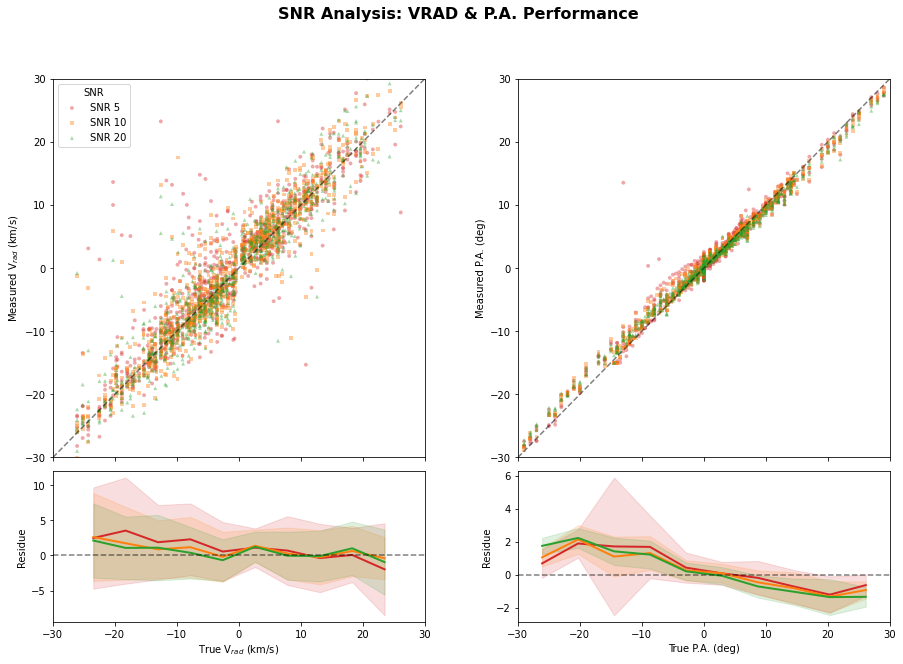

In [6]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ==========================================
# 1. 配置与路径 (CONFIG)
# ==========================================
# 测量结果 (Barolo 输出) 所在的基础目录
RING_MODEL1123 = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/snr_res_testing/"

# 真值 (Initial) 文件的路径 (根据你提供的参考代码)
INITIAL_1123 = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/snr_res_testing/new_res_output"

# ==========================================
# 2. 样式配置 (按 SNR 分类)
# ==========================================
# 颜色代码现在对应 SNR
SNR_STYLES = {
    5:  dict(color="#d62728", marker="o", label="SNR 5"),   # 红
    10: dict(color="#ff7f0e", marker="s", label="SNR 10"),  # 橙
    20: dict(color="#2ca02c", marker="^", label="SNR 20"),  # 绿
}

# ==========================================
# 3. 文件名解析与辅助函数
# ==========================================
# 匹配示例: ring_v200_R50_PAk-0.2_TP10_VRk0.2_TP10_INC75_Res15.txt
pat_fname = re.compile(
    r"^(?:\d+_)?ring_"
    r"v(?P<v>\d+)_R(?P<R>\d+)_"
    r"(?:(?:PAfixed)|PAk(?P<pa_k>-?\d*\.?\d+)_TP(?P<pa_tp>-?\d*\.?\d+))_"
    r"VR(?:(?:k(?P<vr_k>-?\d*\.?\d+)_TP(?P<vr_tp>-?\d*\.?\d+))|(?P<vr_fixed>0))_"
    r"INC(?P<inc>\d+)_Res(?P<res>\d+)\.txt$"
)

def compute_sign(pa_k, vr_k):
    if pa_k is None or vr_k is None or vr_k == 0: return 0
    return 1 if pa_k * vr_k > 0 else -1

# ==========================================
# 4. 数据加载函数 (DATA LOADING)
# ==========================================
def load_vrad_multi_snr(file_name, ring_root):
    """
    自动加载 True 值并匹配 SNR 5, 10, 20 的输出文件夹
    """
    m = pat_fname.match(file_name)
    if not m: return None

    g = m.groupdict()
    pa_k = float(g["pa_k"]) if g["pa_k"] else None
    vr_k = float(g["vr_k"]) if g["vr_k"] else None
    inc_val = int(g["inc"])
    res_val = int(g["res"])

    # 1. 读取真值 (Initial 文件)
    in_path = os.path.join(INITIAL_1123, file_name)
    if not os.path.exists(in_path): return None

    try:
        inputf = pd.read_csv(in_path, delimiter=r"\s+")
    except:
        return None

    true_v = inputf["VRAD(km/s)"].values
    true_pa = inputf["P.A.(deg)"].values

    df_list = []

    # 2. 遍历该文件对应的不同 SNR 文件夹
    for snr in [5, 10, 20]:
        # 对应文件夹名: ring_..._Res15_SNR5
        folder_name = file_name.replace(".txt", f"_SNR{snr}")
        out_path = os.path.join(ring_root, folder_name, "second_step_check_sinw", "rings_final2.txt")

        if not os.path.exists(out_path): continue

        try:
            outputf = pd.read_csv(out_path, delimiter=r"\s+")
            n = min(len(true_v), len(outputf))
            
            df = pd.DataFrame({
                "True_VRAD": true_v[:n],
                "Measured_VRAD": outputf["VRAD(km/s)"][:n].values,
                "True_PA": true_pa[:n],
                "Measured_PA": outputf["P.A.(deg)"][:n].values,
                "INC": inc_val,
                "SNR": snr,
                "sign": compute_sign(pa_k, vr_k)
            })
            # 过滤无效点
            df = df[df["True_VRAD"] != 0].reset_index(drop=True)
            df_list.append(df)
        except:
            continue

    return pd.concat(df_list, ignore_index=True) if df_list else None

def load_all_data():
    df_list = []
    # 查找所有含有 Res 的 .txt 文件作为索引
    files = sorted(glob.glob(os.path.join(RING_MODEL1123, "*Res*.txt")))
    
    for fp in files:
        fname = os.path.basename(fp)
        df = load_vrad_multi_snr(fname, RING_MODEL1123)
        if df is not None:
            df_list.append(df)

    return pd.concat(df_list, ignore_index=True) if df_list else pd.DataFrame()

# ==========================================
# 5. 绘图函数 (PLOTTING)
# ==========================================
def bin_stats(x_plot, y_plot, nbins=10):
    temp_df = pd.DataFrame({'x': np.array(x_plot), 'y': np.array(y_plot)})
    temp_df['res'] = temp_df['y'] - temp_df['x']
    if temp_df.empty: return [], [], []
    
    bin_edges = np.linspace(temp_df['x'].min(), temp_df['x'].max(), nbins + 1)
    temp_df['bin_cat'] = pd.cut(temp_df['x'], bins=bin_edges, include_lowest=True)
    grouped = temp_df.groupby('bin_cat', observed=False)
    
    return 0.5 * (bin_edges[:-1] + bin_edges[1:]), grouped['res'].mean().values, grouped['res'].std().values

def plot_combined_panel(ax_scatter, ax_resid, x, y, snr_col, label_prefix, is_pa=False):
    """
    按 SNR 渲染颜色
    """
    for snr, style in SNR_STYLES.items():
        mask = (snr_col == snr)
        if not mask.any(): continue
        
        x_sub = x[mask]
        y_sub = y[mask]
        
        # P.A. 减去 120 归零显示
        x_p = (x_sub - 120) if is_pa else x_sub
        y_p = (y_sub - 120) if is_pa else y_sub

        ax_scatter.scatter(x_p, y_p, s=15, alpha=0.4, edgecolor="none", **style)
        
        # 统计线
        centers, mean_res, sigma_res = bin_stats(x_p, y_p, nbins=10)
        if len(centers) > 0:
            ax_resid.plot(centers, mean_res, lw=2, color=style['color'])
            ax_resid.fill_between(centers, mean_res - sigma_res, mean_res + sigma_res, color=style['color'], alpha=0.15)

    ax_scatter.set_xlim(-30, 30)
    ax_scatter.set_ylim(-30, 30)
    ax_scatter.plot([-30, 30], [-30, 30], "k--", alpha=0.5)
    ax_scatter.set_ylabel(f"Measured {label_prefix}")
    ax_scatter.tick_params(labelbottom=False)

    ax_resid.axhline(0, color='k', linestyle='--', alpha=0.5)
    ax_resid.set_xlabel(f"True {label_prefix}")
    ax_resid.set_ylabel("Residue")

def plot_snr_figure(df_all, title):
    if df_all.empty: return
    fig = plt.figure(figsize=(15, 10))
    fig.suptitle(title, fontsize=16, fontweight='bold')
    gs = gridspec.GridSpec(2, 2, height_ratios=[2.5, 1], hspace=0.05, wspace=0.25)

    # VRAD Panel
    ax_v_sc = fig.add_subplot(gs[0, 0])
    ax_v_rs = fig.add_subplot(gs[1, 0], sharex=ax_v_sc)
    plot_combined_panel(ax_v_sc, ax_v_rs, df_all["True_VRAD"], df_all["Measured_VRAD"], df_all["SNR"], "V$_{rad}$ (km/s)", False)
    ax_v_sc.legend(title="SNR", loc="upper left")

    # PA Panel
    ax_p_sc = fig.add_subplot(gs[0, 1])
    ax_p_rs = fig.add_subplot(gs[1, 1], sharex=ax_p_sc)
    plot_combined_panel(ax_p_sc, ax_p_rs, df_all["True_PA"], df_all["Measured_PA"], df_all["SNR"], "P.A. (deg)", True)

    plt.show()

# ==========================================
# 6. 主执行
# ==========================================
if __name__ == "__main__":
    df_data = load_all_data()
    if not df_data.empty:
        # 你可以根据 sign 进一步拆分，这里展示全部数据的 SNR 效果
        plot_snr_figure(df_data, "SNR Analysis: VRAD & P.A. Performance")
        
        # 如果需要分 Suppressing/Enhancing 绘图：
        # plot_snr_figure(df_data[df_data["sign"] > 0], "Suppressing Case (SNR)")
        # plot_snr_figure(df_data[df_data["sign"] < 0], "Enhancing Case (SNR)")

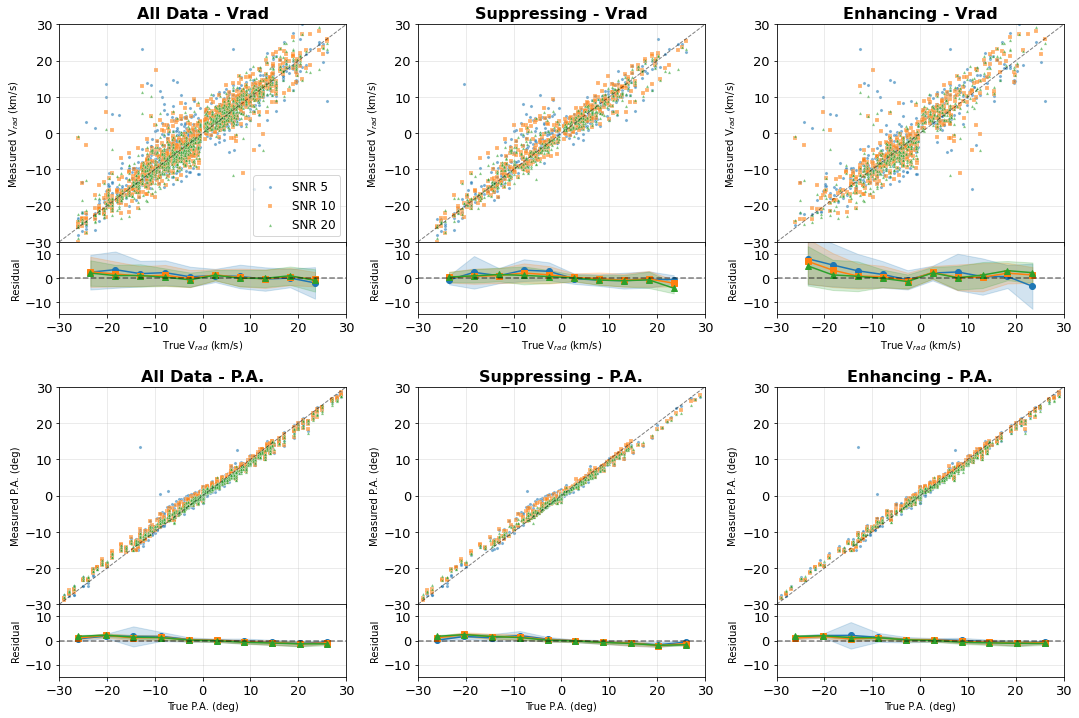

In [3]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ==========================================
# 1. PATH CONFIG
# ==========================================
RING_MODEL = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/snr_res_testing/"
INITIAL_TRUE = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/snr_res_testing/new_res_output"

# ==========================================
# 2. STYLE CONFIG (by SNR)
# ==========================================
SNR_STYLES = {
    5:  dict(color="#1f77b4", marker="o", label="SNR 5"),
    10: dict(color="#ff7f0e", marker="s", label="SNR 10"),
    20: dict(color="#2ca02c", marker="^", label="SNR 20"),
}

# ==========================================
# 3. FILENAME PARSER
# ==========================================
pat_fname = re.compile(
    r"^(?:\d+_)?ring_"
    r"v(?P<v>\d+)_R(?P<R>\d+)_"
    r"(?:(?:PAfixed)|PAk(?P<pa_k>-?\d*\.?\d+)_TP(?P<pa_tp>-?\d*\.?\d+))_"
    r"VR(?:(?:k(?P<vr_k>-?\d*\.?\d+)_TP(?P<vr_tp>-?\d*\.?\d+))|(?P<vr_fixed>0))_"
    r"INC(?P<inc>\d+)_Res(?P<res>\d+)\.txt$"
)

def compute_sign(pa_k, vr_k):
    if pa_k is None or vr_k is None or vr_k == 0:
        return 0
    return 1 if pa_k * vr_k > 0 else -1

# ==========================================
# 4. DATA LOADING
# ==========================================
def load_one_model_all_snr(fname):
    m = pat_fname.match(fname)
    if not m:
        return None

    g = m.groupdict()
    pa_k = float(g["pa_k"]) if g["pa_k"] else None
    vr_k = float(g["vr_k"]) if g["vr_k"] else None

    true_path = os.path.join(INITIAL_TRUE, fname)
    if not os.path.exists(true_path):
        return None

    df_true = pd.read_csv(true_path, sep='\s+')
    true_vrad = df_true["VRAD(km/s)"].values
    true_pa   = df_true["P.A.(deg)"].values

    dfs = []

    for snr in [5, 10, 20]:
        folder = fname.replace(".txt", f"_SNR{snr}")
        out_path = os.path.join(
            RING_MODEL, folder, "second_step_check_sinw", "rings_final2.txt"
        )
        if not os.path.exists(out_path):
            continue

        df_out = pd.read_csv(out_path, sep='\s+')
        n = min(len(true_vrad), len(df_out))

        df = pd.DataFrame({
            "True_VRAD": true_vrad[:n],
            "Measured_VRAD": df_out["VRAD(km/s)"][:n],
            "True_PA": true_pa[:n],
            "Measured_PA": df_out["P.A.(deg)"][:n],
            "SNR": snr,
            "pa_k": pa_k,
            "vr_k": vr_k,
            "sign": compute_sign(pa_k, vr_k),
        })

        df = df[df["True_VRAD"] != 0].reset_index(drop=True)
        dfs.append(df)

    if dfs:
        return pd.concat(dfs, ignore_index=True)
    return None

def load_all_data():
    dfs = []
    files = sorted(glob.glob(os.path.join(RING_MODEL, "*Res*.txt")))
    for fp in files:
        df = load_one_model_all_snr(os.path.basename(fp))
        if df is not None:
            dfs.append(df)
    if dfs:
        return pd.concat(dfs, ignore_index=True)
    return pd.DataFrame()

# ==========================================
# 5. BIN STAT
# ==========================================
def bin_stats(x, y, nbins=10):
    df = pd.DataFrame({"x": x, "y": y})
    df["res"] = df["y"] - df["x"]
    bins = np.linspace(df["x"].min(), df["x"].max(), nbins + 1)
    df["bin"] = pd.cut(df["x"], bins=bins, include_lowest=True)
    g = df.groupby("bin", observed=False)
    xc = 0.5 * (bins[:-1] + bins[1:])
    return xc, g["res"].mean().values, g["res"].std().values

# ==========================================
# 6. SINGLE PANEL (same as original)
# ==========================================
def plot_combined_panel(ax_sc, ax_rs, x, y, snr_col, label, is_pa=False, show_legend=False):
    for snr, style in SNR_STYLES.items():
        idx = snr_col[snr_col == snr].index
        if len(idx) == 0:
            continue

        xs = x.loc[idx]
        ys = y.loc[idx]

        if is_pa:
            xs = xs - 120
            ys = ys - 120

        ax_sc.scatter(
            xs, ys, s=10, alpha=0.6,
            edgecolor="white", linewidth=0.3, **style
        )

        xc, mu, sig = bin_stats(xs, ys)
        ax_rs.plot(xc, mu, **style)
        ax_rs.fill_between(xc, mu - sig, mu + sig,
                           alpha=0.2, color=style["color"])

    ax_sc.plot([-30, 30], [-30, 30], "k--", lw=1, alpha=0.5)
    ax_sc.set_xlim(-30, 30)
    ax_sc.set_ylim(-30, 30)
    ax_sc.grid(alpha=0.3)
    ax_sc.set_ylabel(f"Measured {label}")
    ax_sc.tick_params(labelbottom=False)

    if show_legend:
        ax_sc.legend(loc="lower right", fontsize=12)
    ax_rs.set_ylim(-15, 15)
    ax_rs.axhline(0, ls="--", color="k", alpha=0.5)
    ax_rs.grid(alpha=0.3)
    ax_rs.set_xlabel(f"True {label}")
    ax_rs.set_ylabel("Residual")
    ax_sc.tick_params(axis="both", labelsize=13)
    ax_rs.tick_params(axis="both", labelsize=13)
# ==========================================
# 7. SIX-PANEL FIGURE (STRUCTURE IDENTICAL)
# ==========================================
def plot_six_panel_figure(df_all, df_supp, df_enh):
    fig = plt.figure(figsize=(18, 12))
    outer = gridspec.GridSpec(2, 3, hspace=0.25, wspace=0.25)

    datasets = [
        ("All Data", df_all),
        ("Suppressing", df_supp),
        ("Enhancing", df_enh),
    ]

    # --- Row 1: VRAD ---
    for i, (name, df) in enumerate(datasets):
        inner = gridspec.GridSpecFromSubplotSpec(
            2, 1, subplot_spec=outer[0, i],
            height_ratios=[3, 1], hspace=0.0
        )
        ax_sc = fig.add_subplot(inner[0])
        ax_rs = fig.add_subplot(inner[1], sharex=ax_sc)

        plot_combined_panel(
            ax_sc, ax_rs,
            df["True_VRAD"], df["Measured_VRAD"], df["SNR"],
            label="V$_{rad}$ (km/s)",
            is_pa=False,
            show_legend=(i == 0)
        )
        ax_sc.set_title(f"{name} - Vrad", fontsize=16, fontweight="bold")

    # --- Row 2: PA ---
    for i, (name, df) in enumerate(datasets):
        inner = gridspec.GridSpecFromSubplotSpec(
            2, 1, subplot_spec=outer[1, i],
            height_ratios=[3, 1], hspace=0.0
        )
        ax_sc = fig.add_subplot(inner[0])
        ax_rs = fig.add_subplot(inner[1], sharex=ax_sc)

        plot_combined_panel(
            ax_sc, ax_rs,
            df["True_PA"], df["Measured_PA"], df["SNR"],
            label="P.A. (deg)",
            is_pa=True,
            show_legend=False
        )
        ax_sc.set_title(f"{name} - P.A.", fontsize=16, fontweight="bold")

    plt.savefig("figure_snr_six_panel.pdf")
    plt.show()

# ==========================================
# 8. MAIN
# ==========================================
if __name__ == "__main__":
    df_all = load_all_data()
    df_supp = df_all[df_all["sign"] > 0]
    df_enh  = df_all[df_all["sign"] < 0]

    plot_six_panel_figure(df_all, df_supp, df_enh)


In [17]:
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 13,
})


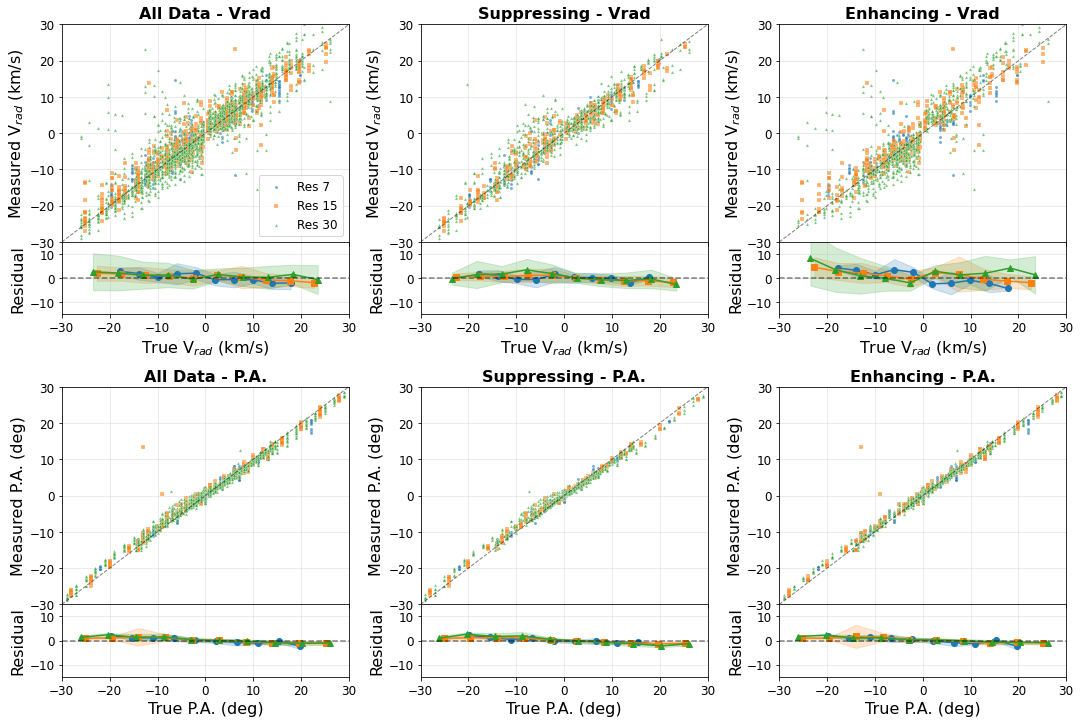

In [4]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ==========================================
# GLOBAL STYLE (optional, keep or remove)
# ==========================================
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 13,
})

# ==========================================
# 1. PATH CONFIG
# ==========================================
RING_MODEL   = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/snr_res_testing/"
INITIAL_TRUE = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/snr_res_testing/new_res_output"

# ==========================================
# 2. STYLE CONFIG (by Resolution)
# ==========================================
RES_STYLES = {
    7:  dict(color="#1f77b4", marker="o", label="Res 7"),
    15: dict(color="#ff7f0e", marker="s", label="Res 15"),
    30: dict(color="#2ca02c", marker="^", label="Res 30"),
}

# ==========================================
# 3. FILENAME PARSER
# ==========================================
pat_fname = re.compile(
    r"^(?:\d+_)?ring_"
    r"v(?P<v>\d+)_R(?P<R>\d+)_"
    r"(?:(?:PAfixed)|PAk(?P<pa_k>-?\d*\.?\d+)_TP(?P<pa_tp>-?\d*\.?\d+))_"
    r"VR(?:(?:k(?P<vr_k>-?\d*\.?\d+)_TP(?P<vr_tp>-?\d*\.?\d+))|(?P<vr_fixed>0))_"
    r"INC(?P<inc>\d+)_Res(?P<res>\d+)\.txt$"
)

def compute_sign(pa_k, vr_k):
    if pa_k is None or vr_k is None or vr_k == 0:
        return 0
    return 1 if pa_k * vr_k > 0 else -1

# ==========================================
# 4. DATA LOADING
# ==========================================
def load_one_model_all_res(fname):
    m = pat_fname.match(fname)
    if not m:
        return None

    g = m.groupdict()
    pa_k = float(g["pa_k"]) if g["pa_k"] else None
    vr_k = float(g["vr_k"]) if g["vr_k"] else None
    res  = int(g["res"])

    true_path = os.path.join(INITIAL_TRUE, fname)
    if not os.path.exists(true_path):
        return None

    df_true = pd.read_csv(true_path, sep='\s+')
    true_vrad = df_true["VRAD(km/s)"].values
    true_pa   = df_true["P.A.(deg)"].values

    dfs = []

    for snr in [5, 10, 20]:
        folder = fname.replace(".txt", f"_SNR{snr}")
        out_path = os.path.join(
            RING_MODEL, folder, "second_step_check_sinw", "rings_final2.txt"
        )

        if not os.path.exists(out_path):
            continue

        df_out = pd.read_csv(out_path, sep='\s+')
        n = min(len(true_vrad), len(df_out))

        df = pd.DataFrame({
            "True_VRAD": true_vrad[:n],
            "Measured_VRAD": df_out["VRAD(km/s)"][:n],
            "True_PA": true_pa[:n],
            "Measured_PA": df_out["P.A.(deg)"][:n],
            "Res": res,
            "SNR": snr,   # 👈 保留 SNR 维度
            "pa_k": pa_k,
            "vr_k": vr_k,
            "sign": compute_sign(pa_k, vr_k),
        })

        df = df[df["True_VRAD"] != 0].reset_index(drop=True)
        dfs.append(df)

    if dfs:
        return pd.concat(dfs, ignore_index=True)
    return None

def load_all_data():
    dfs = []
    files = sorted(glob.glob(os.path.join(RING_MODEL, "*Res*.txt")))
    for fp in files:
        df = load_one_model_all_res(os.path.basename(fp))
        if df is not None:
            dfs.append(df)
    if dfs:
        return pd.concat(dfs, ignore_index=True)
    return pd.DataFrame()

# ==========================================
# 5. BIN STAT
# ==========================================
def bin_stats(x, y, nbins=10):
    df = pd.DataFrame({"x": x, "y": y})
    df["res"] = df["y"] - df["x"]
    bins = np.linspace(df["x"].min(), df["x"].max(), nbins + 1)
    df["bin"] = pd.cut(df["x"], bins=bins, include_lowest=True)
    g = df.groupby("bin", observed=False)
    xc = 0.5 * (bins[:-1] + bins[1:])
    return xc, g["res"].mean().values, g["res"].std().values

# ==========================================
# 6. SINGLE PANEL (unchanged structure)
# ==========================================
def plot_combined_panel(ax_sc, ax_rs, x, y, res_col, label, is_pa=False, show_legend=False):
    for res, style in RES_STYLES.items():
        idx = res_col[res_col == res].index
        if len(idx) == 0:
            continue

        xs = x.loc[idx]
        ys = y.loc[idx]

        if is_pa:
            xs = xs - 120
            ys = ys - 120

        ax_sc.scatter(
            xs, ys, s=10, alpha=0.6,
            edgecolor="white", linewidth=0.3, **style
        )

        xc, mu, sig = bin_stats(xs, ys)
        ax_rs.plot(xc, mu, **style)
        ax_rs.fill_between(xc, mu - sig, mu + sig,
                           alpha=0.2, color=style["color"])

    ax_sc.plot([-30, 30], [-30, 30], "k--", lw=1, alpha=0.5)
    ax_sc.set_xlim(-30, 30)
    ax_sc.set_ylim(-30, 30)
    ax_sc.grid(alpha=0.3)
    ax_sc.set_ylabel(f"Measured {label}")
    ax_sc.tick_params(labelbottom=False)

    if show_legend:
        ax_sc.legend(loc="lower right", fontsize=12)
    ax_rs.set_ylim(-15, 15)
    ax_rs.axhline(0, ls="--", color="k", alpha=0.5)
    ax_rs.grid(alpha=0.3)
    ax_rs.set_xlabel(f"True {label}")
    ax_rs.set_ylabel("Residual")

# ==========================================
# 7. SIX-PANEL FIGURE (IDENTICAL STRUCTURE)
# ==========================================
def plot_six_panel_figure(df_all, df_supp, df_enh):
    fig = plt.figure(figsize=(18, 12))
    outer = gridspec.GridSpec(2, 3, hspace=0.25, wspace=0.25)

    datasets = [
        ("All Data", df_all),
        ("Suppressing", df_supp),
        ("Enhancing", df_enh),
    ]

    # --- Row 1: VRAD ---
    for i, (name, df) in enumerate(datasets):
        inner = gridspec.GridSpecFromSubplotSpec(
            2, 1, subplot_spec=outer[0, i],
            height_ratios=[3, 1], hspace=0.0
        )
        ax_sc = fig.add_subplot(inner[0])
        ax_rs = fig.add_subplot(inner[1], sharex=ax_sc)

        plot_combined_panel(
            ax_sc, ax_rs,
            df["True_VRAD"], df["Measured_VRAD"], df["Res"],
            label="V$_{rad}$ (km/s)",
            is_pa=False,
            show_legend=(i == 0)
        )
        ax_sc.set_title(f"{name} - Vrad", fontsize=16, fontweight="bold")

    # --- Row 2: PA ---
    for i, (name, df) in enumerate(datasets):
        inner = gridspec.GridSpecFromSubplotSpec(
            2, 1, subplot_spec=outer[1, i],
            height_ratios=[3, 1], hspace=0.0
        )
        ax_sc = fig.add_subplot(inner[0])
        ax_rs = fig.add_subplot(inner[1], sharex=ax_sc)

        plot_combined_panel(
            ax_sc, ax_rs,
            df["True_PA"], df["Measured_PA"], df["Res"],
            label="P.A. (deg)",
            is_pa=True,
            show_legend=False
        )
        ax_sc.set_title(f"{name} - P.A.", fontsize=16, fontweight="bold")

    plt.savefig("figure_resolution_six_panel.pdf")
    plt.show()

# ==========================================
# 8. MAIN
# ==========================================
if __name__ == "__main__":
    df_all = load_all_data()
    df_supp = df_all[df_all["sign"] > 0]
    df_enh  = df_all[df_all["sign"] < 0]

    plot_six_panel_figure(df_all, df_supp, df_enh)


In [7]:
rmse_table = (
    df_all
    .assign(
        vrad_res = df_all["Measured_VRAD"] - df_all["True_VRAD"],
        pa_res   = df_all["Measured_PA"]   - df_all["True_PA"]
    )
    .groupby(["SNR", "Res"])
    .agg(
        RMSE_VRAD = ("vrad_res", rmse),
        RMSE_PA   = ("pa_res", rmse),
        N_points  = ("vrad_res", "size")
    )
    .reset_index()
)

print(rmse_table)


   SNR  Res  RMSE_VRAD   RMSE_PA  N_points
0    5    7   3.864843  1.212155        96
1    5   15   4.318948  1.963359       262
2    5   30   5.658003  1.336491       511
3   10    7   2.841990  1.210316        96
4   10   15   2.782196  0.813288       263
5   10   30   4.640344  1.049752       522
6   20    7   3.447215  1.297195        96
7   20   15   2.366478  0.944628       263
8   20   30   4.247604  0.978097       526


In [9]:
import numpy as np

def rmse(x):
    return np.sqrt(np.mean(x**2))

df_rmse = df_all.assign(
    vrad_res = df_all["Measured_VRAD"] - df_all["True_VRAD"],
    pa_res   = df_all["Measured_PA"]   - df_all["True_PA"],
    mode = np.where(
        df_all["sign"] > 0, "Suppressing",
        np.where(df_all["sign"] < 0, "Enhancing", "All")
    )
)


In [10]:
rmse_by_snr = (
    df_rmse
    .groupby(["mode", "SNR"])
    .agg(
        RMSE_VRAD = ("vrad_res", rmse),
        RMSE_PA   = ("pa_res", rmse),
        N_points  = ("vrad_res", "size")
    )
    .reset_index()
    .sort_values(["mode", "SNR"])
)

print(rmse_by_snr)


          mode  SNR  RMSE_VRAD   RMSE_PA  N_points
0          All    5   1.998865  0.504936        86
1          All   10   1.621658  0.318357        87
2          All   20   1.740839  0.303564        87
3    Enhancing    5   6.347260  1.848566       401
4    Enhancing   10   4.920967  0.961964       410
5    Enhancing   20   4.609781  1.067781       414
6  Suppressing    5   4.022443  1.325877       382
7  Suppressing   10   3.184421  1.142910       384
8  Suppressing   20   2.814873  1.045065       384


In [11]:
rmse_by_res = (
    df_rmse
    .groupby(["mode", "Res"])
    .agg(
        RMSE_VRAD = ("vrad_res", rmse),
        RMSE_PA   = ("pa_res", rmse),
        N_points  = ("vrad_res", "size")
    )
    .reset_index()
    .sort_values(["mode", "Res"])
)

print(rmse_by_res)


          mode  Res  RMSE_VRAD   RMSE_PA  N_points
0          All    7   2.202615  0.578467        30
1          All   15   1.464526  0.349654        75
2          All   30   1.848535  0.355176       155
3    Enhancing    7   4.380308  1.484399       129
4    Enhancing   15   4.167070  1.743281       377
5    Enhancing   30   5.997205  1.049382       719
6  Suppressing    7   2.377953  1.074509       129
7  Suppressing   15   2.241743  0.885913       336
8  Suppressing   30   3.952156  1.312421       685


Loading varied-inclination models...
Total points: 4706


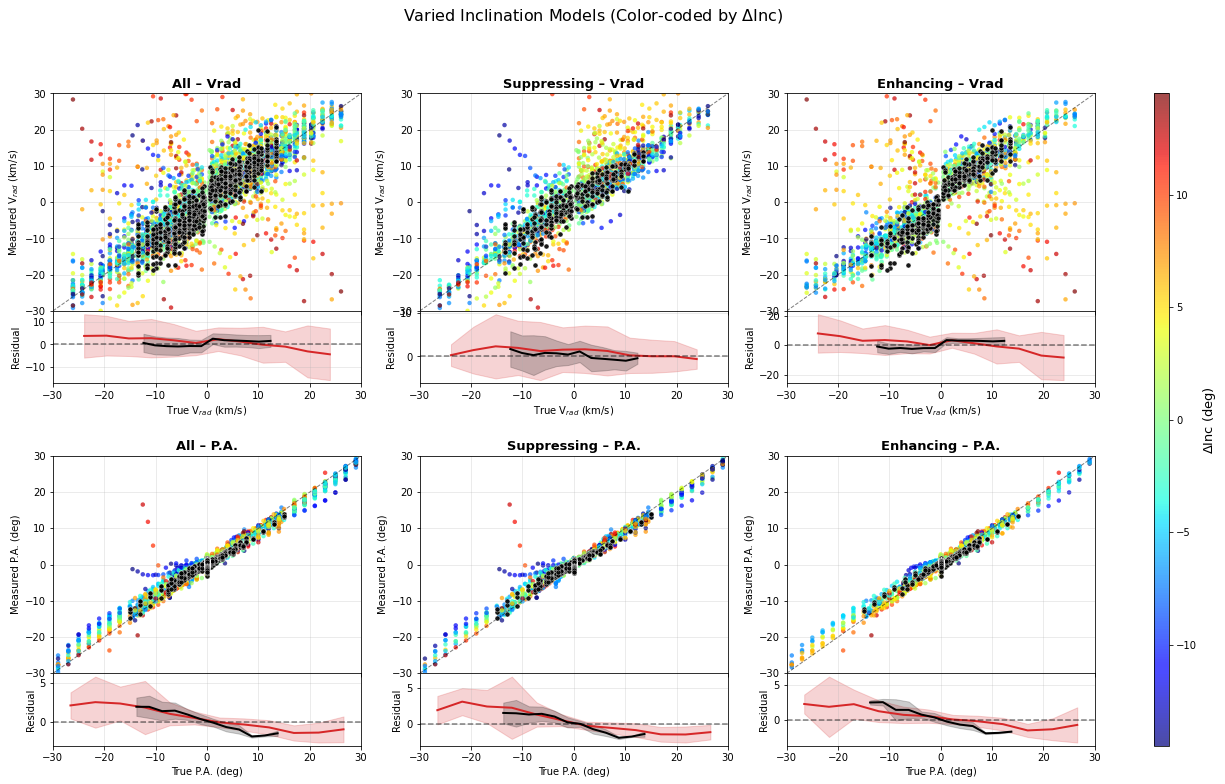

In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors

# ==========================================
# 1. PATH CONFIG
# ==========================================
RING_MODEL_DIR = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/varied_inc/"
INITIAL_DIR    = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/varied_inc/initial/"

# ==========================================
# 2. FILENAME PARSER & UTILITIES
# ==========================================
pat_fname = re.compile(
    r"^(?:\d+_)?ring_"
    r"v(?P<v>\d+)_R(?P<R>\d+)_"
    r"(?:(?:PAfixed)|PAk(?P<pa_k>-?\d*\.?\d+)_TP(?P<pa_tp>-?\d*\.?\d+))_"
    r"VR(?:(?:k(?P<vr_k>-?\d*\.?\d+)_TP(?P<vr_tp>-?\d*\.?\d+))|(?P<vr_fixed>0))_"
    r"INC(?:(?P<inc>\d+)|k(?P<inc_k>-?\d*\.?\d+)_TP(?P<inc_tp>\d*\.?\d+))"
    r"(?:_Res\d+)?"
)

def compute_sign(pa_k, vr_k):
    if pa_k is None or vr_k is None or vr_k == 0:
        return 0
    return 1 if pa_k * vr_k > 0 else -1

# ==========================================
# 3. DATA LOADING
# ==========================================
def load_single_file(fname):
    m = pat_fname.match(fname)
    if not m:
        return None

    g = m.groupdict()
    pa_k = float(g["pa_k"]) if g.get("pa_k") else None
    vr_k = float(g["vr_k"]) if g.get("vr_k") else None

    inc_num = int(g["inc"]) if g.get("inc") else None
    inc_k   = float(g["inc_k"]) if g.get("inc_k") else None

    in_path = os.path.join(INITIAL_DIR, fname)
    if not os.path.exists(in_path):
        return None

    base, _ = os.path.splitext(fname)
    out_path = os.path.join(
        RING_MODEL_DIR,
        base + "_SNR10",
        "second_step_check_sinw",
        "rings_final2.txt"
    )
    if not os.path.exists(out_path):
        return None

    df_in  = pd.read_csv(in_path, sep='\s+')
    df_out = pd.read_csv(out_path, sep='\s+')

    n = min(len(df_in), len(df_out))
    true_inc = df_in["INC(deg)"][:n].values
    delta_inc = true_inc - inc_num if inc_num is not None else true_inc * 0

    df = pd.DataFrame({
        "True_VRAD": df_in["VRAD(km/s)"][:n].values,
        "Measured_VRAD": df_out["VRAD(km/s)"][:n].values,
        "True_PA": df_in["P.A.(deg)"][:n].values,
        "Measured_PA": df_out["P.A.(deg)"][:n].values,
        "Delta_INC": delta_inc,
        "pa_k": pa_k,
        "vr_k": vr_k,
        "sign": compute_sign(pa_k, vr_k),
    })

    df = df[df["True_VRAD"] != 0].reset_index(drop=True)
    return df

def load_all_data():
    dfs = []
    files = sorted(glob.glob(os.path.join(RING_MODEL_DIR, "*.txt")))
    for fp in files:
        if "v200" not in fp:
            continue
        df = load_single_file(os.path.basename(fp))
        if df is not None:
            dfs.append(df)
    if dfs:
        return pd.concat(dfs, ignore_index=True)
    return pd.DataFrame()

# ==========================================
# 4. BIN STAT
# ==========================================
def bin_stats(x, y, nbins=12):
    df = pd.DataFrame({"x": x, "y": y})
    df["res"] = df["y"] - df["x"]
    bins = np.linspace(df["x"].min(), df["x"].max(), nbins + 1)
    df["bin"] = pd.cut(df["x"], bins=bins, include_lowest=True)
    g = df.groupby("bin", observed=False)
    xc = 0.5 * (bins[:-1] + bins[1:])
    return xc, g["res"].mean().values, g["res"].std().values

# ==========================================
# 5. SINGLE PANEL (CONTINUOUS COLOR)
# ==========================================
def plot_panel(ax_sc, ax_rs, df, xcol, ycol, label, is_pa, cmap, norm):
    if is_pa:
        x = df[xcol] - 120
        y = df[ycol] - 120
    else:
        x = df[xcol]
        y = df[ycol]

    delta = df["Delta_INC"]
    mask_fixed = delta == 0
    mask_var   = delta != 0

    sc = None

    if mask_var.any():
        sc = ax_sc.scatter(
            x[mask_var], y[mask_var],
            c=delta[mask_var], cmap=cmap, norm=norm,
            s=20, alpha=0.7, edgecolor="none"
        )

        xc, mu, sig = bin_stats(x[mask_var], y[mask_var])
        ax_rs.plot(xc, mu, color="tab:red", lw=2)
        ax_rs.fill_between(xc, mu - sig, mu + sig, color="tab:red", alpha=0.2)

    if mask_fixed.any():
        ax_sc.scatter(
            x[mask_fixed], y[mask_fixed],
            c="black", s=25, alpha=0.9, edgecolor="white", linewidth=0.4, zorder=10
        )

        xc, mu, sig = bin_stats(x[mask_fixed], y[mask_fixed])
        ax_rs.plot(xc, mu, color="black", lw=2)
        ax_rs.fill_between(xc, mu - sig, mu + sig, color="black", alpha=0.2)

    ax_sc.plot([-30, 30], [-30, 30], "k--", lw=1, alpha=0.5)
    ax_sc.set_xlim(-30, 30)
    ax_sc.set_ylim(-30, 30)
    ax_sc.grid(alpha=0.3)
    ax_sc.set_ylabel(f"Measured {label}")
    ax_sc.tick_params(labelbottom=False)

    ax_rs.axhline(0, ls="--", color="k", alpha=0.5)
    ax_rs.grid(alpha=0.3)
    ax_rs.set_xlabel(f"True {label}")
    ax_rs.set_ylabel("Residual")

    return sc

# ==========================================
# 6. SIX-PANEL FIGURE
# ==========================================
def plot_six_panel(df_all, df_supp, df_enh, title):
    datasets = [("All", df_all), ("Suppressing", df_supp), ("Enhancing", df_enh)]

    deltas = df_all["Delta_INC"]
    vd = deltas[deltas != 0]
    norm = mcolors.Normalize(vmin=vd.min(), vmax=vd.max())
    cmap = plt.get_cmap("jet")

    fig = plt.figure(figsize=(20, 12))
    fig.suptitle(title, fontsize=16)

    outer = gridspec.GridSpec(
        2, 4, width_ratios=[1, 1, 1, 0.05],
        hspace=0.25, wspace=0.25
    )

    mappable = None

    # ---- VRAD row ----
    for i, (name, df) in enumerate(datasets):
        inner = gridspec.GridSpecFromSubplotSpec(
            2, 1, subplot_spec=outer[0, i], height_ratios=[3, 1], hspace=0
        )
        ax_sc = fig.add_subplot(inner[0])
        ax_rs = fig.add_subplot(inner[1], sharex=ax_sc)

        sc = plot_panel(
            ax_sc, ax_rs, df,
            "True_VRAD", "Measured_VRAD",
            "V$_{rad}$ (km/s)", False, cmap, norm
        )
        ax_sc.set_title(f"{name} – Vrad", fontsize=13, fontweight="bold")
        if sc is not None:
            mappable = sc

    # ---- PA row ----
    for i, (name, df) in enumerate(datasets):
        inner = gridspec.GridSpecFromSubplotSpec(
            2, 1, subplot_spec=outer[1, i], height_ratios=[3, 1], hspace=0
        )
        ax_sc = fig.add_subplot(inner[0])
        ax_rs = fig.add_subplot(inner[1], sharex=ax_sc)

        sc = plot_panel(
            ax_sc, ax_rs, df,
            "True_PA", "Measured_PA",
            "P.A. (deg)", True, cmap, norm
        )
        ax_sc.set_title(f"{name} – P.A.", fontsize=13, fontweight="bold")
        if sc is not None:
            mappable = sc

    # ---- Colorbar ----
    if mappable is not None:
        cax = fig.add_subplot(outer[:, 3])
        cbar = plt.colorbar(mappable, cax=cax)
        cbar.set_label(r"$\Delta \mathrm{Inc}$ (deg)", fontsize=13)

    plt.show()

# ==========================================
# 7. MAIN
# ==========================================
if __name__ == "__main__":
    print("Loading varied-inclination models...")
    df_all = load_all_data()
    print(f"Total points: {len(df_all)}")

    if not df_all.empty:
        df_supp = df_all[df_all["sign"] > 0]
        df_enh  = df_all[df_all["sign"] < 0]

        plot_six_panel(
            df_all, df_supp, df_enh,
            "Varied Inclination Models (Color-coded by $\Delta$Inc)"
        )


Loading varied-inclination models...
Total points: 4706


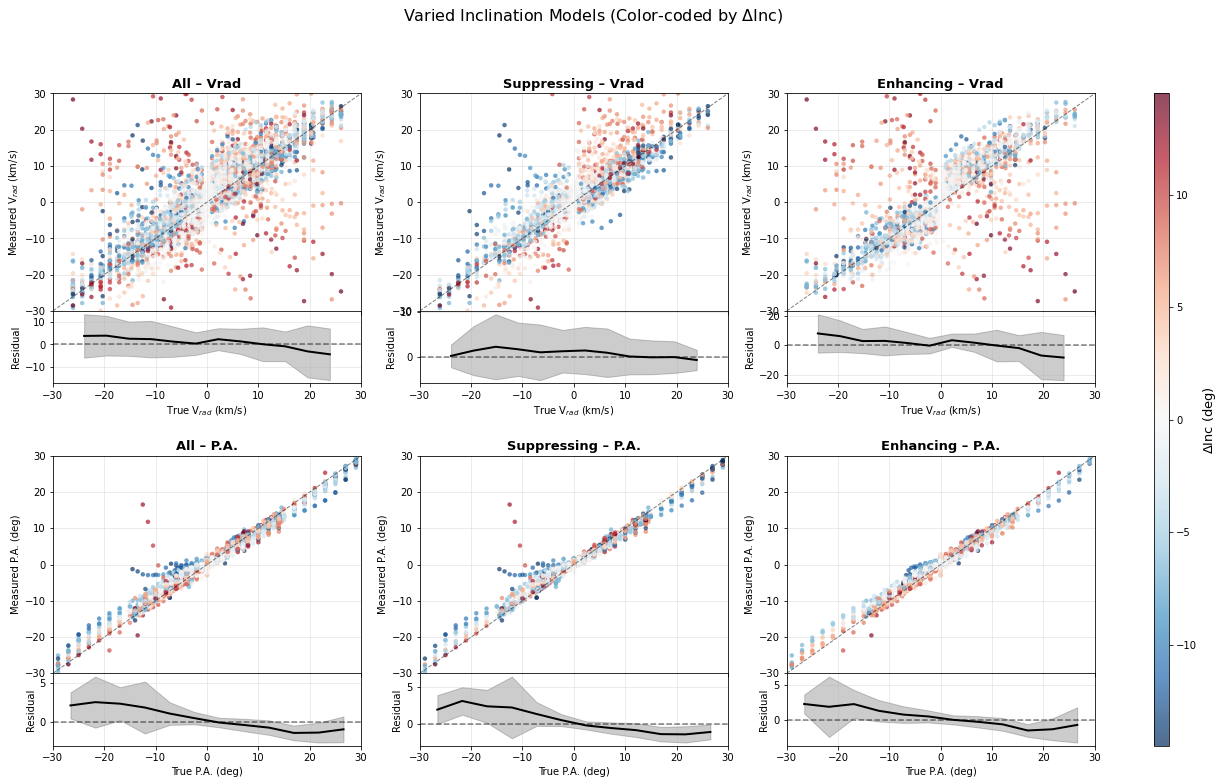

In [4]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm

# ==========================================
# 1. PATH CONFIG
# ==========================================
RING_MODEL_DIR = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/varied_inc/"
INITIAL_DIR    = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/varied_inc/initial/"

# ==========================================
# 2. FILENAME PARSER & UTILITIES
# ==========================================
pat_fname = re.compile(
    r"^(?:\d+_)?ring_"
    r"v(?P<v>\d+)_R(?P<R>\d+)_"
    r"(?:(?:PAfixed)|PAk(?P<pa_k>-?\d*\.?\d+)_TP(?P<pa_tp>-?\d*\.?\d+))_"
    r"VR(?:(?:k(?P<vr_k>-?\d*\.?\d+)_TP(?P<vr_tp>-?\d*\.?\d+))|(?P<vr_fixed>0))_"
    r"INC(?:(?P<inc>\d+)|k(?P<inc_k>-?\d*\.?\d+)_TP(?P<inc_tp>\d*\.?\d+))"
    r"(?:_Res\d+)?"
)

def compute_sign(pa_k, vr_k):
    if pa_k is None or vr_k is None or vr_k == 0:
        return 0
    return 1 if pa_k * vr_k > 0 else -1

# ==========================================
# 3. DATA LOADING
# ==========================================
def load_single_file(fname):
    m = pat_fname.match(fname)
    if not m:
        return None

    g = m.groupdict()
    pa_k = float(g["pa_k"]) if g.get("pa_k") else None
    vr_k = float(g["vr_k"]) if g.get("vr_k") else None
    inc_num = int(g["inc"]) if g.get("inc") else None

    in_path = os.path.join(INITIAL_DIR, fname)
    if not os.path.exists(in_path):
        return None

    base, _ = os.path.splitext(fname)
    out_path = os.path.join(
        RING_MODEL_DIR,
        base + "_SNR10",
        "second_step_check_sinw",
        "rings_final2.txt"
    )
    if not os.path.exists(out_path):
        return None

    df_in  = pd.read_csv(in_path, sep='\s+')
    df_out = pd.read_csv(out_path, sep='\s+')

    n = min(len(df_in), len(df_out))
    delta_inc = df_in["INC(deg)"][:n].values - inc_num

    df = pd.DataFrame({
        "True_VRAD": df_in["VRAD(km/s)"][:n].values,
        "Measured_VRAD": df_out["VRAD(km/s)"][:n].values,
        "True_PA": df_in["P.A.(deg)"][:n].values,
        "Measured_PA": df_out["P.A.(deg)"][:n].values,
        "Delta_INC": delta_inc,
        "sign": compute_sign(pa_k, vr_k),
    })

    return df[df["True_VRAD"] != 0].reset_index(drop=True)

def load_all_data():
    dfs = []
    for fp in sorted(glob.glob(os.path.join(RING_MODEL_DIR, "*.txt"))):
        if "v200" not in fp:
            continue
        df = load_single_file(os.path.basename(fp))
        if df is not None:
            dfs.append(df)
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

# ==========================================
# 4. BIN STAT
# ==========================================
def bin_stats(x, y, nbins=12):
    df = pd.DataFrame({"x": x, "y": y})
    df["res"] = df["y"] - df["x"]
    bins = np.linspace(df["x"].min(), df["x"].max(), nbins + 1)
    df["bin"] = pd.cut(df["x"], bins=bins, include_lowest=True)
    g = df.groupby("bin", observed=False)
    xc = 0.5 * (bins[:-1] + bins[1:])
    return xc, g["res"].mean().values, g["res"].std().values

# ==========================================
# 5. SINGLE PANEL (NO MASK, SYMMETRIC COLORBAR)
# ==========================================
def plot_panel(ax_sc, ax_rs, df, xcol, ycol, label, is_pa, cmap, norm):
    x = df[xcol] - 120 if is_pa else df[xcol]
    y = df[ycol] - 120 if is_pa else df[ycol]
    delta = df["Delta_INC"]

    sc = ax_sc.scatter(
        x, y,
        c=delta,
        cmap=cmap,
        norm=norm,
        s=20,
        alpha=0.7,
        edgecolor="none"
    )

    xc, mu, sig = bin_stats(x, y)
    ax_rs.plot(xc, mu, color="k", lw=2)
    ax_rs.fill_between(xc, mu - sig, mu + sig, color="k", alpha=0.2)

    ax_sc.plot([-30, 30], [-30, 30], "k--", lw=1, alpha=0.5)
    ax_sc.set_xlim(-30, 30)
    ax_sc.set_ylim(-30, 30)
    ax_sc.grid(alpha=0.3)
    ax_sc.set_ylabel(f"Measured {label}")
    ax_sc.tick_params(labelbottom=False)

    ax_rs.axhline(0, ls="--", color="k", alpha=0.5)
    ax_rs.grid(alpha=0.3)
    ax_rs.set_xlabel(f"True {label}")
    ax_rs.set_ylabel("Residual")

    return sc

# ==========================================
# 6. SIX-PANEL FIGURE
# ==========================================
def plot_six_panel(df_all, df_supp, df_enh, title):
    datasets = [
        ("All", df_all),
        ("Suppressing", df_supp),
        ("Enhancing", df_enh),
    ]

    deltas = df_all["Delta_INC"]
    dmax = np.max(np.abs(deltas))
    norm = TwoSlopeNorm(vmin=-dmax, vcenter=0.0, vmax=dmax)

    cmap = plt.get_cmap("RdBu_r")

    fig = plt.figure(figsize=(20, 12))
    fig.suptitle(title, fontsize=16)

    outer = gridspec.GridSpec(
        2, 4,
        width_ratios=[1, 1, 1, 0.05],
        hspace=0.25,
        wspace=0.25
    )

    mappable = None

    # ---- Row 1: VRAD ----
    for i, (name, df) in enumerate(datasets):
        inner = gridspec.GridSpecFromSubplotSpec(
            2, 1, subplot_spec=outer[0, i],
            height_ratios=[3, 1], hspace=0
        )
        ax_sc = fig.add_subplot(inner[0])
        ax_rs = fig.add_subplot(inner[1], sharex=ax_sc)

        sc = plot_panel(
            ax_sc, ax_rs, df,
            "True_VRAD", "Measured_VRAD",
            "V$_{rad}$ (km/s)", False, cmap, norm
        )
        ax_sc.set_title(f"{name} – Vrad", fontsize=13, fontweight="bold")
        mappable = sc

    # ---- Row 2: PA ----
    for i, (name, df) in enumerate(datasets):
        inner = gridspec.GridSpecFromSubplotSpec(
            2, 1, subplot_spec=outer[1, i],
            height_ratios=[3, 1], hspace=0
        )
        ax_sc = fig.add_subplot(inner[0])
        ax_rs = fig.add_subplot(inner[1], sharex=ax_sc)

        sc = plot_panel(
            ax_sc, ax_rs, df,
            "True_PA", "Measured_PA",
            "P.A. (deg)", True, cmap, norm
        )
        ax_sc.set_title(f"{name} – P.A.", fontsize=13, fontweight="bold")
        mappable = sc

    # ---- Colorbar ----
    if mappable is not None:
        cax = fig.add_subplot(outer[:, 3])
        cbar = plt.colorbar(mappable, cax=cax)
        cbar.set_label(r"$\Delta \mathrm{Inc}$ (deg)", fontsize=13)

    plt.show()

# ==========================================
# 7. MAIN
# ==========================================
if __name__ == "__main__":
    print("Loading varied-inclination models...")
    df_all = load_all_data()
    print(f"Total points: {len(df_all)}")

    df_supp = df_all[df_all["sign"] > 0]
    df_enh  = df_all[df_all["sign"] < 0]

    plot_six_panel(
        df_all,
        df_supp,
        df_enh,
        "Varied Inclination Models (Color-coded by $\Delta$Inc)"
    )

    

In [8]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import re
import glob
import numpy as np
import pandas as pd

# ==========================================
# 1. PATH CONFIG
# ==========================================
RING_MODEL_DIR = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/varied_inc/"
INITIAL_DIR    = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/varied_inc/initial/"

# ==========================================
# 2. FILENAME PARSER
# ==========================================
pat_fname = re.compile(
    r"^(?:\d+_)?ring_"
    r"v(?P<v>\d+)_R(?P<R>\d+)_"
    r"(?:(?:PAfixed)|PAk(?P<pa_k>-?\d*\.?\d+)_TP(?P<pa_tp>-?\d*\.?\d+))_"
    r"VR(?:(?:k(?P<vr_k>-?\d*\.?\d+)_TP(?P<vr_tp>-?\d*\.?\d+))|(?P<vr_fixed>0))_"
    r"INC(?:(?P<inc>\d+)|k(?P<inc_k>-?\d*\.?\d+)_TP(?P<inc_tp>\d*\.?\d+))"
    r"(?:_Res\d+)?"
)

def compute_sign(pa_k, vr_k):
    if pa_k is None or vr_k is None or vr_k == 0:
        return 0
    return 1 if pa_k * vr_k > 0 else -1

# ==========================================
# 3. DATA LOADING
# ==========================================
def load_single_file(fname):
    m = pat_fname.match(fname)
    if not m:
        return None

    g = m.groupdict()
    pa_k = float(g["pa_k"]) if g.get("pa_k") else None
    vr_k = float(g["vr_k"]) if g.get("vr_k") else None
    inc_num = int(g["inc"]) if g.get("inc") else None

    in_path = os.path.join(INITIAL_DIR, fname)
    if not os.path.exists(in_path):
        return None

    base, _ = os.path.splitext(fname)
    out_path = os.path.join(
        RING_MODEL_DIR,
        base + "_SNR10",
        "second_step_check_sinw",
        "rings_final2.txt"
    )
    if not os.path.exists(out_path):
        return None

    df_in  = pd.read_csv(in_path, sep='\s+')
    df_out = pd.read_csv(out_path, sep='\s+')

    n = min(len(df_in), len(df_out))

    df = pd.DataFrame({
        "file": fname,
        "ring_id": np.arange(n),
        "True_PA": df_in["P.A.(deg)"][:n].values,
        "Measured_PA": df_out["P.A.(deg)"][:n].values,
        "True_VRAD": df_in["VRAD(km/s)"][:n].values,
        "Measured_VRAD": df_out["VRAD(km/s)"][:n].values,
        "Delta_INC": df_in["INC(deg)"][:n].values - inc_num,
        "sign": compute_sign(pa_k, vr_k),
    })

    df = df[df["True_VRAD"] != 0].reset_index(drop=True)
    return df

def load_all_data():
    dfs = []
    for fp in sorted(glob.glob(os.path.join(RING_MODEL_DIR, "*.txt"))):
        if "v200" not in fp:
            continue
        df = load_single_file(os.path.basename(fp))
        if df is not None:
            dfs.append(df)

    if not dfs:
        return pd.DataFrame()

    return pd.concat(dfs, ignore_index=True)

# ==========================================
# 4. OUTLIER DETECTION
# ==========================================
def find_pa_outliers(df, threshold=10.0):
    df = df.copy()
    df["PA_residual"] = df["Measured_PA"] - df["True_PA"]
    df["abs_PA_residual"] = np.abs(df["PA_residual"])

    outliers = df[df["abs_PA_residual"] > threshold].copy()
    return outliers

# ==========================================
# 5. MAIN
# ==========================================
if __name__ == "__main__":
    print("Loading varied-inclination data...")
    df_all = load_all_data()
    print(f"Total rings loaded: {len(df_all)}")

    # ---- 找 PA outliers ----
    df_out = find_pa_outliers(df_all, threshold=10.0)
    print(f"\nNumber of PA outliers (|residual| > 10 deg): {len(df_out)}")

    if df_out.empty:
        print("No strong PA outliers found.")
        exit()

    # ---- 按星系汇总 ----
    print("\n=== Outliers grouped by galaxy ===")
    summary = (
        df_out
        .groupby("file")
        .agg(
            N_outlier_rings=("ring_id", "count"),
            max_abs_PA_res=("abs_PA_residual", "max"),
            mean_abs_PA_res=("abs_PA_residual", "mean"),
            mode=("sign", lambda x: "Enhancing" if (x < 0).any()
                                  else "Suppressing" if (x > 0).any()
                                  else "Mixed")
        )
        .sort_values("max_abs_PA_res", ascending=False)
    )
    print(summary)

    # ---- 详细信息（逐 ring）----
    print("\n=== Detailed ring-level outliers ===")
    cols = [
        "file",
        "ring_id",
        "True_PA",
        "Measured_PA",
        "PA_residual",
        "Delta_INC",
        "sign"
    ]
    print(df_out[cols].sort_values("abs_PA_residual", ascending=False))



Loading varied-inclination data...
Total rings loaded: 4706

Number of PA outliers (|residual| > 10 deg): 6

=== Outliers grouped by galaxy ===
                                                    N_outlier_rings  \
file                                                                  
ring_v200_R50_PAk0.05_TP300.0_VRk0.07_TP450.0_I...                3   
ring_v200_R50_PAk0.1_TP300.0_VRk-0.05_TP300.0_I...                1   
ring_v200_R50_PAk0.05_TP300.0_VRk0.05_TP300.0_I...                2   

                                                    max_abs_PA_res  \
file                                                                 
ring_v200_R50_PAk0.05_TP300.0_VRk0.07_TP450.0_I...          29.068   
ring_v200_R50_PAk0.1_TP300.0_VRk-0.05_TP300.0_I...          14.000   
ring_v200_R50_PAk0.05_TP300.0_VRk0.05_TP300.0_I...          13.250   

                                                    mean_abs_PA_res  \
file                                                                  
ring_v2

KeyError: 'abs_PA_residual'

Searching for galaxies with PA residue > 10.0...

FILENAME                                 | MAX RESIDUE | POINTS
------------------------------------------------------------
ring_v200_R50_PAk0.05_TP300.0_VRk0.07_TP450.0_INC75k-0.05_TP300_Res30.txt |      29.07 | 3
ring_v200_R50_PAk0.1_TP300.0_VRk-0.05_TP300.0_INC60k-0.05_TP300_Res30.txt |      14.00 | 1
ring_v200_R50_PAk0.05_TP300.0_VRk0.05_TP300.0_INC45k0.05_TP300_Res30.txt |      13.25 | 2


In [9]:
import os
import glob
import pandas as pd
import numpy as np

# 配置路径（请确保与你主脚本一致）
RING_MODEL_DIR = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/varied_inc/"
INITIAL_DIR    = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/varied_inc/initial/"

def locate_outliers(threshold=10.0):
    print(f"Searching for galaxies with PA residue > {threshold}...")
    results = []

    # 遍历所有的结果文件
    search_path = os.path.join(RING_MODEL_DIR, "*_SNR10/second_step_check_sinw/rings_final2.txt")
    files = glob.glob(search_path)

    for out_path in files:
        # 从路径中提取原始文件名
        # 假设文件夹结构是 .../ring_v200_R..._SNR10/...
        folder_name = out_path.split('/')[-3]
        base_fname = folder_name.replace("_SNR10", "") + ".txt"
        in_path = os.path.join(INITIAL_DIR, base_fname)

        if not os.path.exists(in_path):
            continue

        try:
            df_in  = pd.read_csv(in_path, sep='\s+')
            df_out = pd.read_csv(out_path, sep='\s+')

            n = min(len(df_in), len(df_out))
            
            # 计算 PA 残差 (处理可能的 0 值)
            true_pa = df_in["P.A.(deg)"][:n].values
            meas_pa = df_out["P.A.(deg)"][:n].values
            v_rad_true = df_in["VRAD(km/s)"][:n].values
            
            residue = np.abs(meas_pa - true_pa)

            # 筛选出符合条件的行 (且排除 Vrad=0 的填充点)
            mask = (residue > threshold) & (v_rad_true != 0)
            
            if np.any(mask):
                max_res = np.max(residue[mask])
                results.append({
                    "Galaxy": base_fname,
                    "Max_Residue": max_res,
                    "Points_Count": np.sum(mask)
                })
        except Exception as e:
            print(f"Error processing {base_fname}: {e}")

    # 打印结果
    if results:
        df_res = pd.DataFrame(results).sort_values(by="Max_Residue", ascending=False)
        print("\n" + "="*60)
        print(f"{'FILENAME':<40} | {'MAX RESIDUE':<10} | {'POINTS'}")
        print("-" * 60)
        for _, row in df_res.iterrows():
            print(f"{row['Galaxy']:<40} | {row['Max_Residue']:10.2f} | {int(row['Points_Count'])}")
        print("="*60)
    else:
        print("No outliers found.")

if __name__ == "__main__":
    locate_outliers(5)

Searching for galaxies with PA residue > 5...

FILENAME                                 | MAX RESIDUE | POINTS
------------------------------------------------------------
ring_v200_R50_PAk0.05_TP300.0_VRk0.07_TP450.0_INC75k-0.05_TP300_Res30.txt |      29.07 | 4
ring_v200_R50_PAk0.1_TP300.0_VRk-0.05_TP300.0_INC60k-0.05_TP300_Res30.txt |      14.00 | 1
ring_v200_R50_PAk0.05_TP300.0_VRk0.05_TP300.0_INC45k0.05_TP300_Res30.txt |      13.25 | 8
ring_v200_R50_PAk-0.1_TP300.0_VRk0.07_TP450.0_INC45k-0.05_TP300_Res30.txt |      10.00 | 1
ring_v200_R50_PAk0.05_TP450.0_VRk0.09_TP450.0_INC45k0.05_TP300_Res30.txt |       7.22 | 2
ring_v200_R50_PAk0.1_TP450.0_VRk0.07_TP300.0_INC45k0.05_TP300_Res30.txt |       7.21 | 5
ring_v200_R50_PAk0.1_TP300.0_VRk0.05_TP450.0_INC60k0.05_TP300_Res30.txt |       6.23 | 4
ring_v200_R50_PAk0.05_TP300.0_VRk-0.07_TP300.0_INC45k-0.05_TP300_Res30.txt |       6.03 | 1
ring_v200_R50_PAk0.1_TP300.0_VRk0.09_TP300.0_INC75k0.05_TP300_Res30.txt |       5.67 | 2
ring_v200_R50_PA

Loading varied-inclination models...
Total points after filter: 4706


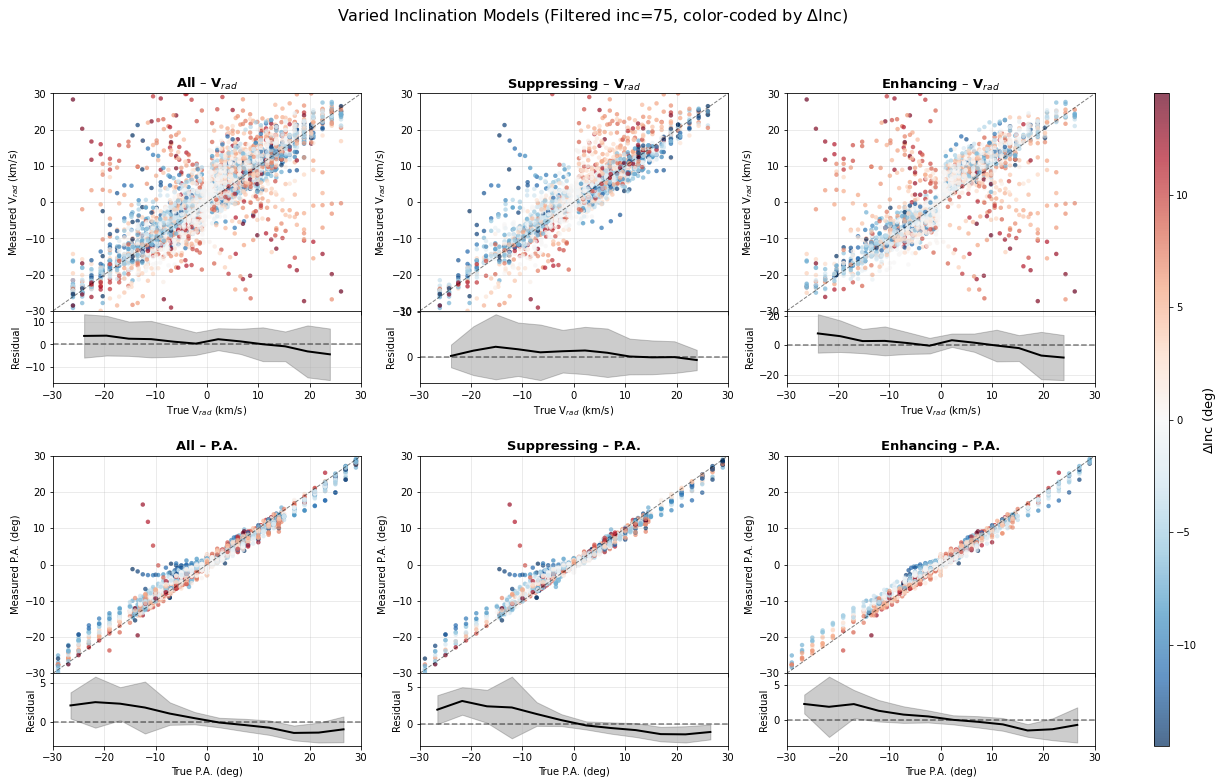

In [12]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm

# ==========================================
# 1. PATH CONFIG
# ==========================================
RING_MODEL_DIR = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/varied_inc/"
INITIAL_DIR    = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/varied_inc/initial/"

# ==========================================
# 2. FILENAME PARSER & UTILITIES
# ==========================================
pat_fname = re.compile(
    r"^(?:\d+_)?ring_"
    r"v(?P<v>\d+)_R(?P<R>\d+)_"
    r"(?:(?:PAfixed)|PAk(?P<pa_k>-?\d*\.?\d+)_TP(?P<pa_tp>-?\d*\.?\d+))_"
    r"VR(?:(?:k(?P<vr_k>-?\d*\.?\d+)_TP(?P<vr_tp>-?\d*\.?\d+))|(?P<vr_fixed>0))_"
    r"INC(?:(?P<inc>\d+)|k(?P<inc_k>-?\d*\.?\d+)_TP(?P<inc_tp>\d*\.?\d+))"
    r"(?:_Res\d+)?"
)

def compute_sign(pa_k, vr_k):
    if pa_k is None or vr_k is None or vr_k == 0:
        return 0
    return 1 if pa_k * vr_k > 0 else -1

# ==========================================
# 3. DATA LOADING  (WITH FILTER)
# ==========================================
def load_single_file(fname):
    m = pat_fname.match(fname)
    if not m:
        return None

    g = m.groupdict()

    pa_k = float(g["pa_k"]) if g.get("pa_k") else None
    vr_k = float(g["vr_k"]) if g.get("vr_k") else None

    inc_num = int(g["inc"]) if g.get("inc") else None
    inc_k   = float(g["inc_k"]) if g.get("inc_k") else None
    inc_tp  = float(g["inc_tp"]) if g.get("inc_tp") else None
    
    # ======================================================
    # <<< FILTER >>>
    # Only apply to inc=75 systems
    # Keep:
    #   - fixed inc=75
    #   - inc_k = -0.05 AND TP = 450
    # ======================================================
    if inc_num == 75:
        if inc_k is not None:
            if not (np.isclose(inc_k, -0.05) and np.isclose(inc_tp, 450)):
                return None
    # ======================================================

    in_path = os.path.join(INITIAL_DIR, fname)
    if not os.path.exists(in_path):
        return None

    base, _ = os.path.splitext(fname)
    out_path = os.path.join(
        RING_MODEL_DIR,
        base + "_SNR10",
        "second_step_check_sinw",
        "rings_final2.txt"
    )
    if not os.path.exists(out_path):
        return None

    df_in  = pd.read_csv(in_path, sep='\s+')
    df_out = pd.read_csv(out_path, sep='\s+')

    n = min(len(df_in), len(df_out))

    delta_inc = df_in["INC(deg)"][:n].values - inc_num

    df = pd.DataFrame({
        "True_VRAD": df_in["VRAD(km/s)"][:n].values,
        "Measured_VRAD": df_out["VRAD(km/s)"][:n].values,
        "True_PA": df_in["P.A.(deg)"][:n].values,
        "Measured_PA": df_out["P.A.(deg)"][:n].values,
        "Delta_INC": delta_inc,
        "sign": compute_sign(pa_k, vr_k),
        "file": fname
    })

    return df[df["True_VRAD"] != 0].reset_index(drop=True)

def load_all_data():
    dfs = []
    for fp in sorted(glob.glob(os.path.join(RING_MODEL_DIR, "*.txt"))):
        if "v200" not in fp:
            continue
        df = load_single_file(os.path.basename(fp))
        if df is not None:
            dfs.append(df)
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

# ==========================================
# 4. BIN STAT
# ==========================================
def bin_stats(x, y, nbins=12):
    df = pd.DataFrame({"x": x, "y": y})
    df["res"] = df["y"] - df["x"]
    bins = np.linspace(df["x"].min(), df["x"].max(), nbins + 1)
    df["bin"] = pd.cut(df["x"], bins=bins, include_lowest=True)
    g = df.groupby("bin", observed=False)
    xc = 0.5 * (bins[:-1] + bins[1:])
    return xc, g["res"].mean().values, g["res"].std().values

# ==========================================
# 5. SINGLE PANEL
# ==========================================
def plot_panel(ax_sc, ax_rs, df, xcol, ycol, label, is_pa, cmap, norm):
    x = df[xcol] - 120 if is_pa else df[xcol]
    y = df[ycol] - 120 if is_pa else df[ycol]
    delta = df["Delta_INC"]

    sc = ax_sc.scatter(
        x, y,
        c=delta,
        cmap=cmap,
        norm=norm,
        s=20,
        alpha=0.7,
        edgecolor="none"
    )

    xc, mu, sig = bin_stats(x, y)
    ax_rs.plot(xc, mu, color="k", lw=2)
    ax_rs.fill_between(xc, mu - sig, mu + sig, color="k", alpha=0.2)

    ax_sc.plot([-30, 30], [-30, 30], "k--", lw=1, alpha=0.5)
    ax_sc.set_xlim(-30, 30)
    ax_sc.set_ylim(-30, 30)
    ax_sc.grid(alpha=0.3)
    ax_sc.set_ylabel(f"Measured {label}")
    ax_sc.tick_params(labelbottom=False)

    ax_rs.axhline(0, ls="--", color="k", alpha=0.5)
    ax_rs.grid(alpha=0.3)
    ax_rs.set_xlabel(f"True {label}")
    ax_rs.set_ylabel("Residual")

    return sc

# ==========================================
# 6. SIX-PANEL FIGURE
# ==========================================
def plot_six_panel(df_all, df_supp, df_enh, title):
    datasets = [
        ("All", df_all),
        ("Suppressing", df_supp),
        ("Enhancing", df_enh),
    ]

    deltas = df_all["Delta_INC"]
    dmax = np.max(np.abs(deltas))
    norm = TwoSlopeNorm(vmin=-dmax, vcenter=0.0, vmax=dmax)
    cmap = plt.get_cmap("RdBu_r")

    fig = plt.figure(figsize=(20, 12))
    fig.suptitle(title, fontsize=16)

    outer = gridspec.GridSpec(
        2, 4,
        width_ratios=[1, 1, 1, 0.05],
        hspace=0.25,
        wspace=0.25
    )

    mappable = None

    for row, (xcol, ycol, label, is_pa) in enumerate([
        ("True_VRAD", "Measured_VRAD", "V$_{rad}$ (km/s)", False),
        ("True_PA",   "Measured_PA",   "P.A. (deg)",       True)
    ]):
        for i, (name, df) in enumerate(datasets):
            inner = gridspec.GridSpecFromSubplotSpec(
                2, 1, subplot_spec=outer[row, i],
                height_ratios=[3, 1], hspace=0
            )
            ax_sc = fig.add_subplot(inner[0])
            ax_rs = fig.add_subplot(inner[1], sharex=ax_sc)

            sc = plot_panel(ax_sc, ax_rs, df, xcol, ycol, label, is_pa, cmap, norm)
            ax_sc.set_title(f"{name} – {label.split()[0]}", fontsize=13, fontweight="bold")
            mappable = sc

    if mappable is not None:
        cax = fig.add_subplot(outer[:, 3])
        cbar = plt.colorbar(mappable, cax=cax)
        cbar.set_label(r"$\Delta \mathrm{Inc}$ (deg)", fontsize=13)

    plt.show()

# ==========================================
# 7. MAIN
# ==========================================
if __name__ == "__main__":
    print("Loading varied-inclination models...")
    df_all = load_all_data()
    print(f"Total points after filter: {len(df_all)}")

    df_supp = df_all[df_all["sign"] > 0]
    df_enh  = df_all[df_all["sign"] < 0]

    plot_six_panel(
        df_all,
        df_supp,
        df_enh,
        "Varied Inclination Models (Filtered inc=75, color-coded by $\Delta$Inc)"
    )


Loading data and applying filters...
Total valid points after filtering: 4184

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
DETECTED OUTLIERS (PA Residue > 10):
- ring_v200_R50_PAk0.1_TP300.0_VRk-0.05_TP300.0_INC60k-0.05_TP300_Res30.txt | Max Residue: 14.00
- ring_v200_R50_PAk0.05_TP300.0_VRk0.05_TP300.0_INC45k0.05_TP300_Res30.txt | Max Residue: 13.25
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!



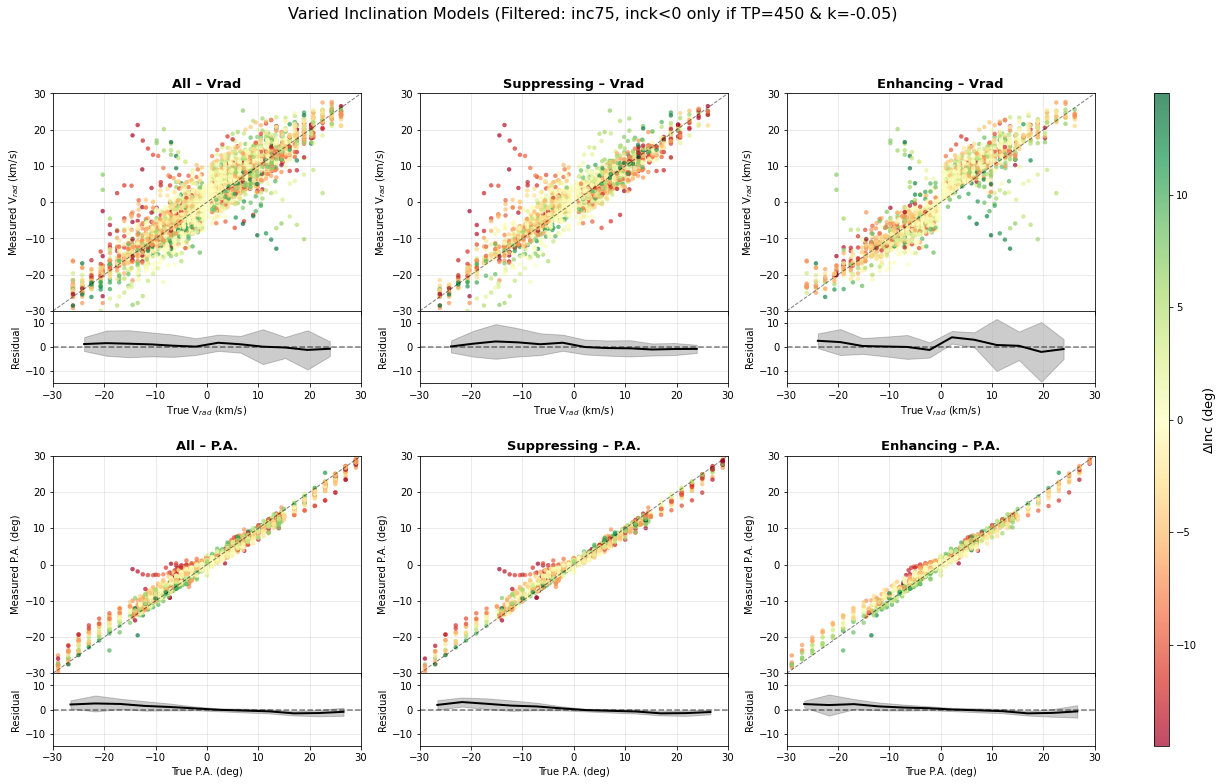

In [15]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm

# ==========================================
# 1. PATH CONFIG
# ==========================================
RING_MODEL_DIR = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/varied_inc/"
INITIAL_DIR    = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/varied_inc/initial/"

# ==========================================
# 2. FILENAME PARSER (Updated for INC75k-0.05 style)
# ==========================================
# 修正后的正则：可以同时捕获 INC75 和随后的 k, TP 参数
pat_fname = re.compile(
    r"^(?:\d+_)?ring_"
    r"v(?P<v>\d+)_R(?P<R>\d+)_"
    r"(?:(?:PAfixed)|PAk(?P<pa_k>-?\d*\.?\d+)_TP(?P<pa_tp>-?\d*\.?\d+))_"
    r"VR(?:(?:k(?P<vr_k>-?\d*\.?\d+)_TP(?P<vr_tp>-?\d*\.?\d+))|(?P<vr_fixed>0))_"
    r"INC(?P<inc>\d+)(?:k(?P<inc_k>-?\d*\.?\d+)_TP(?P<inc_tp>-?\d*\.?\d+))?"
    r"(?:_Res\d+)?"
)

def compute_sign(pa_k, vr_k):
    if pa_k is None or vr_k is None or vr_k == 0:
        return 0
    return 1 if pa_k * vr_k > 0 else -1

# ==========================================
# 3. DATA LOADING WITH STRICT FILTERING
# ==========================================
def load_single_file(fname):
    m = pat_fname.match(fname)
    if not m:
        return None

    g = m.groupdict()
    pa_k = float(g["pa_k"]) if g.get("pa_k") else None
    vr_k = float(g["vr_k"]) if g.get("vr_k") else None
    
    # 提取倾角参数
    inc_base = int(g["inc"]) if g.get("inc") else None
    inc_k = float(g["inc_k"]) if g.get("inc_k") else 0.0
    inc_tp = float(g["inc_tp"]) if g.get("inc_tp") else 0.0

    # --- 倾角过滤逻辑 ---
    # 针对 inc75 且 inck < 0 的情况（倾角增加到80+度）
    if inc_base == 75:
        if inc_k < 0:
            # 仅保留 TP=450 且 k=-0.05
            is_target_k = abs(inc_k - (-0.05)) < 1e-4
            is_target_tp = abs(inc_tp - 450.0) < 1e-4
            if not (is_target_k and is_target_tp):
                return None
    # ------------------

    in_path = os.path.join(INITIAL_DIR, fname)
    if not os.path.exists(in_path):
        return None

    base, _ = os.path.splitext(fname)
    out_path = os.path.join(
        RING_MODEL_DIR,
        base + "_SNR10",
        "second_step_check_sinw",
        "rings_final2.txt"
    )
    if not os.path.exists(out_path):
        return None

    try:
        df_in  = pd.read_csv(in_path, sep='\s+')
        df_out = pd.read_csv(out_path, sep='\s+')

        n = min(len(df_in), len(df_out))
        # 计算 Delta_INC (真实值 - 初始设定值)
        delta_inc = df_in["INC(deg)"][:n].values - inc_base

        df = pd.DataFrame({
            "Filename": fname,
            "True_VRAD": df_in["VRAD(km/s)"][:n].values,
            "Measured_VRAD": df_out["VRAD(km/s)"][:n].values,
            "True_PA": df_in["P.A.(deg)"][:n].values,
            "Measured_PA": df_out["P.A.(deg)"][:n].values,
            "Delta_INC": delta_inc,
            "sign": compute_sign(pa_k, vr_k),
        })
        # 计算 PA 残差用于定位
        df["PA_Residue"] = np.abs(df["Measured_PA"] - df["True_PA"])
        
        return df[df["True_VRAD"] != 0].reset_index(drop=True)
    except Exception:
        return None

def load_all_data():
    dfs = []
    # 遍历 INITIAL_DIR 下所有的 .txt 文件
    for fp in sorted(glob.glob(os.path.join(INITIAL_DIR, "*.txt"))):
        fname = os.path.basename(fp)
        if "v200" not in fname:
            continue
        df = load_single_file(fname)
        if df is not None:
            dfs.append(df)
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

# ==========================================
# 4. BIN STATS & PLOT UTILS
# ==========================================
def bin_stats(x, y, nbins=12):
    df = pd.DataFrame({"x": x, "y": y})
    df["res"] = df["y"] - df["x"]
    bins = np.linspace(df["x"].min(), df["x"].max(), nbins + 1)
    df["bin"] = pd.cut(df["x"], bins=bins, include_lowest=True)
    g = df.groupby("bin", observed=False)
    xc = 0.5 * (bins[:-1] + bins[1:])
    return xc, g["res"].mean().values, g["res"].std().values

def plot_panel(ax_sc, ax_rs, df, xcol, ycol, label, is_pa, cmap, norm):
    # 如果是 PA，则减去 120 度基数
    x = df[xcol] - 120 if is_pa else df[xcol]
    y = df[ycol] - 120 if is_pa else df[ycol]
    
    sc = ax_sc.scatter(
        x, y, c=df["Delta_INC"],
        cmap=cmap, norm=norm,
        s=20, alpha=0.7, edgecolor="none"
    )

    xc, mu, sig = bin_stats(x, y)
    ax_rs.plot(xc, mu, color="k", lw=2)
    ax_rs.fill_between(xc, mu - sig, mu + sig, color="k", alpha=0.2)

    ax_sc.plot([-30, 30], [-30, 30], "k--", lw=1, alpha=0.5)
    ax_sc.set_xlim(-30, 30)
    ax_sc.set_ylim(-30, 30)
    ax_sc.grid(alpha=0.3)
    ax_sc.set_ylabel(f"Measured {label}")
    ax_sc.tick_params(labelbottom=False)

    ax_rs.set_ylim(-15, 15)
    ax_rs.axhline(0, ls="--", color="k", alpha=0.5)
    ax_rs.grid(alpha=0.3)
    ax_rs.set_xlabel(f"True {label}")
    ax_rs.set_ylabel("Residual")
    return sc

# ==========================================
# 5. SIX-PANEL FIGURE
# ==========================================
def plot_six_panel(df_all, df_supp, df_enh, title):
    datasets = [("All", df_all), ("Suppressing", df_supp), ("Enhancing", df_enh)]
    
    if df_all.empty:
        print("No data to plot.")
        return

    dmax = np.max(np.abs(df_all["Delta_INC"]))
    norm = TwoSlopeNorm(vmin=-dmax, vcenter=0.0, vmax=dmax)
    #cmap = plt.get_cmap("RdBu_r")
    cmap = plt.get_cmap("RdYlGn")
    fig = plt.figure(figsize=(20, 12))
    fig.suptitle(title, fontsize=16)
    outer = gridspec.GridSpec(2, 4, width_ratios=[1, 1, 1, 0.05], hspace=0.25, wspace=0.25)

    mappable = None
    for i, (name, df) in enumerate(datasets):
        if df.empty: continue
        
        # Row 1: VRAD
        inner_v = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[0, i], height_ratios=[3, 1], hspace=0)
        ax_v_sc = fig.add_subplot(inner_v[0])
        ax_v_rs = fig.add_subplot(inner_v[1], sharex=ax_v_sc)
        plot_panel(ax_v_sc, ax_v_rs, df, "True_VRAD", "Measured_VRAD", "V$_{rad}$ (km/s)", False, cmap, norm)
        ax_v_sc.set_title(f"{name} – Vrad", fontsize=13, fontweight="bold")

        # Row 2: PA
        inner_p = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[1, i], height_ratios=[3, 1], hspace=0)
        ax_p_sc = fig.add_subplot(inner_p[0])
        ax_p_rs = fig.add_subplot(inner_p[1], sharex=ax_p_sc)
        mappable = plot_panel(ax_p_sc, ax_p_rs, df, "True_PA", "Measured_PA", "P.A. (deg)", True, cmap, norm)
        ax_p_sc.set_title(f"{name} – P.A.", fontsize=13, fontweight="bold")

    if mappable:
        cax = fig.add_subplot(outer[:, 3])
        cbar = plt.colorbar(mappable, cax=cax)
        cbar.set_label(r"$\Delta \mathrm{Inc}$ (deg)", fontsize=13)

    plt.show()

# ==========================================
# 6. MAIN EXECUTION
# ==========================================
if __name__ == "__main__":
    print("Loading data and applying filters...")
    df_all = load_all_data()
    print(f"Total valid points after filtering: {len(df_all)}")

    if not df_all.empty:
        # --- 定位 PA 偏差大于 10 的星系 ---
        outliers = df_all[df_all["PA_Residue"] > 10]
        if not outliers.empty:
            print("\n" + "!"*50)
            print("DETECTED OUTLIERS (PA Residue > 10):")
            # 按文件名分组，列出最大的偏差值
            summary = outliers.groupby("Filename")["PA_Residue"].max().sort_values(ascending=False)
            for fname, max_err in summary.items():
                print(f"- {fname:<60} | Max Residue: {max_err:.2f}")
            print("!"*50 + "\n")
        else:
            print("\nNo outliers (PA Residue > 10) found in the filtered set.\n")

        # 数据分类
        df_supp = df_all[df_all["sign"] > 0]
        df_enh  = df_all[df_all["sign"] < 0]

        # 绘图
        plot_six_panel(
            df_all, df_supp, df_enh,
            "Varied Inclination Models (Filtered: inc75, inck<0 only if TP=450 & k=-0.05)"
        )


!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
OUTLIERS (PA Residue > 10):
Filename
ring_v200_R50_PAk0.1_TP300.0_VRk-0.05_TP300.0_INC60k-0.05_TP300_Res30.txt    14.00
ring_v200_R50_PAk0.05_TP300.0_VRk0.05_TP300.0_INC45k0.05_TP300_Res30.txt     13.25
Name: PA_Residue, dtype: float64
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!



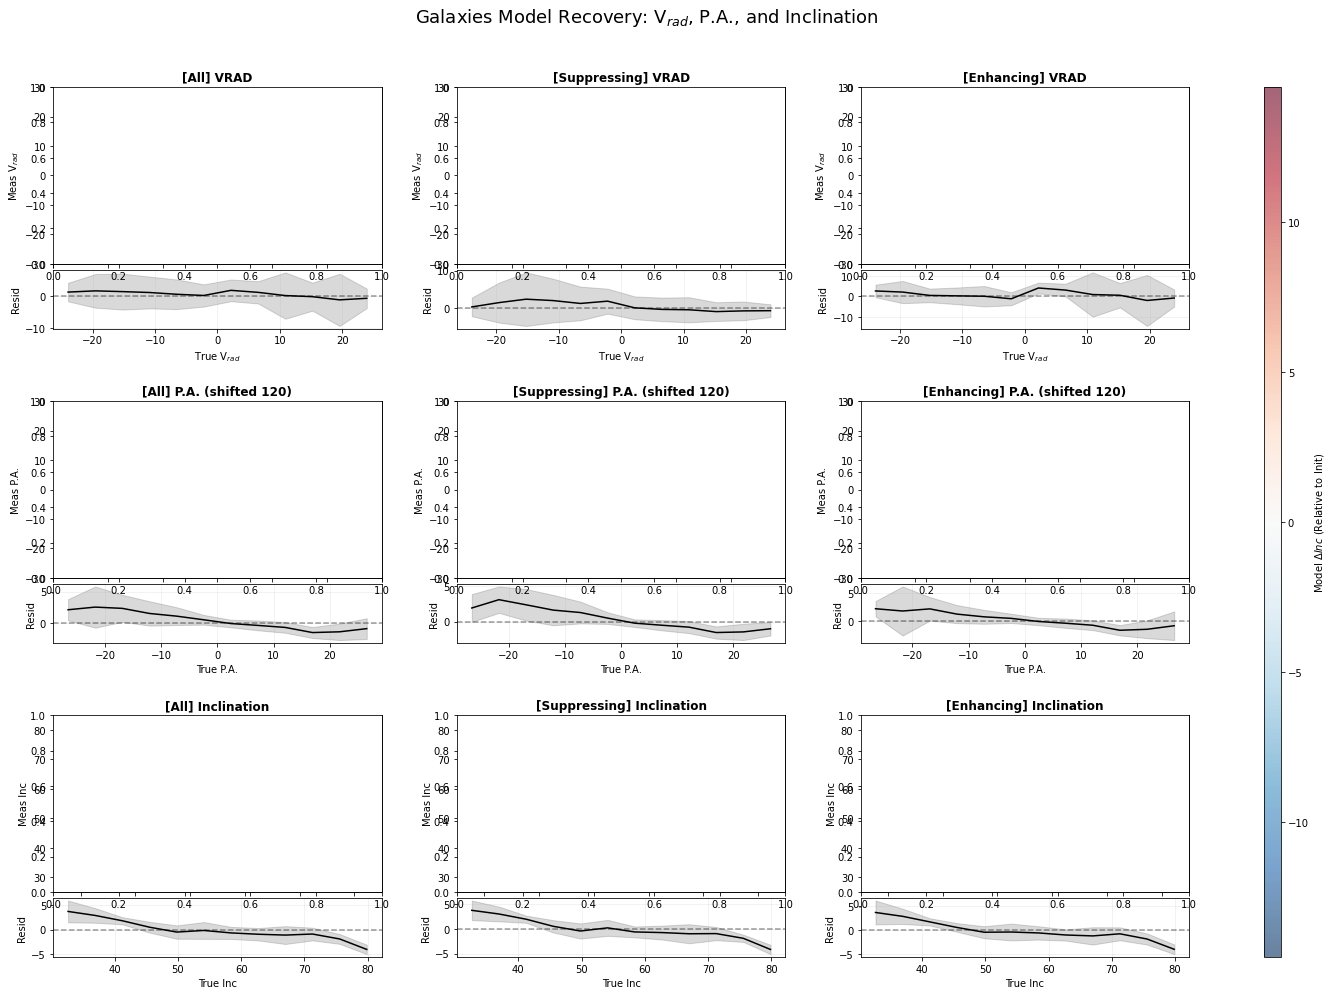

In [19]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm

# ==========================================
# 1. PATH CONFIG
# ==========================================
RING_MODEL_DIR = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/varied_inc/"
INITIAL_DIR    = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/varied_inc/initial/"

# ==========================================
# 2. FILENAME PARSER
# ==========================================
pat_fname = re.compile(
    r"^(?:\d+_)?ring_"
    r"v(?P<v>\d+)_R(?P<R>\d+)_"
    r"(?:(?:PAfixed)|PAk(?P<pa_k>-?\d*\.?\d+)_TP(?P<pa_tp>-?\d*\.?\d+))_"
    r"VR(?:(?:k(?P<vr_k>-?\d*\.?\d+)_TP(?P<vr_tp>-?\d*\.?\d+))|(?P<vr_fixed>0))_"
    r"INC(?P<inc>\d+)(?:k(?P<inc_k>-?\d*\.?\d+)_TP(?P<inc_tp>-?\d*\.?\d+))?"
    r"(?:_Res\d+)?"
)

def compute_sign(pa_k, vr_k):
    if pa_k is None or vr_k is None or vr_k == 0:
        return 0
    return 1 if pa_k * vr_k > 0 else -1

# ==========================================
# 3. DATA LOADING WITH FILTERS
# ==========================================
def load_single_file(fname):
    m = pat_fname.match(fname)
    if not m: return None
    g = m.groupdict()
    
    inc_base = int(g["inc"]) if g.get("inc") else None
    inc_k = float(g["inc_k"]) if g.get("inc_k") else 0.0
    inc_tp = float(g["inc_tp"]) if g.get("inc_tp") else 0.0

    # 倾角过滤逻辑
    if inc_base == 75 and inc_k < 0:
        if not (abs(inc_k - (-0.05)) < 1e-4 and abs(inc_tp - 450.0) < 1e-4):
            return None

    in_path = os.path.join(INITIAL_DIR, fname)
    base, _ = os.path.splitext(fname)
    out_path = os.path.join(RING_MODEL_DIR, base + "_SNR10", "second_step_check_sinw", "rings_final2.txt")

    if not os.path.exists(in_path) or not os.path.exists(out_path):
        return None

    try:
        df_in  = pd.read_csv(in_path, sep='\s+')
        df_out = pd.read_csv(out_path, sep='\s+')
        n = min(len(df_in), len(df_out))
        
        df = pd.DataFrame({
            "Filename": fname,
            "True_VRAD": df_in["VRAD(km/s)"][:n].values,
            "Measured_VRAD": df_out["VRAD(km/s)"][:n].values,
            "True_PA": df_in["P.A.(deg)"][:n].values,
            "Measured_PA": df_out["P.A.(deg)"][:n].values,
            "True_INC": df_in["INC(deg)"][:n].values,
            "Measured_INC": df_out["INC(deg)"][:n].values,
            "Delta_INC_Init": df_in["INC(deg)"][:n].values - inc_base,
            "sign": compute_sign(float(g["pa_k"]) if g.get("pa_k") else None, 
                                 float(g["vr_k"]) if g.get("vr_k") else None)
        })
        df["PA_Residue"] = np.abs(df["Measured_PA"] - df["True_PA"])
        return df[df["True_VRAD"] != 0].reset_index(drop=True)
    except: return None

def load_all_data():
    dfs = []
    for fp in sorted(glob.glob(os.path.join(INITIAL_DIR, "*.txt"))):
        if "v200" not in fp: continue
        df = load_single_file(os.path.basename(fp))
        if df is not None: dfs.append(df)
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

# ==========================================
# 4. PLOTTING UTILS
# ==========================================
def bin_stats(x, y, nbins=12):
    df = pd.DataFrame({"x": x, "y": y})
    df["res"] = df["y"] - df["x"]
    # 自动处理 x 范围较窄的情况
    if df["x"].max() == df["x"].min():
        bins = np.linspace(df["x"].min()-1, df["x"].max()+1, nbins + 1)
    else:
        bins = np.linspace(df["x"].min(), df["x"].max(), nbins + 1)
    df["bin"] = pd.cut(df["x"], bins=bins, include_lowest=True)
    g = df.groupby("bin", observed=False)
    xc = 0.5 * (bins[:-1] + bins[1:])
    return xc, g["res"].mean().values, g["res"].std().values

def plot_panel(ax_sc, ax_rs, df, xcol, ycol, label, cmap, norm, offset=0, xlim=(-30,30)):
    x = df[xcol] - offset
    y = df[ycol] - offset
    
    sc = ax_sc.scatter(x, y, c=df["Delta_INC_Init"], cmap=cmap, norm=norm, s=15, alpha=0.6, edgecolor="none")
    
    xc, mu, sig = bin_stats(x, y)
    ax_rs.plot(xc, mu, color="k", lw=1.5)
    ax_rs.fill_between(xc, mu - sig, mu + sig, color="k", alpha=0.15)

    ax_sc.plot([xlim[0], xlim[1]], [xlim[0], xlim[1]], "k--", lw=1, alpha=0.5)
    ax_sc.set_xlim(xlim); ax_sc.set_ylim(xlim)
    ax_sc.set_ylabel(f"Meas {label}")
    ax_sc.tick_params(labelbottom=False)
    ax_sc.grid(alpha=0.2)

    ax_rs.axhline(0, ls="--", color="k", alpha=0.4)
    ax_rs.set_ylabel("Resid")
    ax_rs.set_xlabel(f"True {label}")
    ax_rs.grid(alpha=0.2)
    return sc

# ==========================================
# 5. MAIN NINE-PANEL FIGURE
# ==========================================
def plot_nine_panel(df_all):
    df_supp = df_all[df_all["sign"] > 0]
    df_enh  = df_all[df_all["sign"] < 0]
    datasets = [("All", df_all), ("Suppressing", df_supp), ("Enhancing", df_enh)]
    
    # 颜色条范围：根据倾角的变化量（相对于初始值）
    dmax = np.max(np.abs(df_all["Delta_INC_Init"])) if not df_all.empty else 10
    norm = TwoSlopeNorm(vmin=-dmax, vcenter=0.0, vmax=dmax)
    cmap = plt.get_cmap("RdBu_r")

    fig = plt.figure(figsize=(22, 16))
    outer = gridspec.GridSpec(3, 4, width_ratios=[1, 1, 1, 0.05], hspace=0.3, wspace=0.3)

    for i, (name, df) in enumerate(datasets):
        if df.empty: continue
        
        # Row 1: VRAD
        inner_v = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[0, i], height_ratios=[3, 1], hspace=0.05)
        plot_panel(fig.add_subplot(inner_v[0]), fig.add_subplot(inner_v[1]), df, "True_VRAD", "Measured_VRAD", "V$_{rad}$", cmap, norm)
        fig.add_subplot(inner_v[0]).set_title(f"[{name}] VRAD", fontweight="bold")

        # Row 2: PA (offset 120)
        inner_p = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[1, i], height_ratios=[3, 1], hspace=0.05)
        plot_panel(fig.add_subplot(inner_p[0]), fig.add_subplot(inner_p[1]), df, "True_PA", "Measured_PA", "P.A.", cmap, norm, offset=120)
        fig.add_subplot(inner_p[0]).set_title(f"[{name}] P.A. (shifted 120)", fontweight="bold")

        # Row 3: INC (New!)
        # 注意：INC 不需要 offset，但 xlim 可能需要根据 30-80 度范围调整，这里为了统一先设为 (25, 85)
        inner_i = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[2, i], height_ratios=[3, 1], hspace=0.05)
        mappable = plot_panel(fig.add_subplot(inner_i[0]), fig.add_subplot(inner_i[1]), df, "True_INC", "Measured_INC", "Inc", cmap, norm, xlim=(25, 85))
        fig.add_subplot(inner_i[0]).set_title(f"[{name}] Inclination", fontweight="bold")

    cbar_ax = fig.add_subplot(outer[:, 3])
    plt.colorbar(mappable, cax=cbar_ax, label=r"Model $\Delta Inc$ (Relative to Init)")
    plt.suptitle("Galaxies Model Recovery: V$_{rad}$, P.A., and Inclination", fontsize=18, y=0.95)
    plt.show()

if __name__ == "__main__":
    df_all = load_all_data()
    if not df_all.empty:
        # 定位异常
        outliers = df_all[df_all["PA_Residue"] > 10]
        if not outliers.empty:
            print("\n" + "!"*50 + "\nOUTLIERS (PA Residue > 10):")
            print(outliers.groupby("Filename")["PA_Residue"].max().sort_values(ascending=False))
            print("!"*50 + "\n")
        
        plot_nine_panel(df_all)

Loading data...
Total points after filtering: 4184

PA outliers (>10 deg):
Filename
ring_v200_R50_PAk0.1_TP300.0_VRk-0.05_TP300.0_INC60k-0.05_TP300_Res30.txt    14.00
ring_v200_R50_PAk0.05_TP300.0_VRk0.05_TP300.0_INC45k0.05_TP300_Res30.txt     13.25
Name: PA_Residue, dtype: float64


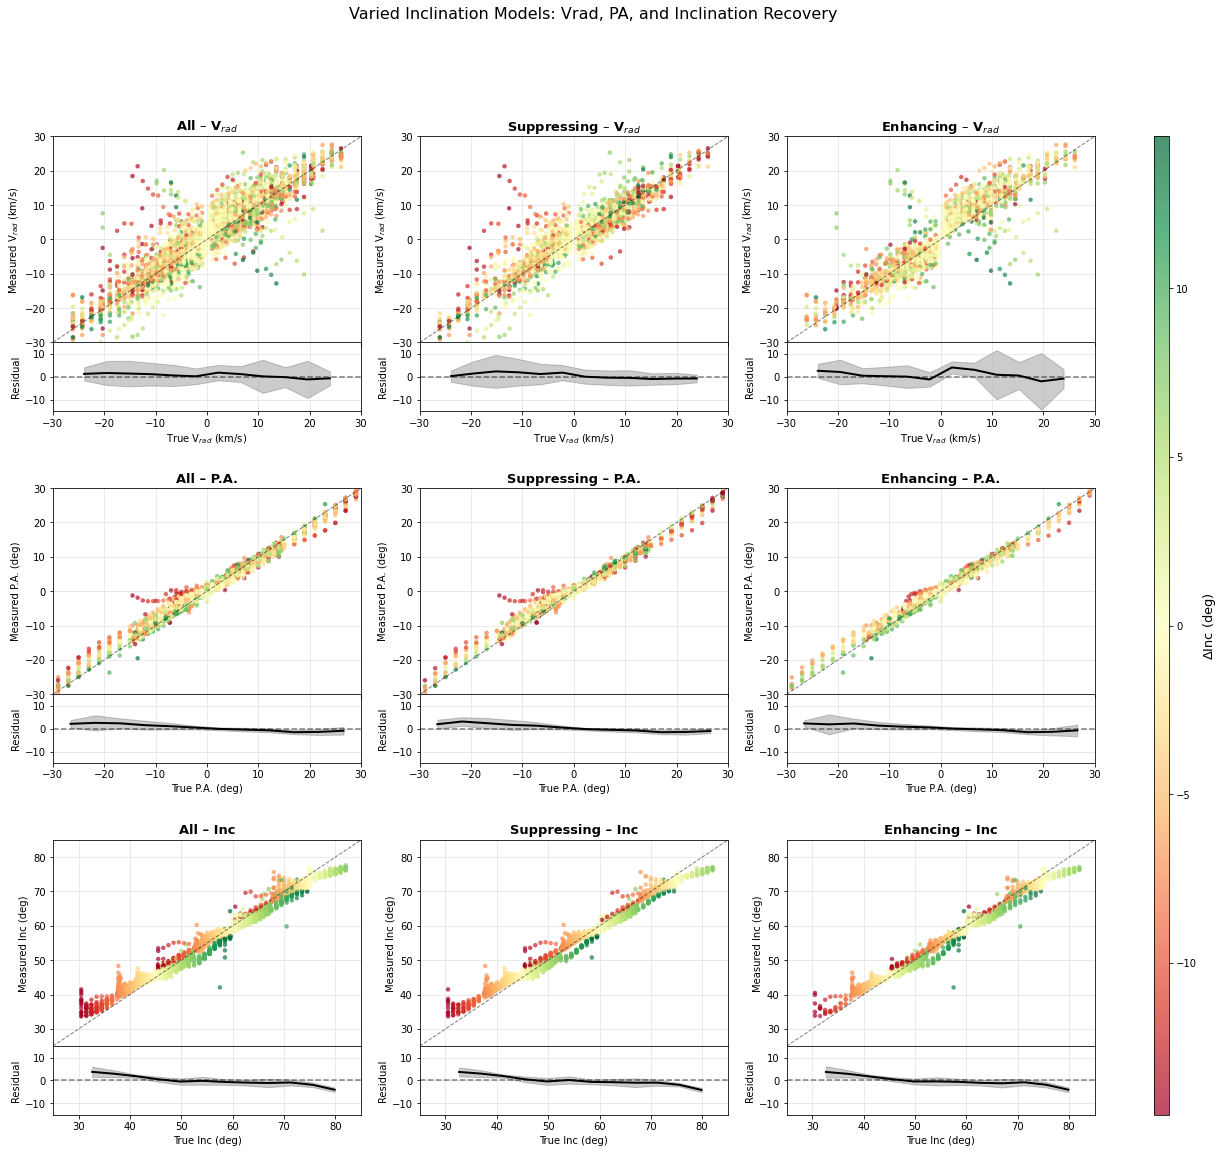

In [25]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm

# ==========================================
# 1. PATH CONFIG
# ==========================================
RING_MODEL_DIR = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/varied_inc/"
INITIAL_DIR    = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/varied_inc/initial/"

# ==========================================
# 2. FILENAME PARSER
# ==========================================
pat_fname = re.compile(
    r"^(?:\d+_)?ring_"
    r"v(?P<v>\d+)_R(?P<R>\d+)_"
    r"(?:(?:PAfixed)|PAk(?P<pa_k>-?\d*\.?\d+)_TP(?P<pa_tp>-?\d*\.?\d+))_"
    r"VR(?:(?:k(?P<vr_k>-?\d*\.?\d+)_TP(?P<vr_tp>-?\d*\.?\d+))|(?P<vr_fixed>0))_"
    r"INC(?P<inc>\d+)(?:k(?P<inc_k>-?\d*\.?\d+)_TP(?P<inc_tp>-?\d*\.?\d+))?"
    r"(?:_Res\d+)?"
)

def compute_sign(pa_k, vr_k):
    if pa_k is None or vr_k is None or vr_k == 0:
        return 0
    return 1 if pa_k * vr_k > 0 else -1

# ==========================================
# 3. DATA LOADING (WITH FILTER)
# ==========================================
def load_single_file(fname):
    m = pat_fname.match(fname)
    if not m:
        return None

    g = m.groupdict()

    pa_k = float(g["pa_k"]) if g.get("pa_k") else None
    vr_k = float(g["vr_k"]) if g.get("vr_k") else None

    inc_base = int(g["inc"]) if g.get("inc") else None
    inc_k    = float(g["inc_k"]) if g.get("inc_k") else 0.0
    inc_tp   = float(g["inc_tp"]) if g.get("inc_tp") else 0.0

    # -------- inc=75 filtering --------
    if inc_base == 75 and inc_k < 0:
        if not (np.isclose(inc_k, -0.05) and np.isclose(inc_tp, 450.0)):
            return None
    # ----------------------------------

    in_path = os.path.join(INITIAL_DIR, fname)
    if not os.path.exists(in_path):
        return None

    base, _ = os.path.splitext(fname)
    out_path = os.path.join(
        RING_MODEL_DIR,
        base + "_SNR10",
        "second_step_check_sinw",
        "rings_final2.txt"
    )
    if not os.path.exists(out_path):
        return None

    df_in  = pd.read_csv(in_path, sep='\s+')
    df_out = pd.read_csv(out_path, sep='\s+')

    n = min(len(df_in), len(df_out))
    delta_inc = df_in["INC(deg)"][:n].values - inc_base

    df = pd.DataFrame({
        "Filename": fname,
        "True_VRAD": df_in["VRAD(km/s)"][:n].values,
        "Measured_VRAD": df_out["VRAD(km/s)"][:n].values,
        "True_PA": df_in["P.A.(deg)"][:n].values,
        "Measured_PA": df_out["P.A.(deg)"][:n].values,
        "True_INC": df_in["INC(deg)"][:n].values,
        "Measured_INC": df_out["INC(deg)"][:n].values,
        "Delta_INC": delta_inc,
        "sign": compute_sign(pa_k, vr_k),
    })

    df["PA_Residue"]  = np.abs(df["Measured_PA"] - df["True_PA"])
    df["Inc_Residue"] = df["Measured_INC"] - df["True_INC"]

    return df[df["True_VRAD"] != 0].reset_index(drop=True)

def load_all_data():
    dfs = []
    for fp in sorted(glob.glob(os.path.join(INITIAL_DIR, "*.txt"))):
        fname = os.path.basename(fp)
        if "v200" not in fname:
            continue
        df = load_single_file(fname)
        if df is not None:
            dfs.append(df)
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

# ==========================================
# 4. BIN STATS
# ==========================================
def bin_stats(x, y, nbins=12):
    df = pd.DataFrame({"x": x, "y": y})
    df["res"] = df["y"] - df["x"]
    bins = np.linspace(df["x"].min(), df["x"].max(), nbins + 1)
    df["bin"] = pd.cut(df["x"], bins=bins, include_lowest=True)
    g = df.groupby("bin", observed=False)
    xc = 0.5 * (bins[:-1] + bins[1:])
    return xc, g["res"].mean().values, g["res"].std().values

# ==========================================
# 5. GENERIC PANEL
# ==========================================
def plot_panel(ax_sc, ax_rs, df, xcol, ycol, label, is_pa, cmap, norm, is_inc=False):
    x = df[xcol] - 120 if is_pa else df[xcol]
    y = df[ycol] - 120 if is_pa else df[ycol]

    sc = ax_sc.scatter(
        x, y,
        c=df["Delta_INC"],
        cmap=cmap, norm=norm,
        s=20, alpha=0.7, edgecolor="none"
    )

    xc, mu, sig = bin_stats(x, y)
    ax_rs.plot(xc, mu, color="k", lw=2)
    ax_rs.fill_between(xc, mu - sig, mu + sig, color="k", alpha=0.2)

    # ---- axis control ----
    if is_inc:
        ax_sc.set_xlim(25, 85)
        ax_sc.set_ylim(25, 85)
        ax_sc.plot([25, 85], [25, 85], "k--", lw=1, alpha=0.5)
    else:
        ax_sc.set_xlim(-30, 30)
        ax_sc.set_ylim(-30, 30)
        ax_sc.plot([-30, 30], [-30, 30], "k--", lw=1, alpha=0.5)

    ax_sc.grid(alpha=0.3)
    ax_sc.set_ylabel(f"Measured {label}")
    ax_sc.tick_params(labelbottom=False)

    ax_rs.set_ylim(-15, 15)
    ax_rs.axhline(0, ls="--", color="k", alpha=0.5)
    ax_rs.grid(alpha=0.3)
    ax_rs.set_xlabel(f"True {label}")
    ax_rs.set_ylabel("Residual")

    return sc

# ==========================================
# 6. 3×3 FIGURE
# ==========================================
def plot_nine_panel(df_all, df_supp, df_enh, title):
    datasets = [("All", df_all), ("Suppressing", df_supp), ("Enhancing", df_enh)]

    dmax = np.max(np.abs(df_all["Delta_INC"]))
    norm = TwoSlopeNorm(vmin=-dmax, vcenter=0.0, vmax=dmax)
    cmap = plt.get_cmap("RdYlGn")

    fig = plt.figure(figsize=(20, 18))
    fig.suptitle(title, fontsize=16)

    outer = gridspec.GridSpec(
        3, 4,
        width_ratios=[1, 1, 1, 0.05],
        hspace=0.28,
        wspace=0.25
    )

    mappable = None

    rows = [
        ("True_VRAD", "Measured_VRAD", "V$_{rad}$ (km/s)", False, False),
        ("True_PA",   "Measured_PA",  "P.A. (deg)",       True,  False),
        ("True_INC",  "Measured_INC", "Inc (deg)",        False, True),
    ]

    for r, (xcol, ycol, label, is_pa, is_inc) in enumerate(rows):
        for i, (name, df) in enumerate(datasets):
            if df.empty:
                continue

            inner = gridspec.GridSpecFromSubplotSpec(
                2, 1, subplot_spec=outer[r, i],
                height_ratios=[3, 1], hspace=0
            )
            ax_sc = fig.add_subplot(inner[0])
            ax_rs = fig.add_subplot(inner[1], sharex=ax_sc)

            mappable = plot_panel(
                ax_sc, ax_rs, df,
                xcol, ycol, label,
                is_pa, cmap, norm,
                is_inc=is_inc
            )

            ax_sc.set_title(f"{name} – {label.split()[0]}", fontsize=13, fontweight="bold")

    if mappable is not None:
        cax = fig.add_subplot(outer[:, 3])
        cbar = plt.colorbar(mappable, cax=cax)
        cbar.set_label(r"$\Delta \mathrm{Inc}$ (deg)", fontsize=13)
    plt.savefig("figure3-incforincvariedgalaxies.pdf")
    plt.show()

# ==========================================
# 7. MAIN
# ==========================================
if __name__ == "__main__":
    print("Loading data...")
    df_all = load_all_data()
    print(f"Total points after filtering: {len(df_all)}")

    outliers = df_all[df_all["PA_Residue"] > 10]
    if not outliers.empty:
        print("\nPA outliers (>10 deg):")
        print(outliers.groupby("Filename")["PA_Residue"].max().sort_values(ascending=False))

    df_supp = df_all[df_all["sign"] > 0]
    df_enh  = df_all[df_all["sign"] < 0]

    plot_nine_panel(
        df_all, df_supp, df_enh,
        "Varied Inclination Models: Vrad, PA, and Inclination Recovery"
    )


Loading data...


/tmp/ipykernel_757318/3358615484.py:63: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_in  = pd.read_csv(in_path, delim_whitespace=True)
/tmp/ipykernel_757318/3358615484.py:64: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_out = pd.read_csv(out_path, delim_whitespace=True)
/tmp/ipykernel_757318/3358615484.py:63: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_in  = pd.read_csv(in_path, delim_whitespace=True)
/tmp/ipykernel_757318/3358615484.py:64: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_out = pd.read_csv(out_path, delim_whitespace=True)
/tmp/ipykernel_757318/3358615484.py:63: FutureWarn

Total points after filtering: 4184


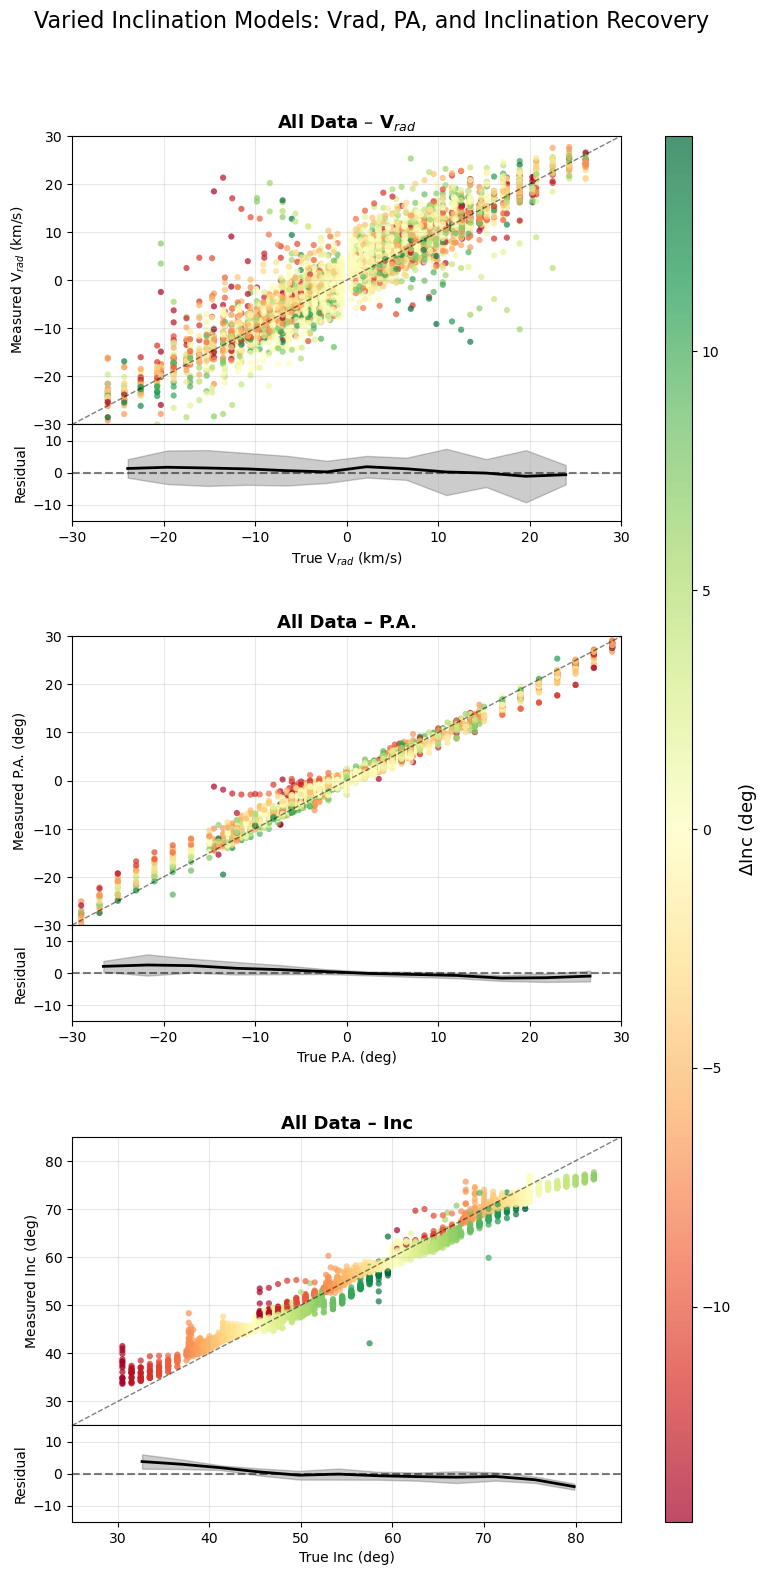

In [5]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm

# ==========================================
# 1. PATH CONFIG
# ==========================================
RING_MODEL_DIR = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/varied_inc/"
INITIAL_DIR    = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/varied_inc/initial/"

# ==========================================
# 2. FILENAME PARSER
# ==========================================
pat_fname = re.compile(
    r"^(?:\d+_)?ring_"
    r"v(?P<v>\d+)_R(?P<R>\d+)_"
    r"(?:(?:PAfixed)|PAk(?P<pa_k>-?\d*\.?\d+)_TP(?P<pa_tp>-?\d*\.?\d+))_"
    r"VR(?:(?:k(?P<vr_k>-?\d*\.?\d+)_TP(?P<vr_tp>-?\d*\.?\d+))|(?P<vr_fixed>0))_"
    r"INC(?P<inc>\d+)(?:k(?P<inc_k>-?\d*\.?\d+)_TP(?P<inc_tp>-?\d*\.?\d+))?"
    r"(?:_Res\d+)?"
)

# ==========================================
# 3. DATA LOADING
# ==========================================
def load_single_file(fname):
    m = pat_fname.match(fname)
    if not m:
        return None

    g = m.groupdict()
    inc_base = int(g["inc"]) if g.get("inc") else None
    inc_k    = float(g["inc_k"]) if g.get("inc_k") else 0.0
    inc_tp   = float(g["inc_tp"]) if g.get("inc_tp") else 0.0

    # -------- inc=75 filtering --------
    if inc_base == 75 and inc_k < 0:
        if not (np.isclose(inc_k, -0.05) and np.isclose(inc_tp, 450.0)):
            return None

    in_path = os.path.join(INITIAL_DIR, fname)
    if not os.path.exists(in_path):
        return None

    base, _ = os.path.splitext(fname)
    out_path = os.path.join(
        RING_MODEL_DIR,
        base + "_SNR10",
        "second_step_check_sinw",
        "rings_final2.txt"
    )
    if not os.path.exists(out_path):
        return None

    df_in  = pd.read_csv(in_path, sep='\s+')
    df_out = pd.read_csv(out_path, sep='\s+')

    n = min(len(df_in), len(df_out))
    delta_inc = df_in["INC(deg)"][:n].values - inc_base

    df = pd.DataFrame({
        "Filename": fname,
        "True_VRAD": df_in["VRAD(km/s)"][:n].values,
        "Measured_VRAD": df_out["VRAD(km/s)"][:n].values,
        "True_PA": df_in["P.A.(deg)"][:n].values,
        "Measured_PA": df_out["P.A.(deg)"][:n].values,
        "True_INC": df_in["INC(deg)"][:n].values,
        "Measured_INC": df_out["INC(deg)"][:n].values,
        "Delta_INC": delta_inc,
    })

    df["PA_Residue"]  = np.abs(df["Measured_PA"] - df["True_PA"])
    return df[df["True_VRAD"] != 0].reset_index(drop=True)

def load_all_data():
    dfs = []
    for fp in sorted(glob.glob(os.path.join(INITIAL_DIR, "*.txt"))):
        fname = os.path.basename(fp)
        if "v200" not in fname:
            continue
        df = load_single_file(fname)
        if df is not None:
            dfs.append(df)
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

# ==========================================
# 4. BIN STATS
# ==========================================
def bin_stats(x, y, nbins=12):
    df = pd.DataFrame({"x": x, "y": y})
    df["res"] = df["y"] - df["x"]
    bins = np.linspace(df["x"].min(), df["x"].max(), nbins + 1)
    df["bin"] = pd.cut(df["x"], bins=bins, include_lowest=True)
    g = df.groupby("bin", observed=False)
    xc = 0.5 * (bins[:-1] + bins[1:])
    return xc, g["res"].mean().values, g["res"].std().values

# ==========================================
# 5. GENERIC PANEL
# ==========================================
def plot_panel(ax_sc, ax_rs, df, xcol, ycol, label, is_pa, cmap, norm, is_inc=False):
    x = df[xcol] - 120 if is_pa else df[xcol]
    y = df[ycol] - 120 if is_pa else df[ycol]

    sc = ax_sc.scatter(
        x, y,
        c=df["Delta_INC"],
        cmap=cmap, norm=norm,
        s=20, alpha=0.7, edgecolor="none"
    )

    xc, mu, sig = bin_stats(x, y)
    ax_rs.plot(xc, mu, color="k", lw=2)
    ax_rs.fill_between(xc, mu - sig, mu + sig, color="k", alpha=0.2)

    # ---- axis control ----
    if is_inc:
        ax_sc.set_xlim(25, 85)
        ax_sc.set_ylim(25, 85)
        ax_sc.plot([25, 85], [25, 85], "k--", lw=1, alpha=0.5)
    else:
        ax_sc.set_xlim(-30, 30)
        ax_sc.set_ylim(-30, 30)
        ax_sc.plot([-30, 30], [-30, 30], "k--", lw=1, alpha=0.5)

    ax_sc.grid(alpha=0.3)
    ax_sc.set_ylabel(f"Measured {label}")
    ax_sc.tick_params(labelbottom=False)

    ax_rs.set_ylim(-15, 15)
    ax_rs.axhline(0, ls="--", color="k", alpha=0.5)
    ax_rs.grid(alpha=0.3)
    ax_rs.set_xlabel(f"True {label}")
    ax_rs.set_ylabel("Residual")

    return sc

# ==========================================
# 6. 3×1 FIGURE (SINGLE COLUMN)
# ==========================================
def plot_single_column(df_all, title):
    dmax = np.max(np.abs(df_all["Delta_INC"]))
    norm = TwoSlopeNorm(vmin=-dmax, vcenter=0.0, vmax=dmax)
    cmap = plt.get_cmap("RdYlGn")

    # 调整画布大小，单列建议宽度减小
    fig = plt.figure(figsize=(8, 18))
    fig.suptitle(title, fontsize=16, y=0.95)

    # 3行 2列：绘图区 + 颜色条区
    outer = gridspec.GridSpec(
        3, 2,
        width_ratios=[1, 0.05],
        hspace=0.3,
        wspace=0.15
    )

    rows = [
        ("True_VRAD", "Measured_VRAD", "V$_{rad}$ (km/s)", False, False),
        ("True_PA",   "Measured_PA",  "P.A. (deg)",        True,  False),
        ("True_INC",  "Measured_INC", "Inc (deg)",         False, True),
    ]

    mappable = None

    for r, (xcol, ycol, label, is_pa, is_inc) in enumerate(rows):
        # 为每一行创建独立的上下子图（散点图+残差图）
        inner = gridspec.GridSpecFromSubplotSpec(
            2, 1, subplot_spec=outer[r, 0],
            height_ratios=[3, 1], hspace=0
        )
        
        ax_sc = fig.add_subplot(inner[0])
        ax_rs = fig.add_subplot(inner[1], sharex=ax_sc)

        mappable = plot_panel(
            ax_sc, ax_rs, df_all,
            xcol, ycol, label,
            is_pa, cmap, norm,
            is_inc=is_inc
        )

        ax_sc.set_title(f"All Data – {label.split()[0]}", fontsize=13, fontweight="bold")

    # 在右侧添加颜色条
    if mappable is not None:
        cax = fig.add_subplot(outer[:, 1])
        cbar = plt.colorbar(mappable, cax=cax)
        cbar.set_label(r"$\Delta \mathrm{Inc}$ (deg)", fontsize=13)

    plt.savefig("figure_vrad_pa_inc_single.pdf", bbox_inches='tight')
    plt.show()

# ==========================================
# 7. MAIN
# ==========================================
if __name__ == "__main__":
    print("Loading data...")
    df_all = load_all_data()
    
    if df_all.empty:
        print("No data found. Check your paths and filters.")
    else:
        print(f"Total points after filtering: {len(df_all)}")
        
        plot_single_column(
            df_all,
            "Varied Inclination Models: Vrad, PA, and Inclination Recovery"
        )

Loading data...
Total points: 4184


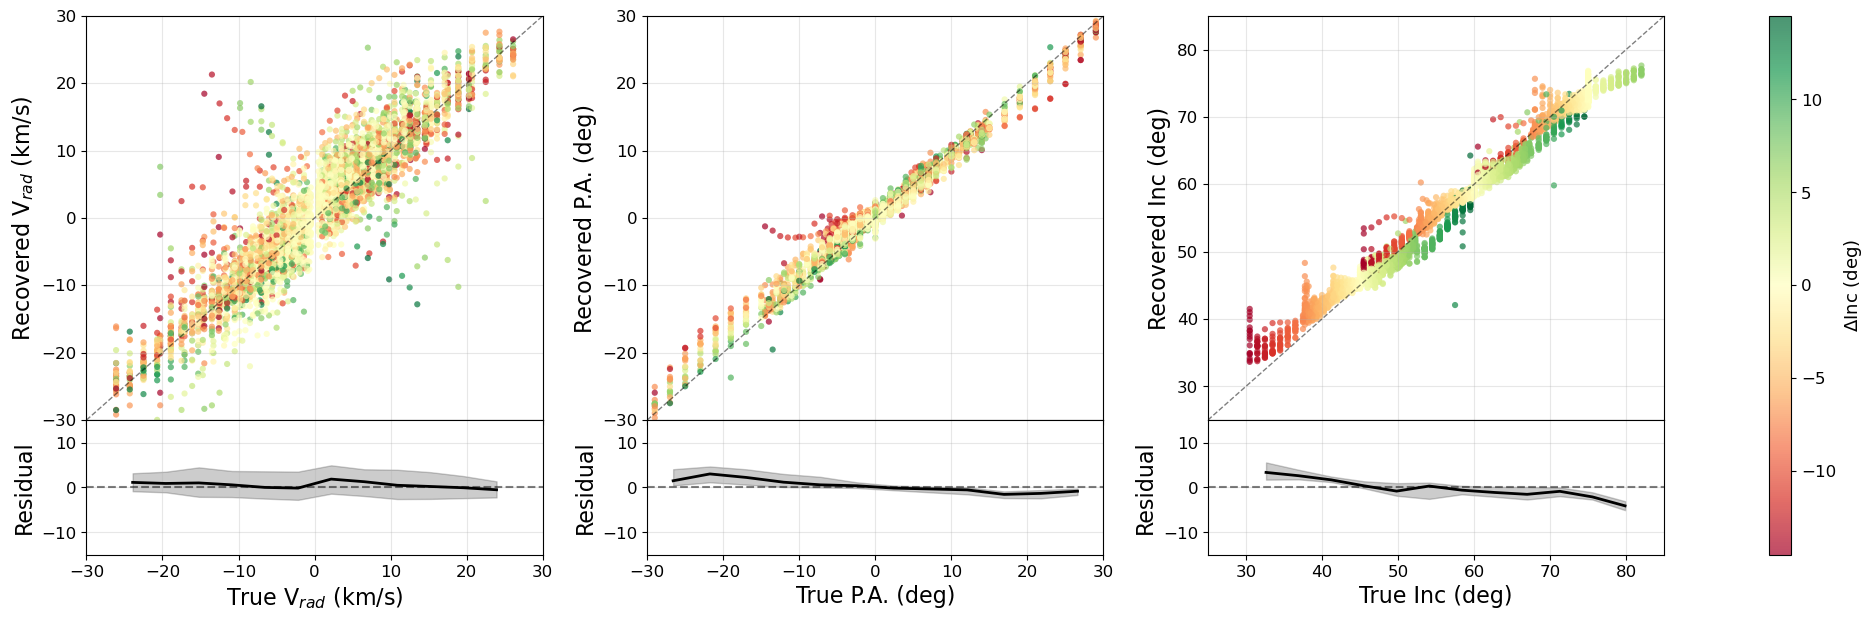

In [12]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm
plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 13,
})
# ==========================================
# 1. PATH CONFIG
# ==========================================
RING_MODEL_DIR = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/varied_inc/"
INITIAL_DIR    = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/varied_inc/initial/"

# ==========================================
# 2. FILENAME PARSER
# ==========================================
pat_fname = re.compile(
    r"^(?:\d+_)?ring_"
    r"v(?P<v>\d+)_R(?P<R>\d+)_"
    r"(?:(?:PAfixed)|PAk(?P<pa_k>-?\d*\.?\d+)_TP(?P<pa_tp>-?\d*\.?\d+))_"
    r"VR(?:(?:k(?P<vr_k>-?\d*\.?\d+)_TP(?P<vr_tp>-?\d*\.?\d+))|(?P<vr_fixed>0))_"
    r"INC(?P<inc>\d+)(?:k(?P<inc_k>-?\d*\.?\d+)_TP(?P<inc_tp>-?\d*\.?\d+))?"
    r"(?:_Res\d+)?"
)

# ==========================================
# 3. DATA LOADING
# ==========================================
def load_single_file(fname):
    m = pat_fname.match(fname)
    if not m: return None
    g = m.groupdict()

    inc_base = int(g["inc"]) if g.get("inc") else None
    inc_k    = float(g["inc_k"]) if g.get("inc_k") else 0.0
    inc_tp   = float(g["inc_tp"]) if g.get("inc_tp") else 0.0

    if inc_base == 75 and inc_k < 0:
        if not (np.isclose(inc_k, -0.05) and np.isclose(inc_tp, 450.0)):
            return None

    in_path = os.path.join(INITIAL_DIR, fname)
    if not os.path.exists(in_path): return None

    base, _ = os.path.splitext(fname)
    out_path = os.path.join(RING_MODEL_DIR, base + "_SNR10", "second_step_check_sinw", "rings_final2.txt")
    if not os.path.exists(out_path): return None

    # 使用 sep='\s+' 代替 sep='\s+'
    df_in  = pd.read_csv(in_path, sep='\s+')
    df_out = pd.read_csv(out_path, sep='\s+')

    n = min(len(df_in), len(df_out))
    delta_inc = df_in["INC(deg)"][:n].values - inc_base

    df = pd.DataFrame({
        "Filename": fname,
        "True_VRAD": df_in["VRAD(km/s)"][:n].values,
        "Measured_VRAD": df_out["VRAD(km/s)"][:n].values,
        "True_PA": df_in["P.A.(deg)"][:n].values,
        "Measured_PA": df_out["P.A.(deg)"][:n].values,
        "True_INC": df_in["INC(deg)"][:n].values,
        "Measured_INC": df_out["INC(deg)"][:n].values,
        "Delta_INC": delta_inc,
    })
    return df[df["True_VRAD"] != 0].reset_index(drop=True)

def load_all_data():
    dfs = []
    for fp in sorted(glob.glob(os.path.join(INITIAL_DIR, "*.txt"))):
        fname = os.path.basename(fp)
        if "v200" not in fname: continue
        df = load_single_file(fname)
        if df is not None: dfs.append(df)
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

# ==========================================
# 4. BIN STATS (Using Median and 16/84 Percentiles)
# ==========================================
def bin_stats(x, y, nbins=12):
    df = pd.DataFrame({"x": x, "y": y})
    df["res"] = df["y"] - df["x"]
    bins = np.linspace(df["x"].min(), df["x"].max(), nbins + 1)
    df["bin"] = pd.cut(df["x"], bins=bins, include_lowest=True)
    
    g = df.groupby("bin", observed=False)["res"]
    
    xc = 0.5 * (bins[:-1] + bins[1:])
    # 计算中位数, 16% 分位数 和 84% 分位数
    median = g.median().values
    low = g.quantile(0.16).values
    high = g.quantile(0.84).values
    
    return xc, median, low, high

# ==========================================
# 5. PANEL PLOTTER
# ==========================================
def plot_panel(ax_sc, ax_rs, df, xcol, ycol, label, is_pa, cmap, norm, is_inc=False):
    x = df[xcol] - 120 if is_pa else df[xcol]
    y = df[ycol] - 120 if is_pa else df[ycol]

    sc = ax_sc.scatter(x, y, c=df["Delta_INC"], cmap=cmap, norm=norm, s=20, alpha=0.7, edgecolor="none")

    # 获取分位数统计结果
    xc, mid, low, high = bin_stats(x, y)
    
    # 绘制中位数线和 16-84 填充区域
    ax_rs.plot(xc, mid, color="k", lw=2, label="Median")
    ax_rs.fill_between(xc, low, high, color="k", alpha=0.2, label="16th-84th Pctl")

    if is_inc:
        ax_sc.set_xlim(25, 85); ax_sc.set_ylim(25, 85)
        ax_sc.plot([25, 85], [25, 85], "k--", lw=1, alpha=0.5)
    else:
        ax_sc.set_xlim(-30, 30); ax_sc.set_ylim(-30, 30)
        ax_sc.plot([-30, 30], [-30, 30], "k--", lw=1, alpha=0.5)

    ax_sc.grid(alpha=0.3); ax_sc.set_ylabel(f"Recovered {label}")
    ax_sc.tick_params(labelbottom=False)
    
    ax_rs.set_ylim(-15, 15); ax_rs.axhline(0, ls="--", color="k", alpha=0.5)
    ax_rs.grid(alpha=0.3); ax_rs.set_xlabel(f"True {label}"); ax_rs.set_ylabel("Residual")
    return sc

# ==========================================
# 6. 1×3 ROW FIGURE
# ==========================================
def plot_one_row_all(df_all, title):
    dmax = np.max(np.abs(df_all["Delta_INC"]))
    norm = TwoSlopeNorm(vmin=-dmax, vcenter=0.0, vmax=dmax)
    cmap = plt.get_cmap("RdYlGn")

    fig = plt.figure(figsize=(22, 7))
    fig.suptitle(title, fontsize=16, y=1.02)

    # 1行 4列: Vrad, PA, Inc, Colorbar
    outer = gridspec.GridSpec(1, 4, width_ratios=[1, 1, 1, 0.05], wspace=0.3)

    rows = [
        ("True_VRAD", "Measured_VRAD", "V$_{rad}$ (km/s)", False, False),
        ("True_PA",   "Measured_PA",  "P.A. (deg)",        True,  False),
        ("True_INC",  "Measured_INC", "Inc (deg)",         False, True),
    ]

    mappable = None
    for i, (xcol, ycol, label, is_pa, is_inc) in enumerate(rows):
        inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[0, i], height_ratios=[3, 1], hspace=0)
        ax_sc = fig.add_subplot(inner[0])
        ax_rs = fig.add_subplot(inner[1], sharex=ax_sc)

        mappable = plot_panel(ax_sc, ax_rs, df_all, xcol, ycol, label, is_pa, cmap, norm, is_inc=is_inc)
        #ax_sc.set_title(f"{label.split()[0]}", fontsize=14, fontweight="bold")

    if mappable is not None:
        cax = fig.add_subplot(outer[0, 3])
        plt.colorbar(mappable, cax=cax).set_label(r"$\Delta \mathrm{Inc}$ (deg)", fontsize=13)

    plt.savefig("figure_varied_inc_vrad_pa_inc_row_median.pdf", bbox_inches='tight')
    plt.show()

# ==========================================
# 7. MAIN
# ==========================================
if __name__ == "__main__":
    print("Loading data...")
    df_all = load_all_data()
    if not df_all.empty:
        print(f"Total points: {len(df_all)}")
        plot_one_row_all(df_all, "")
    else:
        print("Data empty.")

/tmp/ipykernel_987397/2173742270.py:118: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat(df_list, ignore_index=True) if df_list else pd.DataFrame()


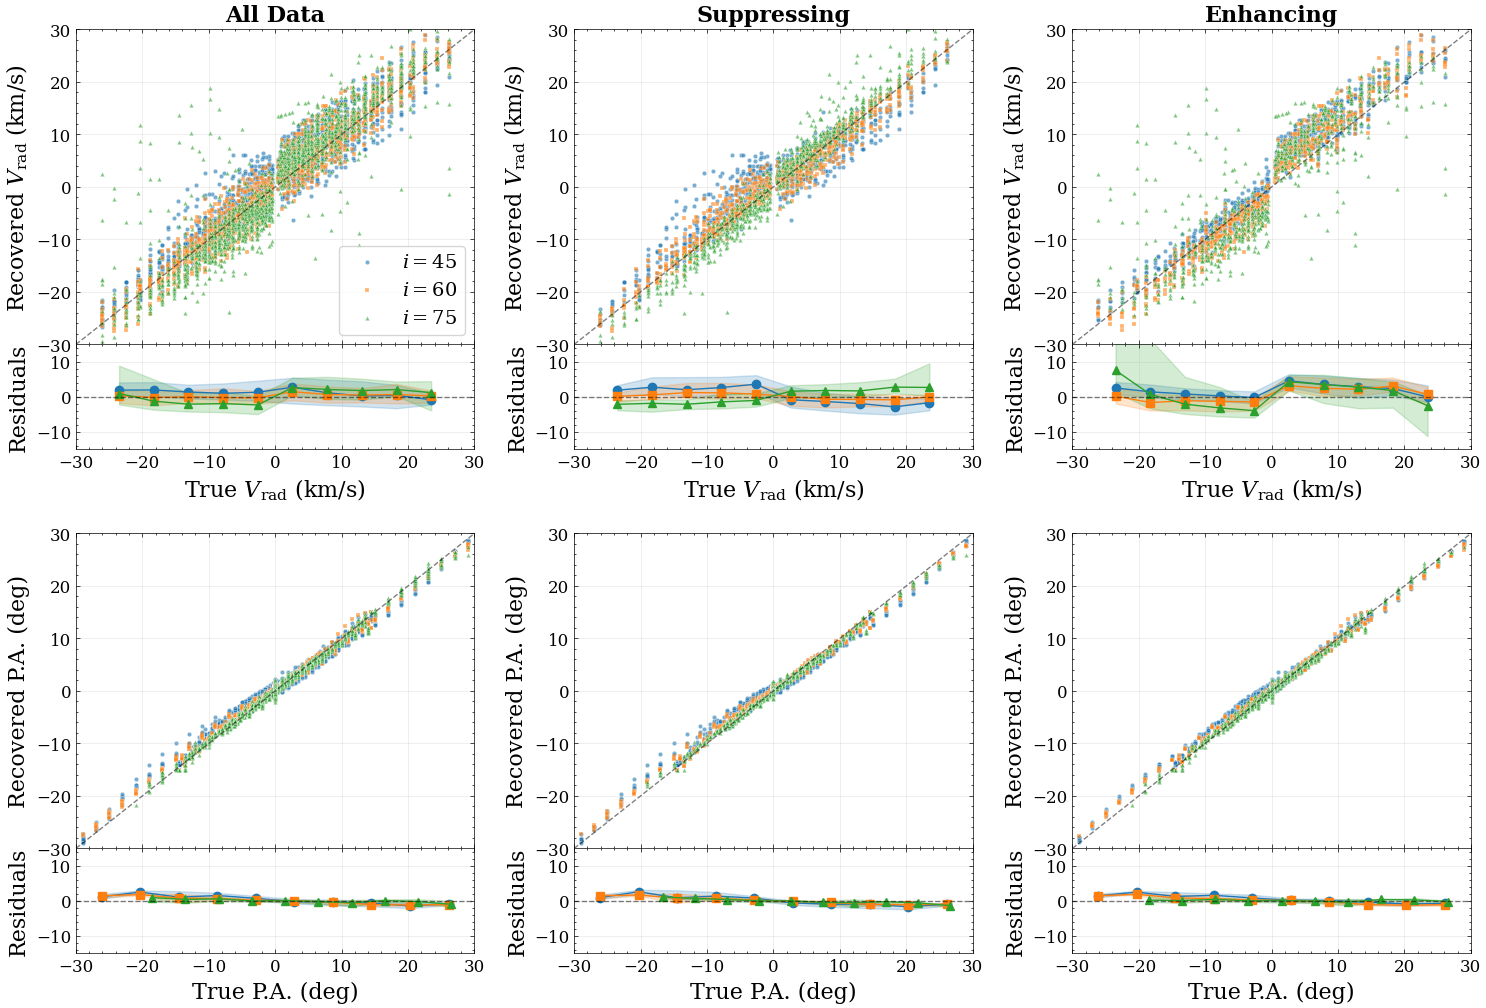

In [18]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 13,
})

plt.style.use("/net/dataserver3/data/users/linn/pic_style/science3.mplstyle")
# ==========================================
# 1. 配置与路径 (CONFIG)
# ==========================================
RING_BASE      = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/"
RING_MODEL1123 = RING_BASE + "model1123/"

INITIAL_BASE   = "/net/dataserver3/data/users/linn/para_initial/test_more_model/"
INITIAL_1123   = "/net/dataserver3/data/users/linn/para_initial/test_more_model/model1123/"

# 绘图样式配置
INC_STYLES = {
    45: dict(color="#1f77b4", marker="o", label="$i=45$"),
    60: dict(color="#ff7f0e", marker="s", label="$i=60$"),
    75: dict(color="#2ca02c", marker="^", label="$i=75$"),
}

# ==========================================
# 2. 文件名解析与辅助函数
# ==========================================
pat_fname = re.compile(
    r"^(?:\d+_)?ring_"
    r"v(?P<v>\d+)_R(?P<R>\d+)_"
    r"(?:(?:PAfixed)|PAk(?P<pa_k>-?\d*\.?\d+)_TP(?P<pa_tp>\d+))_"
    r"VR(?:(?:k(?P<vr_k>-?\d*\.?\d+)_TP(?P<vr_tp>\d+))|(?P<vr_fixed>0))_"
    r"INC(?P<inc>\d+)"
)

def compute_sign(pa_k, vr_k):
    if pa_k is None: return 0
    if vr_k is None: return 0
    if vr_k == 0: return 0
    return 1 if pa_k * vr_k > 0 else -1

# ==========================================
# 3. 数据加载函数 (DATA LOADING)
# ==========================================
def load_single_file(file_name, ring_root):
    m = pat_fname.match(file_name)
    if not m: return None

    g = m.groupdict()
    pa_k = float(g["pa_k"]) if g.get("pa_k") else None
    vr_k = float(g["vr_k"]) if g.get("vr_k") else None
    inc_val = int(g["inc"])

    if "model1123" in ring_root:
        in_path = os.path.join(INITIAL_1123, file_name)
    else:
        in_path = os.path.join(INITIAL_BASE, file_name)

    if not os.path.exists(in_path): return None

    try: inputf = pd.read_csv(in_path, delimiter=r"\s+")
    except: return None

    base_name, _ = os.path.splitext(file_name)
    out_path = os.path.join(ring_root, base_name, "second_step_check_sinw", "rings_final2.txt")
    if not os.path.exists(out_path): return None

    try: outputf = pd.read_csv(out_path, delimiter=r"\s+")
    except: return None

    n = min(len(inputf), len(outputf))
    df = pd.DataFrame({
        "True_VRAD": inputf["VRAD(km/s)"][:n].values,
        "Measured_VRAD": outputf["VRAD(km/s)"][:n].values,
        "True_PA": inputf["P.A.(deg)"][:n].values,
        "Measured_PA": outputf["P.A.(deg)"][:n].values,
        "INC": inc_val,
        "pa_k": pa_k,
        "vr_k": vr_k,
        "sign": compute_sign(pa_k, vr_k),
        "file": file_name
    })
    
    df = df[df["True_VRAD"] != 0].reset_index(drop=True)
    return df

def load_all_data():
    df_list = []
    files_1123 = sorted(glob.glob(os.path.join(RING_MODEL1123, "*.txt")))
    for fp in files_1123:
        fname = os.path.basename(fp)
        if "v200" not in fname: continue
        if "INC45" in fname or "INC75" in fname or "INC60" in fname:
            df = load_single_file(fname, RING_MODEL1123)
            if df is not None: df_list.append(df)

    files_base = sorted(glob.glob(os.path.join(RING_BASE, "*.txt")))
    for fp in files_base:
        fname = os.path.basename(fp)
        if "v200" not in fname: continue
        if "INC60" in fname:
            df = load_single_file(fname, RING_BASE)
            if df is not None: df_list.append(df)

    return pd.concat(df_list, ignore_index=True) if df_list else pd.DataFrame()

# ==========================================
# 4. 绘图与统计函数 (PLOTTING) - 已更新为 Median/16%/84%
# ==========================================
def bin_stats(x_plot, y_plot, nbins=10):
    """
    计算残差的中位数 (Median) 和 16%/84% 分位数 (取代 Mean/Sigma)
    """
    temp_df = pd.DataFrame({'x': np.array(x_plot), 'y': np.array(y_plot)})
    temp_df['res'] = temp_df['y'] - temp_df['x']

    if temp_df['x'].empty:
        return [], [], [], []
        
    bin_edges = np.linspace(temp_df['x'].min(), temp_df['x'].max(), nbins + 1)
    temp_df['bin_cat'] = pd.cut(temp_df['x'], bins=bin_edges, include_lowest=True)

    grouped = temp_df.groupby('bin_cat', observed=False)['res']
    
    # 获取统计量
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    median_res = grouped.median().values
    q16_res = grouped.quantile(0.16).values
    q84_res = grouped.quantile(0.84).values

    return bin_centers, median_res, q16_res, q84_res

def plot_combined_panel(ax_scatter, ax_resid, x, y, inc_col, label_prefix, is_pa=False, show_legend=False):
    if x.empty or y.empty: return

    for inc, style in INC_STYLES.items():
        sub = inc_col[inc_col == inc].index
        if len(sub) == 0: continue
        
        x_sub, y_sub = x.loc[sub], y.loc[sub]
        x_plot, y_plot = (x_sub - 120, y_sub - 120) if is_pa else (x_sub, y_sub)
            
        # --- Scatter ---
        ax_scatter.scatter(x_plot, y_plot, s=10, alpha=0.6, edgecolor="white", linewidth=0.3, **style)
        
        # --- Residual (Median + 16/84% Area) ---
        bin_centers, med, q16, q84 = bin_stats(x_plot, y_plot)
        if len(bin_centers) > 0:
            ax_resid.plot(bin_centers, med, **style)
            fill_style = {k: v for k, v in style.items() if k not in ['marker', 'label']}
            ax_resid.fill_between(bin_centers, q16, q84, alpha=0.2, **fill_style)

    # Decorate
    ax_scatter.set_xlim(-30, 30); ax_scatter.set_ylim(-30, 30)
    ax_scatter.plot([-30, 30], [-30, 30], "k--", lw=1, alpha=0.5)
    ax_scatter.grid(True, alpha=0.3); ax_scatter.set_ylabel(f"Recovered {label_prefix}")
    ax_scatter.tick_params(labelbottom=False)
    if show_legend: ax_scatter.legend(loc='lower right', fontsize=14, frameon=True)

    ax_resid.set_ylim(-15, 15); ax_resid.axhline(0, color='k', linestyle='--', lw=1, alpha=0.5)
    ax_resid.grid(True, alpha=0.3); ax_resid.set_xlabel(f"True {label_prefix}"); ax_resid.set_ylabel("Residuals")

def plot_six_panel_figure(df_all, df_supp, df_enh):
    fig = plt.figure(figsize=(18, 12))
    outer_grid = gridspec.GridSpec(2, 3, height_ratios=[1, 1], hspace=0.2, wspace=0.25)
    datasets = [("All Data", df_all), ("Suppressing", df_supp), ("Enhancing", df_enh)]

    for row_idx, (lab, is_pa) in enumerate([(r"$V_{\rm rad}$ (km/s)", False), ("P.A. (deg)", True)]):
        for col_idx, (name, df) in enumerate(datasets):
            inner_grid = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_grid[row_idx, col_idx], height_ratios=[3, 1], hspace=0.0)
            ax_sc = fig.add_subplot(inner_grid[0])
            ax_rs = fig.add_subplot(inner_grid[1], sharex=ax_sc)
            
            plot_combined_panel(ax_sc, ax_rs, df["True_PA" if is_pa else "True_VRAD"], 
                                df["Measured_PA" if is_pa else "Measured_VRAD"], 
                                df["INC"], label_prefix=lab, is_pa=is_pa, show_legend=(col_idx == 0 and row_idx == 0))
            if not is_pa:
                ax_sc.set_title(f"{name}", fontsize=16, fontweight='bold')

    plt.savefig("figure3-incforincfixedgalaxies.pdf")
    plt.show()

if __name__ == "__main__":
    df_all = load_all_data()
    if not df_all.empty:
        df_supp = df_all[df_all["sign"] > 0].reset_index(drop=True)
        df_enh  = df_all[df_all["sign"] < 0].reset_index(drop=True)
        plot_six_panel_figure(df_all, df_supp, df_enh)

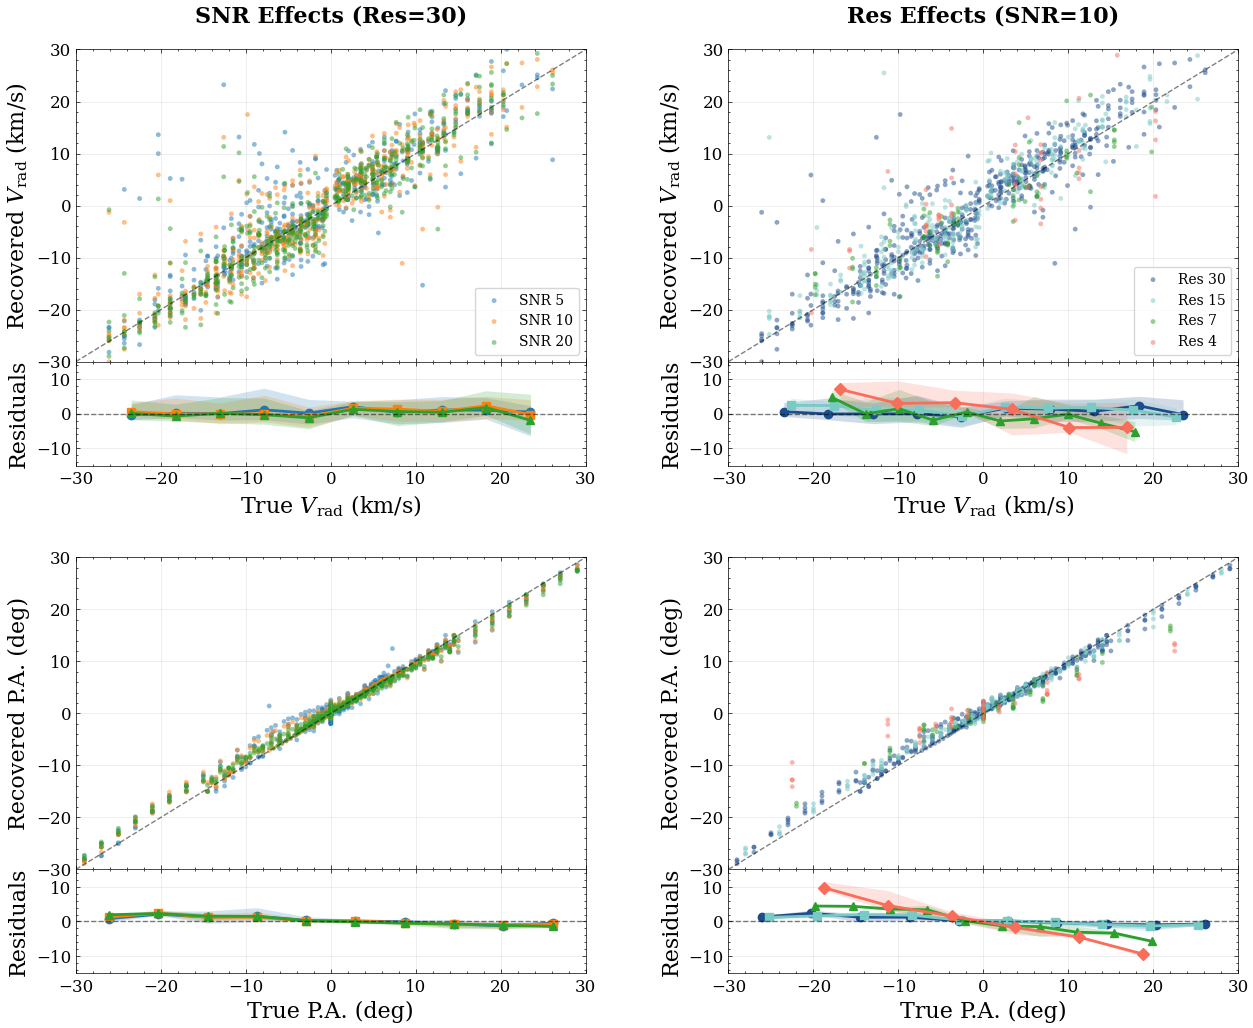

In [17]:
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ==========================================
# 1. 路径与全局配置
# ==========================================
TRUE_DIR = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/snr_res_testing/new_res_output"
RES30_BASE = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/snr_res_testing/"
OTHER_RES_BASE = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/snr_res_testing/new_res_260128/"

plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})
plt.style.use("/net/dataserver3/data/users/linn/pic_style/science3.mplstyle")
# 样式配置：使用你要求的配色风格
SNR_STYLES = {
    5:  dict(color="#1f77b4", marker="o", label="SNR 5"),
    10: dict(color="#ff7f0e", marker="s", label="SNR 10"),
    20: dict(color="#2ca02c", marker="^", label="SNR 20"),
}

RES_STYLES = {
    30: dict(color="#1C4D8D", marker="o", label="Res 30"),
    15: dict(color="#79C9C5", marker="s", label="Res 15"),
    7:  dict(color="#2ca02c", marker="^", label="Res 7"),
    4:  dict(color="#F96E5B", marker="D", label="Res 4"),
}

pat_fname = re.compile(
    r"^(?:\d+_)?ring_v(?P<v>\d+)_R(?P<R>\d+)_.*_INC(?P<inc>\d+)_Res(?P<res>\d+)\.txt$"
)

# ==========================================
# 2. 数据处理与统计函数 (Median / 16% / 84%)
# ==========================================
def load_data(base_dir, target_res=None, target_snr=None):
    df_list = []
    files = sorted(glob.glob(os.path.join(base_dir, "*Res*.txt")))
    for fp in files:
        fname = os.path.basename(fp)
        m = pat_fname.match(fname)
        if not m: continue
        res_val = int(m.group("res"))
        if target_res is not None and res_val != target_res: continue
        
        true_path = os.path.join(TRUE_DIR, fname)
        if not os.path.exists(true_path): continue
        df_true = pd.read_csv(true_path, sep='\s+')
        
        snrs = [5, 10, 20] if target_snr is None else [target_snr]
        for snr in snrs:
            folder = fname.replace(".txt", f"_SNR{snr}")
            out_path = os.path.join(base_dir, folder, "second_step_check_sinw", "rings_final2.txt")
            if not os.path.exists(out_path): continue
            
            df_out = pd.read_csv(out_path, sep='\s+')
            n = min(len(df_true), len(df_out))
            df = pd.DataFrame({
                "True_VRAD": df_true["VRAD(km/s)"].values[:n],
                "Measured_VRAD": df_out["VRAD(km/s)"].values[:n],
                "True_PA": df_true["P.A.(deg)"].values[:n],
                "Measured_PA": df_out["P.A.(deg)"].values[:n],
                "SNR": snr, "Res": res_val
            })
            df = df[df["True_VRAD"] != 0].reset_index(drop=True)
            df_list.append(df)
    return pd.concat(df_list, ignore_index=True) if df_list else pd.DataFrame()

def bin_stats_median(x, y, cat_val,nbins=10):
    if cat_val == 4:
        nbins = 6
    """计算中位数和 16/84 分位数"""
    df = pd.DataFrame({"x": x, "y": y, "res": y - x})
    if df.empty: return [], [], [], []
    
    bins = np.linspace(df["x"].min(), df["x"].max(), nbins + 1)
    df["bin"] = pd.cut(df["x"], bins=bins, include_lowest=True)
    g = df.groupby("bin", observed=False)["res"]
    
    xc = 0.5 * (bins[:-1] + bins[1:])
    median = g.median().values
    q16 = g.quantile(0.16).values
    q84 = g.quantile(0.84).values
    return xc, median, q16, q84

def plot_panel(ax_sc, ax_rs, df, cat_col, style_dict, label, is_pa=False):
    for cat, style in style_dict.items():
        sub = df[df[cat_col] == cat]
        if sub.empty: continue
        
        xs = (sub["True_PA"] - 120) if is_pa else sub["True_VRAD"]
        ys = (sub["Measured_PA"] - 120) if is_pa else sub["Measured_VRAD"]
        
        # Scatter
        ax_sc.scatter(xs, ys, s=12, alpha=0.5, edgecolor="none", color=style["color"],label=style["label"])
        
        # Stats: Median + 16/84% area
        xc, med, q16, q84 = bin_stats_median(xs, ys,cat)
        if len(xc) > 0:
            ax_rs.plot(xc, med, color=style["color"], lw=2, marker=style["marker"], ms=6, )
            ax_rs.fill_between(xc, q16, q84, alpha=0.2, color=style["color"], lw=0)

    # Decorate
    ax_sc.plot([-30, 30], [-30, 30], "k--", alpha=0.5, lw=1)
    ax_sc.set_xlim(-30, 30); ax_sc.set_ylim(-30, 30)
    ax_sc.set_ylabel(f"Recovered {label}")
    ax_sc.tick_params(labelbottom=False)
    ax_sc.grid(True, alpha=0.3)
    
    ax_rs.axhline(0, ls="--", color="k", alpha=0.5, lw=1)
    ax_rs.set_ylim(-15, 15)
    ax_rs.set_xlabel(f"True {label}")
    ax_rs.set_ylabel("Residuals")
    ax_rs.grid(True, alpha=0.3)

# ==========================================
# 3. 执行绘图 (2x2 布局)
# ==========================================
if __name__ == "__main__":
    # 加载数据
    df_snr_col = load_data(RES30_BASE, target_res=30)
    
    df_res30_s10 = df_snr_col[df_snr_col["SNR"] == 10]
    df_others_s10 = load_data(OTHER_RES_BASE, target_snr=10)
    df_res_col = pd.concat([df_res30_s10, df_others_s10], ignore_index=True)

    fig = plt.figure(figsize=(15, 12))
    outer_gs = gridspec.GridSpec(2, 2, hspace=0.22, wspace=0.28)

    # 定义列的信息：(数据源, 分类字段, 样式字典, 标题)
    cols_info = [
        (df_snr_col, "SNR", SNR_STYLES, "SNR Effects (Res=30)"),
        (df_res_col, "Res", RES_STYLES, "Res Effects (SNR=10)")
    ]

    for col_idx, (data, cat_field, styles, title) in enumerate(cols_info):
        for row_idx, (lab, is_pa) in enumerate([(r"$V_{\rm rad}$ (km/s)", False), ("P.A. (deg)", True)]):
            
            inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_gs[row_idx, col_idx], 
                                                     height_ratios=[3, 1], hspace=0.0)
            ax_sc = fig.add_subplot(inner[0])
            ax_rs = fig.add_subplot(inner[1], sharex=ax_sc)
            
            plot_panel(ax_sc, ax_rs, data, cat_field, styles, lab, is_pa)
            
            if row_idx == 0:
                ax_sc.set_title(title, fontsize=16, fontweight="bold", pad=20)
                # 将图例放在第一个 row 的残差图中或者 Scatter 图中
                ax_sc.legend(loc="lower right", fontsize=10,  frameon=True)

    plt.savefig("Analysis_SNR_Res_Median_1684.pdf", bbox_inches='tight', dpi=300)
    plt.show()

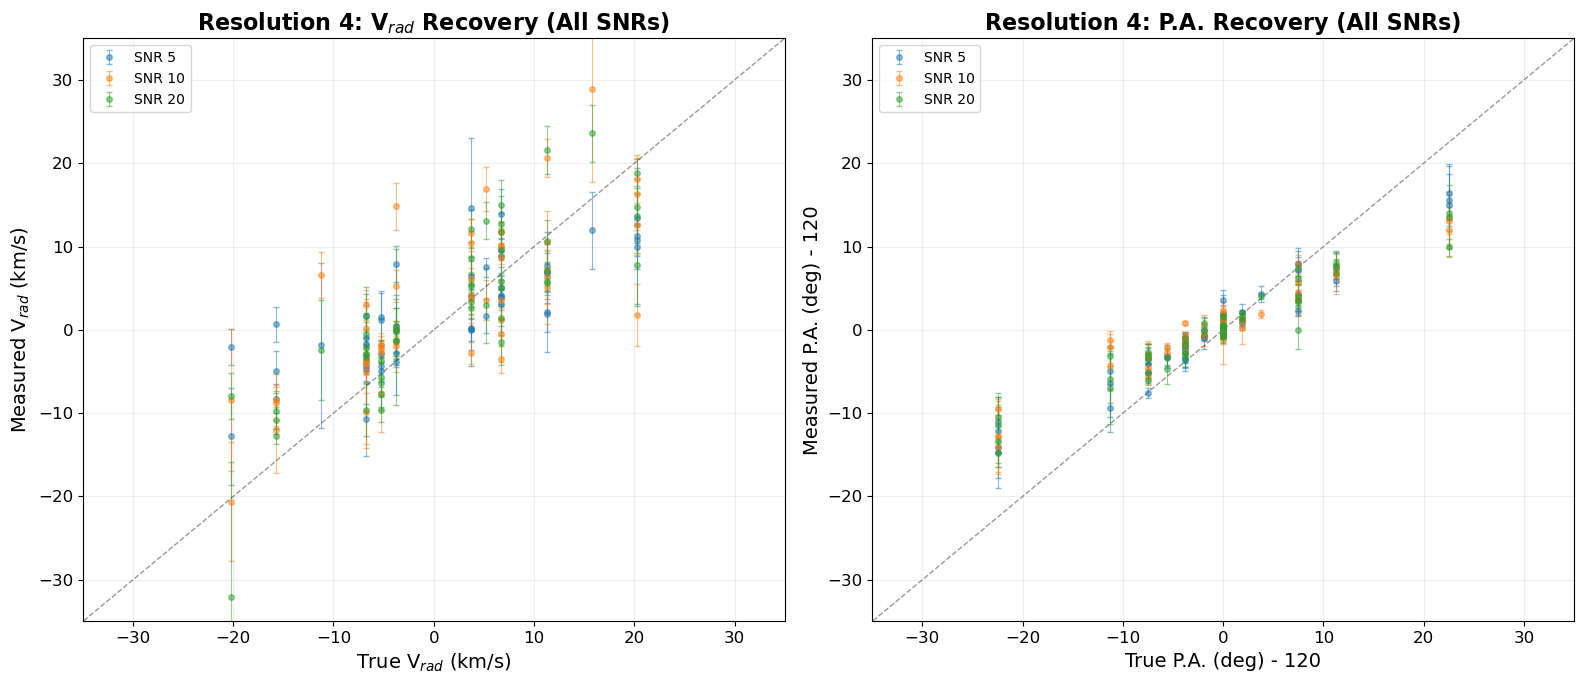

In [57]:
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ==========================================
# 1. 路径与全局配置
# ==========================================
TRUE_DIR = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/snr_res_testing/new_res_output"
OTHER_RES_BASE = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/snr_res_testing/new_res_260128/"

# 匹配所有 Res4 的文件夹，并捕获 SNR 数值
pat_folder = re.compile(r"^(?P<base>.*)_Res4_SNR(?P<snr>\d+)$")

plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "legend.fontsize": 10
})

# 区分不同 SNR 的颜色
SNR_COLORS = {5: "#1f77b4", 10: "#ff7f0e", 20: "#2ca02c"}

# ==========================================
# 2. 批量加载 Res4 所有数据
# ==========================================
def load_all_res4_data():
    all_data = []
    # 匹配所有包含 _Res4_ 的文件夹
    folders = glob.glob(os.path.join(OTHER_RES_BASE, "*_Res4_SNR*"))
    
    for folder in folders:
        fname = os.path.basename(folder)
        match = pat_folder.match(fname)
        if not match: continue
        
        snr_val = int(match.group("snr"))
        base_name = match.group("base")
        
        # 文件路径定位
        meas_path = os.path.join(folder, "second_step_check_sinw", "rings_final2.txt")
        err_path  = os.path.join(folder, "bootstrap_error.txt")
        true_path = os.path.join(TRUE_DIR, f"{base_name}_Res4.txt")
        
        if all(os.path.exists(p) for p in [meas_path, err_path, true_path]):
            df_t = pd.read_csv(true_path, sep='\s+')
            df_m = pd.read_csv(meas_path, sep='\s+')
            df_e = pd.read_csv(err_path,  sep='\s+')
            
            n = min(len(df_t), len(df_m), len(df_e))
            df = pd.DataFrame({
                "True_VRAD": df_t["VRAD(km/s)"].values[:n],
                "Meas_VRAD": df_m["VRAD(km/s)"].values[:n],
                "Err_VRAD":  df_e["VRADerror(km/s)"].values[:n],
                "True_PA":   df_t["P.A.(deg)"].values[:n],
                "Meas_PA":   df_m["P.A.(deg)"].values[:n],
                "Err_PA":    df_e["P.A.error(deg)"].values[:n],
                "SNR":       snr_val
            })
            all_data.append(df)
            
    return pd.concat(all_data, ignore_index=True) if all_data else pd.DataFrame()

# ==========================================
# 3. 绘图执行 (1x2 布局: VRAD & PA)
# ==========================================
df_all = load_all_res4_data()

if df_all.empty:
    print("未发现匹配的 Res4 数据，请检查路径。")
else:
    # 过滤真值为 0 的无效点
    df_all = df_all[df_all["True_VRAD"] != 0]
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    titles = ["V$_{rad}$ Recovery", "P.A. Recovery"]
    labels = ["V$_{rad}$ (km/s)", "P.A. (deg) - 120"]

    for i, mode in enumerate(["VRAD", "PA"]):
        ax = axes[i]
        for snr, color in SNR_COLORS.items():
            sub = df_all[df_all["SNR"] == snr]
            if sub.empty: continue
            
            if mode == "VRAD":
                x, y, err = sub["True_VRAD"], sub["Meas_VRAD"], sub["Err_VRAD"]
            else:
                x, y, err = sub["True_PA"] - 120, sub["Meas_PA"] - 120, sub["Err_PA"]

            # 绘制误差棒
            ax.errorbar(x, y, yerr=err, fmt='o', ms=4, color=color, 
                        ecolor=color, elinewidth=0.8, capsize=2, alpha=0.5, 
                        label=f"SNR {snr}")

        # 辅助线与美化
        ax.plot([-40, 40], [-40, 40], "k--", alpha=0.4, lw=1)
        ax.set_xlim(-35, 35)
        ax.set_ylim(-35, 35)
        ax.set_title(f"Resolution 4: {titles[i]} (All SNRs)", fontweight="bold")
        ax.set_xlabel(f"True {labels[i]}")
        ax.set_ylabel(f"Measured {labels[i]}")
        ax.grid(True, alpha=0.2)
        ax.legend()

    plt.tight_layout()
    plt.savefig("Res4_AllSNRs_Errors.png", dpi=300)
    plt.show()

[-23.49 -18.27 -13.05  -7.83  -2.61   2.61   7.83  13.05  18.27  23.49] [ 0.886   2.401   0.934   1.312   0.173   1.045   0.113  -0.074  -0.3515
 -1.458 ]
[-23.49 -18.27 -13.05  -7.83  -2.61   2.61   7.83  13.05  18.27  23.49] [ 1.0845  0.779   0.518   0.48   -0.4985  1.348   0.478   0.3305  0.394
 -0.9675]
[-23.49 -18.27 -13.05  -7.83  -2.61   2.61   7.83  13.05  18.27  23.49] [ 0.9555  0.567   0.3395 -0.1575 -0.791   1.269   0.3035  0.122   0.9535
 -1.2005]
[-26.1 -20.3 -14.5  -8.7  -2.9   2.9   8.7  14.5  20.3  26.1] [ 0.612   2.0925  1.527   1.642   0.2995  0.088  -0.372  -0.7715 -1.311
 -0.547 ]
[-26.1 -20.3 -14.5  -8.7  -2.9   2.9   8.7  14.5  20.3  26.1] [ 1.039   2.209   1.39    1.634   0.216   0.0825 -0.501  -0.91   -1.535
 -0.885 ]
[-26.1 -20.3 -14.5  -8.7  -2.9   2.9   8.7  14.5  20.3  26.1] [ 1.733   2.292   1.647   1.5725  0.196  -0.104  -0.706  -0.854  -1.651
 -1.439 ]
[-23.49 -18.27 -13.05  -7.83  -2.61   2.61   7.83  13.05  18.27  23.49] [ 0.152  -0.269   0.0365  0.1845

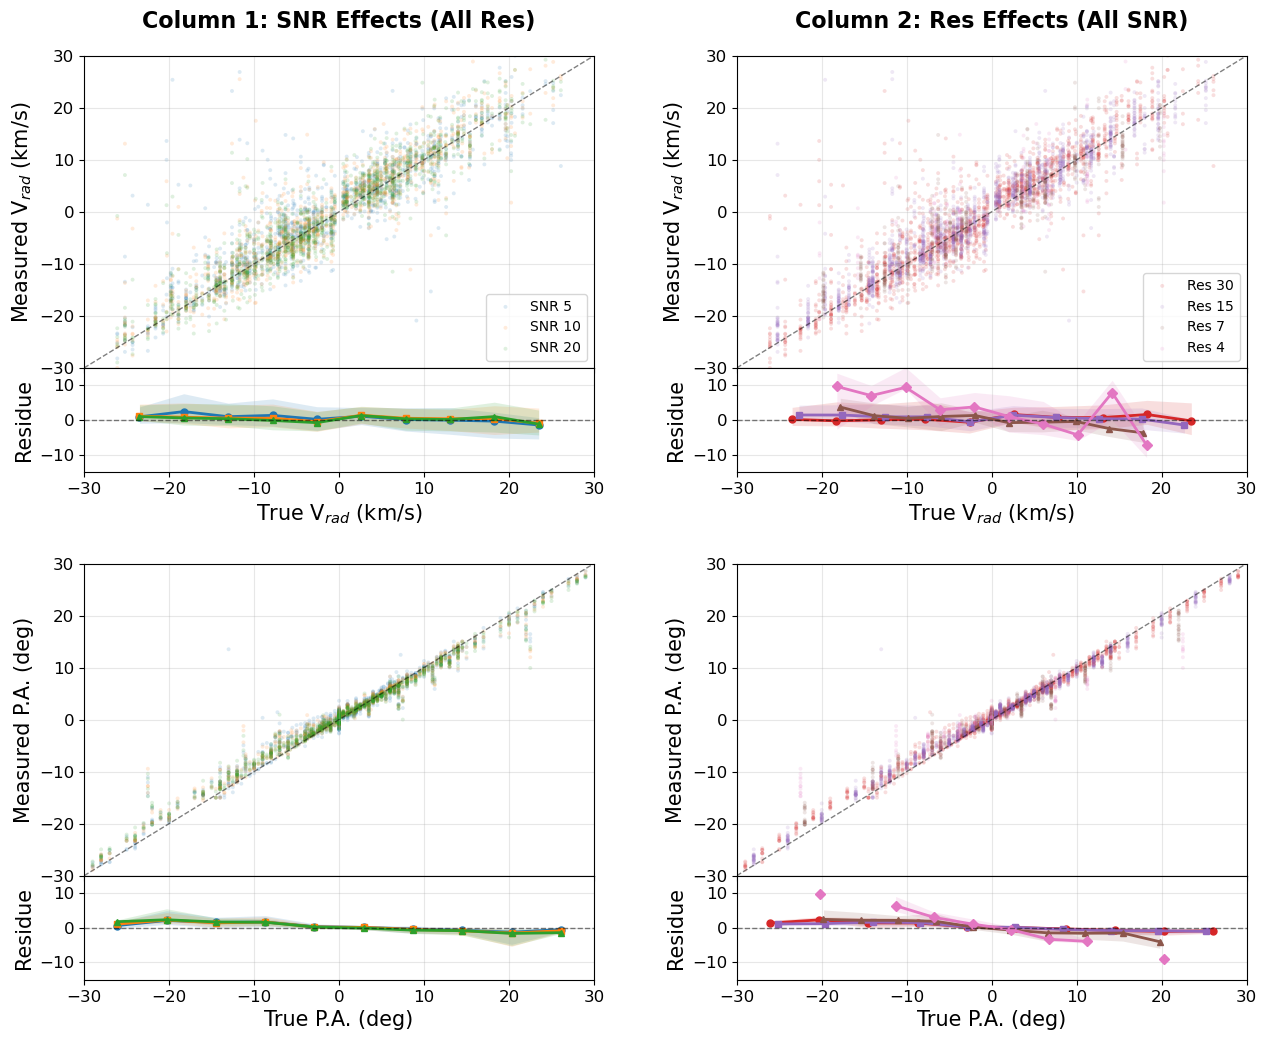

In [40]:
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ==========================================
# 1. 路径与全局配置
# ==========================================
TRUE_DIR = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/snr_res_testing/new_res_output"
RES30_BASE = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/snr_res_testing/"
OTHER_RES_BASE = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/snr_res_testing/new_res_260128/"

plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 15,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

# 样式配置
SNR_STYLES = {
    5:  dict(color="#1f77b4", marker="o", label="SNR 5"),
    10: dict(color="#ff7f0e", marker="s", label="SNR 10"),
    20: dict(color="#2ca02c", marker="^", label="SNR 20"),
}

RES_STYLES = {
    30: dict(color="#d62728", marker="o", label="Res 30"),
    15: dict(color="#9467bd", marker="s", label="Res 15"),
    7:  dict(color="#8c564b", marker="^", label="Res 7"),
    4:  dict(color="#e377c2", marker="D", label="Res 4"),
}

pat_fname = re.compile(
    r"^(?:\d+_)?ring_v(?P<v>\d+)_R(?P<R>\d+)_.*_INC(?P<inc>\d+)_Res(?P<res>\d+)\.txt$"
)

# ==========================================
# 2. 统计逻辑 (Median / 16 / 84)
# ==========================================
def load_all_combined_data():
    """加载所有目录下的所有数据，不进行 SNR 或 Res 的过滤"""
    df_list = []
    # 扫描两个主要数据目录
    for base_dir in [RES30_BASE, OTHER_RES_BASE]:
        files = sorted(glob.glob(os.path.join(base_dir, "*Res*.txt")))
        for fp in files:
            fname = os.path.basename(fp)
            m = pat_fname.match(fname)
            if not m: continue
            res_val = int(m.group("res"))
            
            true_path = os.path.join(TRUE_DIR, fname)
            if not os.path.exists(true_path): continue
            df_true = pd.read_csv(true_path, sep='\s+')
            
            for snr in [5, 10, 20]:
                folder = fname.replace(".txt", f"_SNR{snr}")
                out_path = os.path.join(base_dir, folder, "second_step_check_sinw", "rings_final2.txt")
                if not os.path.exists(out_path): continue
                
                df_out = pd.read_csv(out_path, sep='\s+')
                n = min(len(df_true), len(df_out))
                df = pd.DataFrame({
                    "True_VRAD": df_true["VRAD(km/s)"].values[:n],
                    "Measured_VRAD": df_out["VRAD(km/s)"].values[:n],
                    "True_PA": df_true["P.A.(deg)"].values[:n],
                    "Measured_PA": df_out["P.A.(deg)"].values[:n],
                    "SNR": snr, "Res": res_val
                })
                df = df[df["True_VRAD"] != 0].reset_index(drop=True)
                df_list.append(df)
    return pd.concat(df_list, ignore_index=True) if df_list else pd.DataFrame()

def bin_stats_median(x, y, label,nbins=10):
    if label== "Res 4":
        print(4)
        nbins=4
    df = pd.DataFrame({"x": x, "y": y, "res": y - x})
    if df.empty: return [], [], [], []
    bins = np.linspace(df["x"].min(), df["x"].max(), nbins + 1)
    df["bin"] = pd.cut(df["x"], bins=bins, include_lowest=True)
    g = df.groupby("bin", observed=False)["res"]
    return 0.5*(bins[:-1]+bins[1:]), g.median().values, g.quantile(0.16).values, g.quantile(0.84).values

def plot_panel(ax_sc, ax_rs, df, cat_col, style_dict, label, is_pa=False):
    for cat, style in style_dict.items():
        sub = df[df[cat_col] == cat]
        if sub.empty: continue
        xs = (sub["True_PA"] - 120) if is_pa else sub["True_VRAD"]
        ys = (sub["Measured_PA"] - 120) if is_pa else sub["Measured_VRAD"]
        
        ax_sc.scatter(xs, ys, s=8, alpha=0.15, edgecolor="none", color=style["color"], label=style["label"])
        xc, med, q16, q84 = bin_stats_median(xs, ys,label)
        print(xc, med)
        if len(xc) > 0:
            ax_rs.plot(xc, med, color=style["color"], lw=2, marker=style["marker"], ms=5)
            ax_rs.fill_between(xc, q16, q84, alpha=0.15, color=style["color"], lw=0)
    
    ax_sc.grid(True, which='both',  alpha=0.3)
    ax_rs.grid(True, which='both', alpha=0.3)
    ax_sc.plot([-30, 30], [-30, 30], "k--", alpha=0.5, lw=1)
    ax_sc.set_xlim(-30, 30); ax_sc.set_ylim(-30, 30)
    ax_sc.set_ylabel(f"Measured {label}")
    ax_sc.tick_params(labelbottom=False)
    ax_rs.axhline(0, ls="--", color="k", alpha=0.5, lw=1)
    ax_rs.set_ylim(-15, 15)
    ax_rs.set_xlabel(f"True {label}")
    ax_rs.set_ylabel("Residue")

# ==========================================
# 3. 绘图执行
# ==========================================
if __name__ == "__main__":
    # 加载全部混合数据
    full_df = load_all_combined_data()

    fig = plt.figure(figsize=(15, 12))
    outer_gs = gridspec.GridSpec(2, 2, hspace=0.22, wspace=0.28)

    # 两列逻辑：
    # Col 0: 混合所有 Res，只按 SNR 分组
    # Col 1: 混合所有 SNR，只按 Res 分组
    cols_info = [
        ("SNR", SNR_STYLES, "Column 1: SNR Effects (All Res)"),
        ("Res", RES_STYLES, "Column 2: Res Effects (All SNR)")
    ]

    for col_idx, (cat_field, styles, title) in enumerate(cols_info):
        for row_idx, (lab, is_pa) in enumerate([("V$_{rad}$ (km/s)", False), ("P.A. (deg)", True)]):
            inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_gs[row_idx, col_idx], 
                                                     height_ratios=[3, 1], hspace=0.0)
            ax_sc = fig.add_subplot(inner[0]); ax_rs = fig.add_subplot(inner[1], sharex=ax_sc)
            
            plot_panel(ax_sc, ax_rs, full_df, cat_field, styles, lab, is_pa)
            
            if row_idx == 0:
                ax_sc.set_title(title, fontsize=16, fontweight="bold", pad=20)
                ax_sc.legend(loc="lower right", fontsize=10,  frameon=True)

    plt.savefig("Analysis_SNR_Res_Unrestricted.pdf", bbox_inches='tight', dpi=300)
    plt.show()

In [45]:
# ==========================================
# 2. Updated Statistical Logic
# ==========================================
def bin_stats_median(x, y, cat_val, nbins=10):
    # Trigger 4 bins only when we are explicitly looking at Resolution 4
    if cat_val == 4:
        nbins = 6
    
    df = pd.DataFrame({"x": x, "y": y, "res": y - x})
    if df.empty: 
        return np.array([]), np.array([]), np.array([]), np.array([])
    
    # Define bin edges
    # Use fixed range -30 to 30 to match your plot limits for consistency
    bins = np.linspace(-30, 30, nbins + 1)
    
    # include_lowest=True is critical so the first data point isn't dropped
    df["bin"] = pd.cut(df["x"], bins=bins, include_lowest=True)
    
    # observed=False ensures that even empty bins return a NaN row, 
    # keeping the array length consistent with 'centers'
    g = df.groupby("bin", observed=False)["res"]
    
    centers = 0.5 * (bins[:-1] + bins[1:])
    return centers, g.median().values, g.quantile(0.16).values, g.quantile(0.84).values

def plot_panel(ax_sc, ax_rs, df, cat_col, style_dict, label, is_pa=False):
    for cat, style in style_dict.items():
        sub = df[df[cat_col] == cat]
        if sub.empty: continue
        
        xs = (sub["True_PA"] - 120) if is_pa else sub["True_VRAD"]
        ys = (sub["Measured_PA"] - 120) if is_pa else sub["Measured_VRAD"]
        
        # Scatter
        ax_sc.scatter(xs, ys, s=8, alpha=0.15, edgecolor="none", color=style["color"], label=style["label"])
        
        # Pass 'cat' (the SNR or Res value) to the stats function
        xc, med, q16, q84 = bin_stats_median(xs, ys, cat, nbins=10)
        
        if len(xc) > 0:
            # Clean up NaNs for plotting to avoid line breaks if a bin is empty
            mask = ~np.isnan(med)
            ax_rs.plot(xc[mask], med[mask], color=style["color"], lw=2, marker=style["marker"], ms=5)
            ax_rs.fill_between(xc[mask], q16[mask], q84[mask], alpha=0.15, color=style["color"], lw=0)
    
    # --- UI & Layout Improvements ---
    ax_sc.set_box_aspect(1)
    ax_rs.set_box_aspect(1/3)
    ax_sc.set_anchor('S')
    ax_rs.set_anchor('N')
    
    ax_sc.grid(True, which='both', alpha=0.3)
    ax_rs.grid(True, which='both', alpha=0.3)
    ax_sc.plot([-30, 30], [-30, 30], "k--", alpha=0.5, lw=1)
    ax_sc.set_xlim(-30, 30); ax_sc.set_ylim(-30, 30)
    ax_sc.set_ylabel(f"Recovered {label}")
    ax_sc.tick_params(labelbottom=False)
    ax_rs.axhline(0, ls="--", color="k", alpha=0.5, lw=1)
    ax_rs.set_ylim(-15, 15)
    ax_rs.set_xlabel(f"True {label}")
    ax_rs.set_ylabel("Residuals")

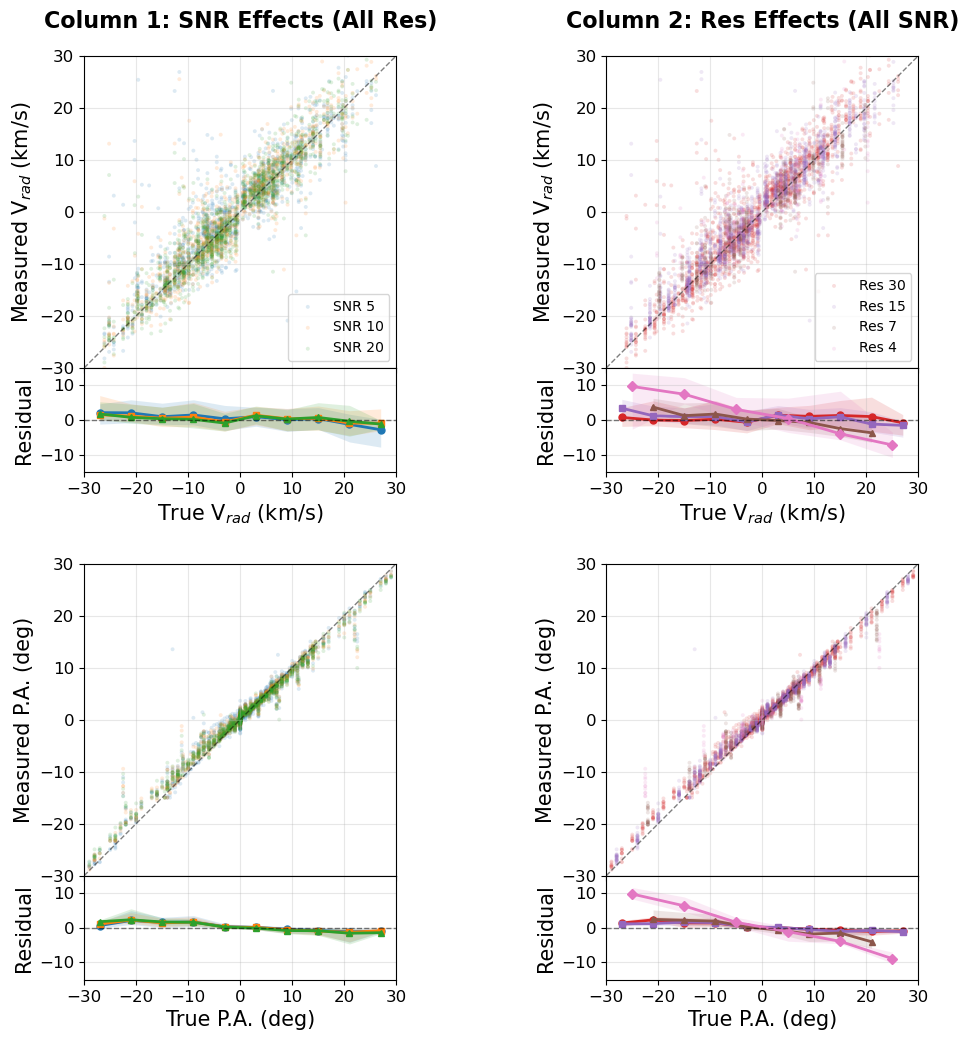

In [48]:
if __name__ == "__main__":
    # 加载全部混合数据
    full_df = load_all_combined_data()

    fig = plt.figure(figsize=(12, 12))
    outer_gs = gridspec.GridSpec(2, 2, hspace=0.22, wspace=0.28)

    # 两列逻辑：
    # Col 0: 混合所有 Res，只按 SNR 分组
    # Col 1: 混合所有 SNR，只按 Res 分组
    cols_info = [
        ("SNR", SNR_STYLES, "Column 1: SNR Effects (All Res)"),
        ("Res", RES_STYLES, "Column 2: Res Effects (All SNR)")
    ]

    for col_idx, (cat_field, styles, title) in enumerate(cols_info):
        for row_idx, (lab, is_pa) in enumerate([("V$_{rad}$ (km/s)", False), ("P.A. (deg)", True)]):
            inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_gs[row_idx, col_idx], 
                                                     height_ratios=[3, 1], hspace=0.0)
            ax_sc = fig.add_subplot(inner[0]); ax_rs = fig.add_subplot(inner[1], sharex=ax_sc)
            
            plot_panel(ax_sc, ax_rs, full_df, cat_field, styles, lab, is_pa)
            
            if row_idx == 0:
                ax_sc.set_title(title, fontsize=16, fontweight="bold", pad=20)
                ax_sc.legend(loc="lower right", fontsize=10,  frameon=True)

    plt.savefig("Analysis_SNR_Res_Unrestricted.pdf", bbox_inches='tight', dpi=300)
    plt.show()

Loading data...
Total points: 4184


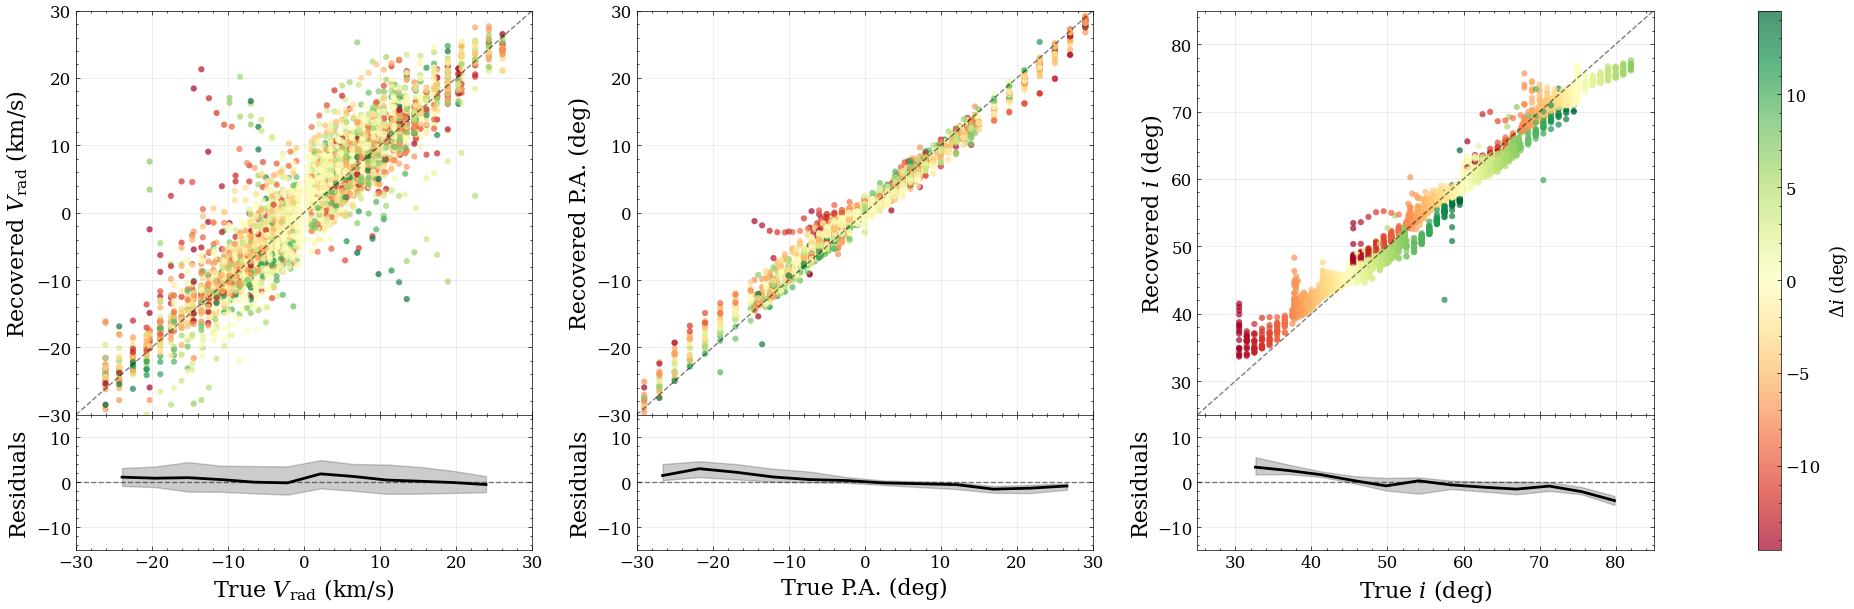

In [16]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm

# ==========================================
# 1. PATH CONFIG
# ==========================================
plt.style.use("/net/dataserver3/data/users/linn/pic_style/science3.mplstyle")
RING_MODEL_DIR = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/varied_inc/"
INITIAL_DIR    = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/varied_inc/initial/"

# ==========================================
# 2. FILENAME PARSER
# ==========================================
pat_fname = re.compile(
    r"^(?:\d+_)?ring_"
    r"v(?P<v>\d+)_R(?P<R>\d+)_"
    r"(?:(?:PAfixed)|PAk(?P<pa_k>-?\d*\.?\d+)_TP(?P<pa_tp>-?\d*\.?\d+))_"
    r"VR(?:(?:k(?P<vr_k>-?\d*\.?\d+)_TP(?P<vr_tp>-?\d*\.?\d+))|(?P<vr_fixed>0))_"
    r"INC(?P<inc>\d+)(?:k(?P<inc_k>-?\d*\.?\d+)_TP(?P<inc_tp>-?\d*\.?\d+))?"
    r"(?:_Res\d+)?"
)

# ==========================================
# 3. DATA LOADING
# ==========================================
def load_single_file(fname):
    m = pat_fname.match(fname)
    if not m: return None
    g = m.groupdict()

    inc_base = int(g["inc"]) if g.get("inc") else None
    inc_k    = float(g["inc_k"]) if g.get("inc_k") else 0.0
    inc_tp   = float(g["inc_tp"]) if g.get("inc_tp") else 0.0

    if inc_base == 75 and inc_k < 0:
        if not (np.isclose(inc_k, -0.05) and np.isclose(inc_tp, 450.0)):
            return None

    in_path = os.path.join(INITIAL_DIR, fname)
    if not os.path.exists(in_path): return None

    base, _ = os.path.splitext(fname)
    out_path = os.path.join(RING_MODEL_DIR, base + "_SNR10", "second_step_check_sinw", "rings_final2.txt")
    if not os.path.exists(out_path): return None

    # 使用 sep='\s+' 代替 delim_whitespace
    df_in  = pd.read_csv(in_path, sep='\s+')
    df_out = pd.read_csv(out_path, sep='\s+')

    n = min(len(df_in), len(df_out))
    delta_inc = df_in["INC(deg)"][:n].values - inc_base

    df = pd.DataFrame({
        "Filename": fname,
        "True_VRAD": df_in["VRAD(km/s)"][:n].values,
        "Measured_VRAD": df_out["VRAD(km/s)"][:n].values,
        "True_PA": df_in["P.A.(deg)"][:n].values,
        "Measured_PA": df_out["P.A.(deg)"][:n].values,
        "True_INC": df_in["INC(deg)"][:n].values,
        "Measured_INC": df_out["INC(deg)"][:n].values,
        "Delta_INC": delta_inc,
    })
    return df[df["True_VRAD"] != 0].reset_index(drop=True)

def load_all_data():
    dfs = []
    for fp in sorted(glob.glob(os.path.join(INITIAL_DIR, "*.txt"))):
        fname = os.path.basename(fp)
        if "v200" not in fname: continue
        df = load_single_file(fname)
        if df is not None: dfs.append(df)
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

# ==========================================
# 4. BIN STATS (Using Median and 16/84 Percentiles)
# ==========================================
def bin_stats(x, y, nbins=12):
    df = pd.DataFrame({"x": x, "y": y})
    df["res"] = df["y"] - df["x"]
    bins = np.linspace(df["x"].min(), df["x"].max(), nbins + 1)
    df["bin"] = pd.cut(df["x"], bins=bins, include_lowest=True)
    
    g = df.groupby("bin", observed=False)["res"]
    
    xc = 0.5 * (bins[:-1] + bins[1:])
    # 计算中位数, 16% 分位数 和 84% 分位数
    median = g.median().values
    low = g.quantile(0.16).values
    high = g.quantile(0.84).values
    
    return xc, median, low, high

# ==========================================
# 5. PANEL PLOTTER
# ==========================================
def plot_panel(ax_sc, ax_rs, df, xcol, ycol, label, is_pa, cmap, norm, is_inc=False):
    x = df[xcol] - 120 if is_pa else df[xcol]
    y = df[ycol] - 120 if is_pa else df[ycol]

    sc = ax_sc.scatter(x, y, c=df["Delta_INC"], cmap=cmap, norm=norm, s=20, alpha=0.7, edgecolor="none")

    # 获取分位数统计结果
    xc, mid, low, high = bin_stats(x, y)
    
    # 绘制中位数线和 16-84 填充区域
    ax_rs.plot(xc, mid, color="k", lw=2, label="Median")
    ax_rs.fill_between(xc, low, high, color="k", alpha=0.2, label="16th-84th Pctl")

    if is_inc:
        ax_sc.set_xlim(25, 85); ax_sc.set_ylim(25, 85)
        ax_sc.plot([25, 85], [25, 85], "k--", lw=1, alpha=0.5)
    else:
        ax_sc.set_xlim(-30, 30); ax_sc.set_ylim(-30, 30)
        ax_sc.plot([-30, 30], [-30, 30], "k--", lw=1, alpha=0.5)

    ax_sc.grid(alpha=0.3); ax_sc.set_ylabel(f"Recovered {label}")
    ax_sc.tick_params(labelbottom=False)
    
    ax_rs.set_ylim(-15, 15); ax_rs.axhline(0, ls="--", color="k", alpha=0.5)
    ax_rs.grid(alpha=0.3); ax_rs.set_xlabel(f"True {label}"); ax_rs.set_ylabel("Residuals")
    return sc

# ==========================================
# 6. 1×3 ROW FIGURE
# ==========================================
def plot_one_row_all(df_all, title):
    dmax = np.max(np.abs(df_all["Delta_INC"]))
    norm = TwoSlopeNorm(vmin=-dmax, vcenter=0.0, vmax=dmax)
    cmap = plt.get_cmap("RdYlGn")

    fig = plt.figure(figsize=(22, 7))
    fig.suptitle(title, fontsize=16, y=1.02)

    # 1行 4列: Vrad, PA, Inc, Colorbar
    outer = gridspec.GridSpec(1, 4, width_ratios=[1, 1, 1, 0.05], wspace=0.3)

    rows = [
        ("True_VRAD", "Measured_VRAD", r"$V_{\rm rad}$ (km/s)", False, False),
        ("True_PA",   "Measured_PA",  "P.A. (deg)",        True,  False),
        ("True_INC",  "Measured_INC", "$i$ (deg)",         False, True),
    ]

    mappable = None
    for i, (xcol, ycol, label, is_pa, is_inc) in enumerate(rows):
        inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[0, i], height_ratios=[3, 1], hspace=0)
        ax_sc = fig.add_subplot(inner[0])
        ax_rs = fig.add_subplot(inner[1], sharex=ax_sc)

        mappable = plot_panel(ax_sc, ax_rs, df_all, xcol, ycol, label, is_pa, cmap, norm, is_inc=is_inc)
        #ax_sc.set_title(f"{label.split()[0]}", fontsize=14, fontweight="bold")

    if mappable is not None:
        cax = fig.add_subplot(outer[0, 3])
        plt.colorbar(mappable, cax=cax).set_label(r"$\Delta i$ (deg)", fontsize=13)

    plt.savefig("figure_varied_inc_vrad_pa_inc_row_median.pdf", bbox_inches='tight')
    plt.show()

# ==========================================
# 7. MAIN
# ==========================================
if __name__ == "__main__":
    print("Loading data...")
    df_all = load_all_data()
    if not df_all.empty:
        print(f"Total points: {len(df_all)}")
        plot_one_row_all(df_all, "")
    else:
        print("Data empty.")

/tmp/ipykernel_681708/880413249.py:118: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat(df_list, ignore_index=True) if df_list else pd.DataFrame()


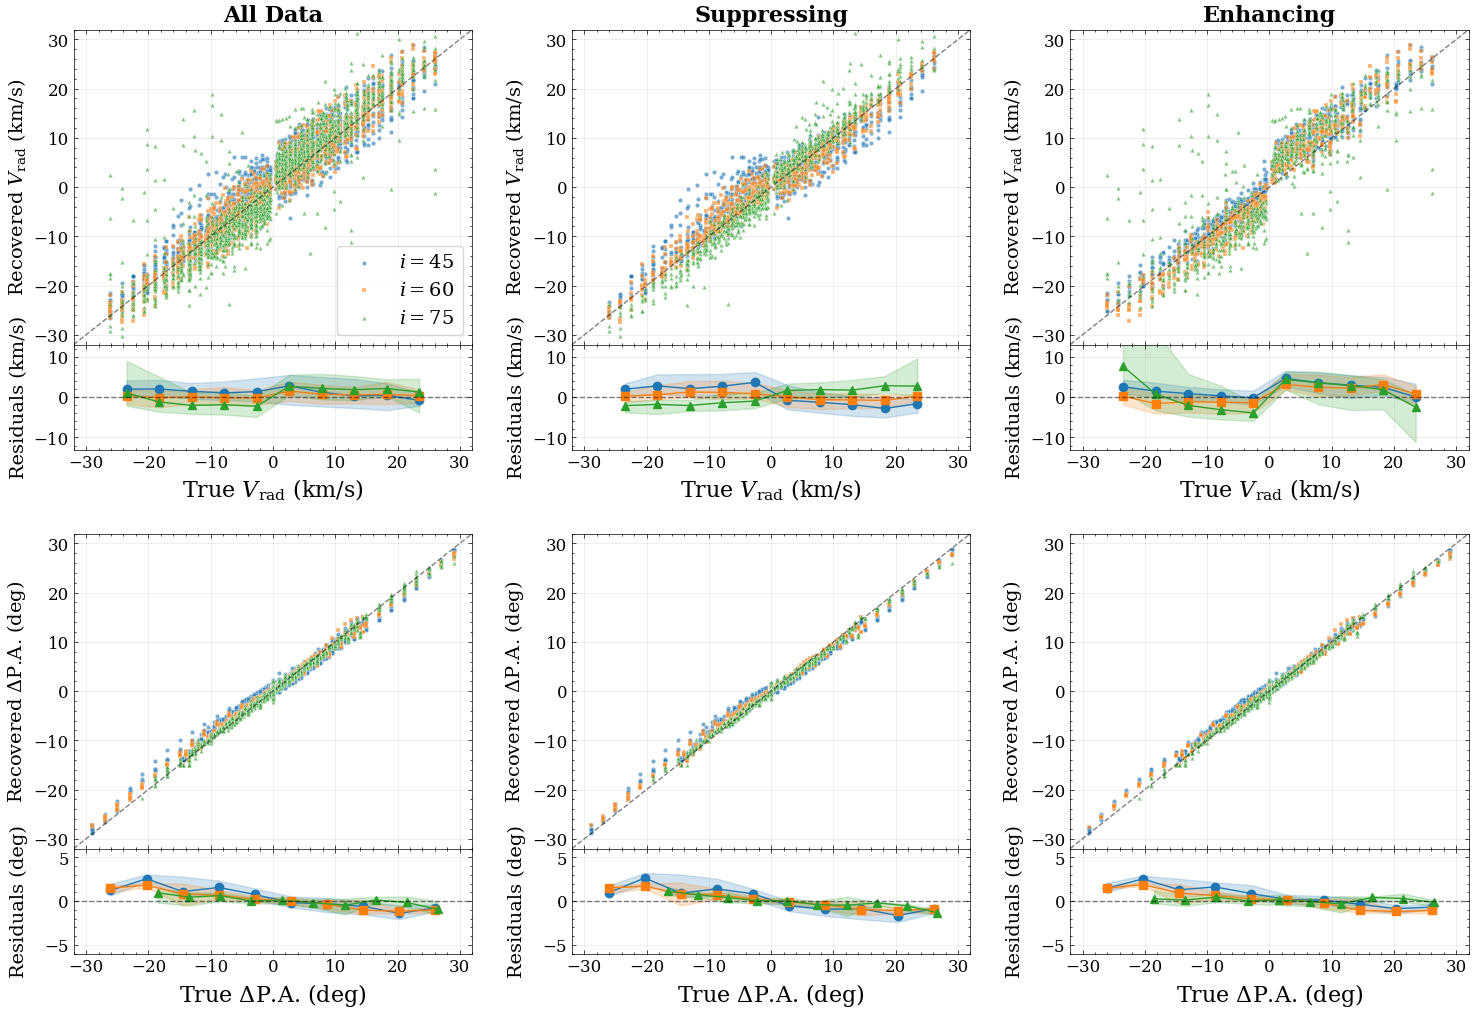

In [19]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 13,
})

plt.style.use("/net/dataserver3/data/users/linn/pic_style/science3.mplstyle")
# ==========================================
# 1. 配置与路径 (CONFIG)
# ==========================================
RING_BASE      = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/"
RING_MODEL1123 = RING_BASE + "model1123/"

INITIAL_BASE   = "/net/dataserver3/data/users/linn/para_initial/test_more_model/"
INITIAL_1123   = "/net/dataserver3/data/users/linn/para_initial/test_more_model/model1123/"

# 绘图样式配置
INC_STYLES = {
    45: dict(color="#1f77b4", marker="o", label="$i=45$"),
    60: dict(color="#ff7f0e", marker="s", label="$i=60$"),
    75: dict(color="#2ca02c", marker="^", label="$i=75$"),
}

# ==========================================
# 2. 文件名解析与辅助函数
# ==========================================
pat_fname = re.compile(
    r"^(?:\d+_)?ring_"
    r"v(?P<v>\d+)_R(?P<R>\d+)_"
    r"(?:(?:PAfixed)|PAk(?P<pa_k>-?\d*\.?\d+)_TP(?P<pa_tp>\d+))_"
    r"VR(?:(?:k(?P<vr_k>-?\d*\.?\d+)_TP(?P<vr_tp>\d+))|(?P<vr_fixed>0))_"
    r"INC(?P<inc>\d+)"
)

def compute_sign(pa_k, vr_k):
    if pa_k is None: return 0
    if vr_k is None: return 0
    if vr_k == 0: return 0
    return 1 if pa_k * vr_k > 0 else -1

# ==========================================
# 3. 数据加载函数 (DATA LOADING)
# ==========================================
def load_single_file(file_name, ring_root):
    m = pat_fname.match(file_name)
    if not m: return None

    g = m.groupdict()
    pa_k = float(g["pa_k"]) if g.get("pa_k") else None
    vr_k = float(g["vr_k"]) if g.get("vr_k") else None
    inc_val = int(g["inc"])

    if "model1123" in ring_root:
        in_path = os.path.join(INITIAL_1123, file_name)
    else:
        in_path = os.path.join(INITIAL_BASE, file_name)

    if not os.path.exists(in_path): return None

    try: inputf = pd.read_csv(in_path, delimiter=r"\s+")
    except: return None

    base_name, _ = os.path.splitext(file_name)
    out_path = os.path.join(ring_root, base_name, "second_step_check_sinw", "rings_final2.txt")
    if not os.path.exists(out_path): return None

    try: outputf = pd.read_csv(out_path, delimiter=r"\s+")
    except: return None

    n = min(len(inputf), len(outputf))
    df = pd.DataFrame({
        "True_VRAD": inputf["VRAD(km/s)"][:n].values,
        "Measured_VRAD": outputf["VRAD(km/s)"][:n].values,
        "True_PA": inputf["P.A.(deg)"][:n].values,
        "Measured_PA": outputf["P.A.(deg)"][:n].values,
        "INC": inc_val,
        "pa_k": pa_k,
        "vr_k": vr_k,
        "sign": compute_sign(pa_k, vr_k),
        "file": file_name
    })
    
    df = df[df["True_VRAD"] != 0].reset_index(drop=True)
    return df

def load_all_data():
    df_list = []
    files_1123 = sorted(glob.glob(os.path.join(RING_MODEL1123, "*.txt")))
    for fp in files_1123:
        fname = os.path.basename(fp)
        if "v200" not in fname: continue
        if "INC45" in fname or "INC75" in fname or "INC60" in fname:
            df = load_single_file(fname, RING_MODEL1123)
            if df is not None: df_list.append(df)

    files_base = sorted(glob.glob(os.path.join(RING_BASE, "*.txt")))
    for fp in files_base:
        fname = os.path.basename(fp)
        if "v200" not in fname: continue
        if "INC60" in fname:
            df = load_single_file(fname, RING_BASE)
            if df is not None: df_list.append(df)

    return pd.concat(df_list, ignore_index=True) if df_list else pd.DataFrame()

# ==========================================
# 4. 绘图与统计函数 (PLOTTING) - 已更新为 Median/16%/84%
# ==========================================
def bin_stats(x_plot, y_plot, nbins=10):
    """
    计算残差的中位数 (Median) 和 16%/84% 分位数 (取代 Mean/Sigma)
    """
    temp_df = pd.DataFrame({'x': np.array(x_plot), 'y': np.array(y_plot)})
    temp_df['res'] = temp_df['y'] - temp_df['x']

    if temp_df['x'].empty:
        return [], [], [], []
        
    bin_edges = np.linspace(temp_df['x'].min(), temp_df['x'].max(), nbins + 1)
    temp_df['bin_cat'] = pd.cut(temp_df['x'], bins=bin_edges, include_lowest=True)

    grouped = temp_df.groupby('bin_cat', observed=False)['res']
    
    # 获取统计量
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    median_res = grouped.median().values
    q16_res = grouped.quantile(0.16).values
    q84_res = grouped.quantile(0.84).values

    return bin_centers, median_res, q16_res, q84_res

def plot_combined_panel(ax_scatter, ax_resid, x, y, inc_col, label_prefix, is_pa=False, show_legend=False):
    if x.empty or y.empty: return

    for inc, style in INC_STYLES.items():
        sub = inc_col[inc_col == inc].index
        if len(sub) == 0: continue
        
        x_sub, y_sub = x.loc[sub], y.loc[sub]
        x_plot, y_plot = (x_sub - 120, y_sub - 120) if is_pa else (x_sub, y_sub)
            
        # --- Scatter ---
        ax_scatter.scatter(x_plot, y_plot, s=10, alpha=0.6, edgecolor="white", linewidth=0.3, **style,rasterized=True)
        
        # --- Residual (Median + 16/84% Area) ---
        bin_centers, med, q16, q84 = bin_stats(x_plot, y_plot)
        if len(bin_centers) > 0:
            ax_resid.plot(bin_centers, med, **style)
            fill_style = {k: v for k, v in style.items() if k not in ['marker', 'label']}
            ax_resid.fill_between(bin_centers, q16, q84, alpha=0.2, **fill_style)

    # Decorate
    ax_scatter.set_xlim(-32, 32); ax_scatter.set_ylim(-32, 32)
    ax_scatter.plot([-32, 32], [-32, 32], "k--", lw=1, alpha=0.5)
    ax_scatter.grid(True, alpha=0.3); ax_scatter.set_ylabel(f"Recovered {label_prefix}",fontsize=14)
    ax_scatter.tick_params(labelbottom=False)
    if show_legend: ax_scatter.legend(loc='lower right', fontsize=14, frameon=True)

    if is_pa:
        ax_resid.set_ylim(-6, 6)
    else:
        ax_resid.set_ylim(-13, 13)
    ax_resid.axhline(0, color='k', linestyle='--', lw=1, alpha=0.5)
    ax_resid.grid(True, alpha=0.3); ax_resid.set_xlabel(f"True {label_prefix}"); 
    if is_pa:
        ax_resid.set_ylabel("Residuals (deg)",fontsize=14,labelpad=12)
    else:
        ax_resid.set_ylabel("Residuals (km/s)",fontsize=14)
def plot_six_panel_figure(df_all, df_supp, df_enh):
    fig = plt.figure(figsize=(18, 12))
    outer_grid = gridspec.GridSpec(2, 3, height_ratios=[1, 1], hspace=0.2, wspace=0.25)
    datasets = [("All Data", df_all), ("Suppressing", df_supp), ("Enhancing", df_enh)]

    for row_idx, (lab, is_pa) in enumerate([(r"$V_{\rm rad}$ (km/s)", False), ("$\Delta$P.A. (deg)", True)]):
        for col_idx, (name, df) in enumerate(datasets):
            inner_grid = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_grid[row_idx, col_idx], height_ratios=[3, 1], hspace=0.0)
            ax_sc = fig.add_subplot(inner_grid[0])
            ax_rs = fig.add_subplot(inner_grid[1], sharex=ax_sc)
            
            plot_combined_panel(ax_sc, ax_rs, df["True_PA" if is_pa else "True_VRAD"], 
                                df["Measured_PA" if is_pa else "Measured_VRAD"], 
                                df["INC"], label_prefix=lab, is_pa=is_pa, show_legend=(col_idx == 0 and row_idx == 0))
            if not is_pa:
                ax_sc.set_title(f"{name}", fontsize=16, fontweight='bold')

    plt.savefig("figure3-incforincfixedgalaxies_6.pdf",dpi=300)
    plt.show()

if __name__ == "__main__":
    df_all = load_all_data()
    if not df_all.empty:
        df_supp = df_all[df_all["sign"] > 0].reset_index(drop=True)
        df_enh  = df_all[df_all["sign"] < 0].reset_index(drop=True)
        plot_six_panel_figure(df_all, df_supp, df_enh)
        


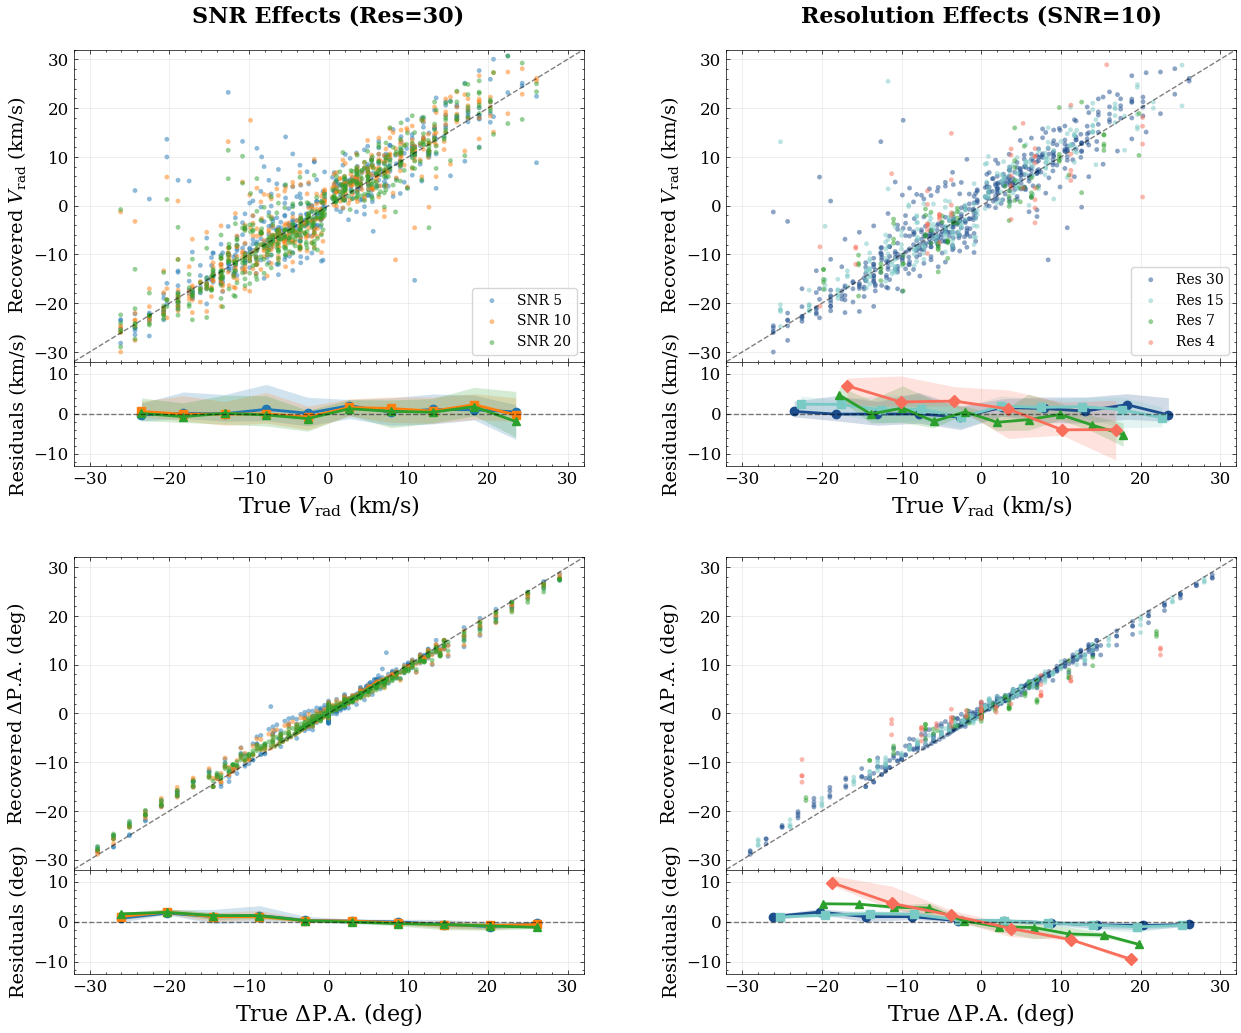

In [15]:
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ==========================================
# 1. 路径与全局配置
# ==========================================
TRUE_DIR = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/snr_res_testing/new_res_output"
RES30_BASE = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/snr_res_testing/"
OTHER_RES_BASE = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/snr_res_testing/new_res_260128/"

# plt.rcParams.update({
#     "font.size": 12,
#     "axes.labelsize": 12,
#     "xtick.labelsize": 12,
#     "ytick.labelsize": 12,
# })
plt.style.use("/net/dataserver3/data/users/linn/pic_style/science3.mplstyle")
# 样式配置：使用你要求的配色风格
SNR_STYLES = {
    5:  dict(color="#1f77b4", marker="o", label="SNR 5"),
    10: dict(color="#ff7f0e", marker="s", label="SNR 10"),
    20: dict(color="#2ca02c", marker="^", label="SNR 20"),
}

RES_STYLES = {
    30: dict(color="#1C4D8D", marker="o", label="Res 30"),
    15: dict(color="#79C9C5", marker="s", label="Res 15"),
    7:  dict(color="#2ca02c", marker="^", label="Res 7"),
    4:  dict(color="#F96E5B", marker="D", label="Res 4"),
}

pat_fname = re.compile(
    r"^(?:\d+_)?ring_v(?P<v>\d+)_R(?P<R>\d+)_.*_INC(?P<inc>\d+)_Res(?P<res>\d+)\.txt$"
)

# ==========================================
# 2. 数据处理与统计函数 (Median / 16% / 84%)
# ==========================================
def load_data(base_dir, target_res=None, target_snr=None):
    df_list = []
    files = sorted(glob.glob(os.path.join(base_dir, "*Res*.txt")))
    for fp in files:
        fname = os.path.basename(fp)
        m = pat_fname.match(fname)
        if not m: continue
        res_val = int(m.group("res"))
        if target_res is not None and res_val != target_res: continue
        
        true_path = os.path.join(TRUE_DIR, fname)
        if not os.path.exists(true_path): continue
        df_true = pd.read_csv(true_path, sep='\s+')
        
        snrs = [5, 10, 20] if target_snr is None else [target_snr]
        for snr in snrs:
            folder = fname.replace(".txt", f"_SNR{snr}")
            out_path = os.path.join(base_dir, folder, "second_step_check_sinw", "rings_final2.txt")
            if not os.path.exists(out_path): continue
            
            df_out = pd.read_csv(out_path, sep='\s+')
            n = min(len(df_true), len(df_out))
            df = pd.DataFrame({
                "True_VRAD": df_true["VRAD(km/s)"].values[:n],
                "Measured_VRAD": df_out["VRAD(km/s)"].values[:n],
                "True_PA": df_true["P.A.(deg)"].values[:n],
                "Measured_PA": df_out["P.A.(deg)"].values[:n],
                "SNR": snr, "Res": res_val
            })
            df = df[df["True_VRAD"] != 0].reset_index(drop=True)
            df_list.append(df)
    return pd.concat(df_list, ignore_index=True) if df_list else pd.DataFrame()

def bin_stats_median(x, y, cat_val,nbins=10):
    if cat_val == 4:
        nbins = 6
    """计算中位数和 16/84 分位数"""
    df = pd.DataFrame({"x": x, "y": y, "res": y - x})
    if df.empty: return [], [], [], []
    
    bins = np.linspace(df["x"].min(), df["x"].max(), nbins + 1)
    df["bin"] = pd.cut(df["x"], bins=bins, include_lowest=True)
    g = df.groupby("bin", observed=False)["res"]
    
    xc = 0.5 * (bins[:-1] + bins[1:])
    median = g.median().values
    q16 = g.quantile(0.16).values
    q84 = g.quantile(0.84).values
    return xc, median, q16, q84

def plot_panel(ax_sc, ax_rs, df, cat_col, style_dict, label, is_pa=False):
    for cat, style in style_dict.items():
        sub = df[df[cat_col] == cat]
        if sub.empty: continue
        
        xs = (sub["True_PA"] - 120) if is_pa else sub["True_VRAD"]
        ys = (sub["Measured_PA"] - 120) if is_pa else sub["Measured_VRAD"]
        
        # Scatter
        ax_sc.scatter(xs, ys, s=12, alpha=0.5, edgecolor="none", color=style["color"],label=style["label"],rasterized=True)
        
        # Stats: Median + 16/84% area
        xc, med, q16, q84 = bin_stats_median(xs, ys,cat)
        if len(xc) > 0:
            ax_rs.plot(xc, med, color=style["color"], lw=2, marker=style["marker"], ms=6, )
            ax_rs.fill_between(xc, q16, q84, alpha=0.2, color=style["color"], lw=0)

    # Decorate
    ax_sc.plot([-32, 32], [-32, 32], "k--", alpha=0.5, lw=1)
    ax_sc.set_xlim(-32, 32); ax_sc.set_ylim(-32, 32)
    ax_sc.set_ylabel(f"Recovered {label}",fontsize=14)
    ax_sc.tick_params(labelbottom=False)
    ax_sc.grid(True, alpha=0.3)
    
    ax_rs.axhline(0, ls="--", color="k", alpha=0.5, lw=1)
    if is_pa:
        ax_rs.set_ylim(-13, 13)
    else:
        ax_rs.set_ylim(-13, 13)
    ax_rs.set_xlabel(f"True {label}")
    if is_pa:
        ax_rs.set_ylabel("Residuals (deg)",fontsize=14)
    else:
        ax_rs.set_ylabel("Residuals (km/s)",fontsize=14)
    ax_rs.grid(True, alpha=0.3)

# ==========================================
# 3. 执行绘图 (2x2 布局)
# ==========================================
if __name__ == "__main__":
    # 加载数据
    df_snr_col = load_data(RES30_BASE, target_res=30)
    
    df_res30_s10 = df_snr_col[df_snr_col["SNR"] == 10]
    df_others_s10 = load_data(OTHER_RES_BASE, target_snr=10)
    df_res_col = pd.concat([df_res30_s10, df_others_s10], ignore_index=True)

    fig = plt.figure(figsize=(15, 12))
    outer_gs = gridspec.GridSpec(2, 2, hspace=0.22, wspace=0.28)

    # 定义列的信息：(数据源, 分类字段, 样式字典, 标题)
    cols_info = [
        (df_snr_col, "SNR", SNR_STYLES, "SNR Effects (Res=30)"),
        (df_res_col, "Res", RES_STYLES, "Resolution Effects (SNR=10)")
    ]

    for col_idx, (data, cat_field, styles, title) in enumerate(cols_info):
        for row_idx, (lab, is_pa) in enumerate([(r"$V_{\rm rad}$ (km/s)", False), ("$\Delta$P.A. (deg)", True)]):
            
            inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer_gs[row_idx, col_idx], 
                                                     height_ratios=[3, 1], hspace=0.0)
            ax_sc = fig.add_subplot(inner[0])
            ax_rs = fig.add_subplot(inner[1], sharex=ax_sc)
            
            plot_panel(ax_sc, ax_rs, data, cat_field, styles, lab, is_pa)
            
            if row_idx == 0:
                ax_sc.set_title(title, fontsize=16, fontweight="bold", pad=20)
                # 将图例放在第一个 row 的残差图中或者 Scatter 图中
                ax_sc.legend(loc="lower right", fontsize=10,  frameon=True)

    plt.savefig("Analysis_SNR_Res_Median_1684.pdf", bbox_inches='tight', dpi=300)
    plt.show()

Loading data...
Total points: 4184


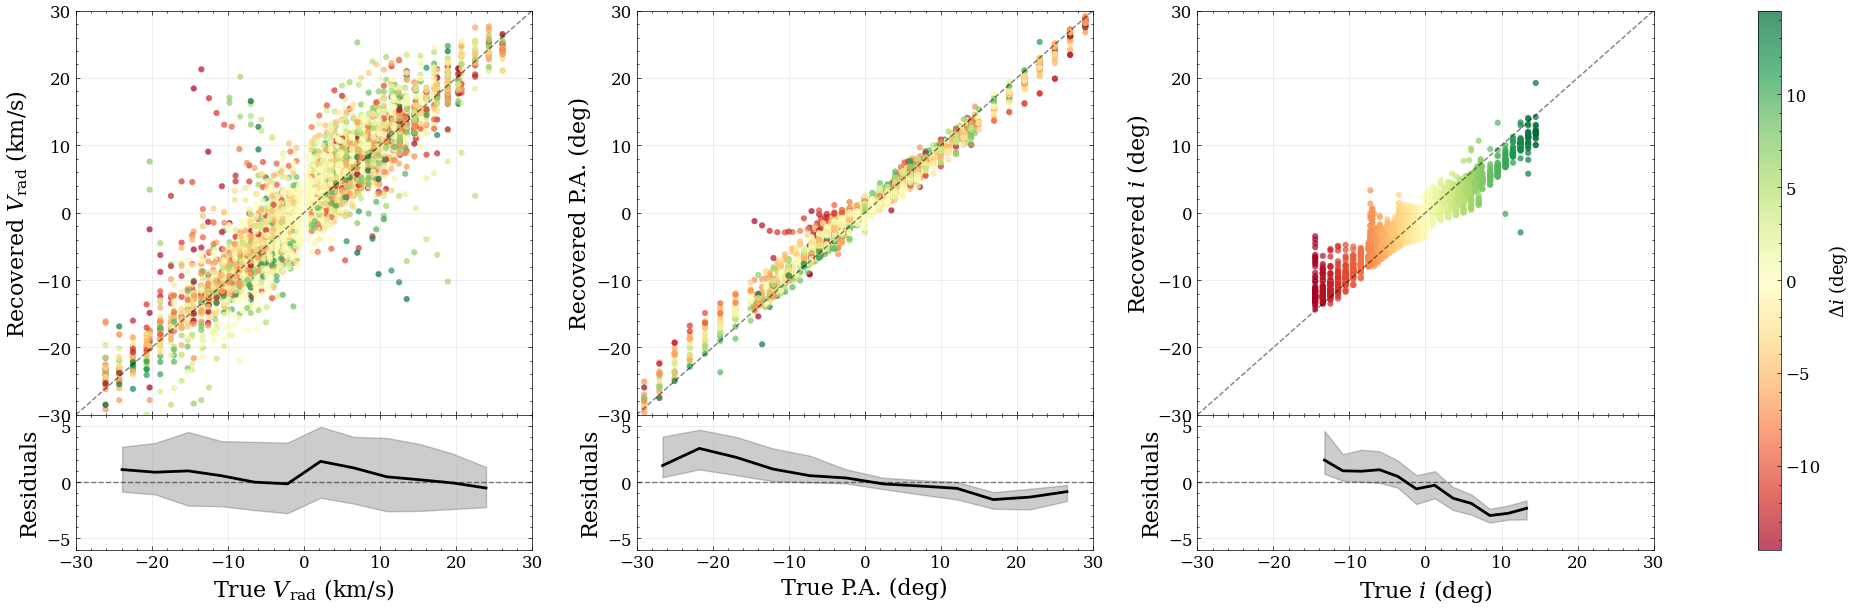

In [3]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm

# ==========================================
# 1. PATH CONFIG
# ==========================================
plt.style.use("/net/dataserver3/data/users/linn/pic_style/science3.mplstyle")
RING_MODEL_DIR = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/varied_inc/"
INITIAL_DIR    = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/varied_inc/initial/"

# ==========================================
# 2. FILENAME PARSER
# ==========================================
pat_fname = re.compile(
    r"^(?:\d+_)?ring_"
    r"v(?P<v>\d+)_R(?P<R>\d+)_"
    r"(?:(?:PAfixed)|PAk(?P<pa_k>-?\d*\.?\d+)_TP(?P<pa_tp>-?\d*\.?\d+))_"
    r"VR(?:(?:k(?P<vr_k>-?\d*\.?\d+)_TP(?P<vr_tp>-?\d*\.?\d+))|(?P<vr_fixed>0))_"
    r"INC(?P<inc>\d+)(?:k(?P<inc_k>-?\d*\.?\d+)_TP(?P<inc_tp>-?\d*\.?\d+))?"
    r"(?:_Res\d+)?"
)

# ==========================================
# 3. DATA LOADING
# ==========================================
def load_single_file(fname):
    m = pat_fname.match(fname)
    if not m: return None
    g = m.groupdict()

    inc_base = int(g["inc"]) if g.get("inc") else None
    inc_k    = float(g["inc_k"]) if g.get("inc_k") else 0.0
    inc_tp   = float(g["inc_tp"]) if g.get("inc_tp") else 0.0

    if inc_base == 75 and inc_k < 0:
        if not (np.isclose(inc_k, -0.05) and np.isclose(inc_tp, 450.0)):
            return None

    in_path = os.path.join(INITIAL_DIR, fname)
    if not os.path.exists(in_path): return None

    base, _ = os.path.splitext(fname)
    out_path = os.path.join(RING_MODEL_DIR, base + "_SNR10", "second_step_check_sinw", "rings_final2.txt")
    if not os.path.exists(out_path): return None

    # 使用 sep='\s+' 代替 delim_whitespace
    df_in  = pd.read_csv(in_path, sep='\s+')
    df_out = pd.read_csv(out_path, sep='\s+')

    n = min(len(df_in), len(df_out))
    delta_inc = df_in["INC(deg)"][:n].values - inc_base
    Measured_delta_inc=df_out["INC(deg)"][:n].values-inc_base
    df = pd.DataFrame({
        "Filename": fname,
        "True_VRAD": df_in["VRAD(km/s)"][:n].values,
        "Measured_VRAD": df_out["VRAD(km/s)"][:n].values,
        "True_PA": df_in["P.A.(deg)"][:n].values,
        "Measured_PA": df_out["P.A.(deg)"][:n].values,
        "True_INC": df_in["INC(deg)"][:n].values,
        "Measured_INC": df_out["INC(deg)"][:n].values,
        "Delta_INC": delta_inc,
        "Measured_delta_inc": Measured_delta_inc,
    })
    return df[df["True_VRAD"] != 0].reset_index(drop=True)

def load_all_data():
    dfs = []
    for fp in sorted(glob.glob(os.path.join(INITIAL_DIR, "*.txt"))):
        fname = os.path.basename(fp)
        if "v200" not in fname: continue
        df = load_single_file(fname)
        if df is not None: dfs.append(df)
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

# ==========================================
# 4. BIN STATS (Using Median and 16/84 Percentiles)
# ==========================================
def bin_stats(x, y, nbins=12):
    df = pd.DataFrame({"x": x, "y": y})
    df["res"] = df["y"] - df["x"]
    bins = np.linspace(df["x"].min(), df["x"].max(), nbins + 1)
    df["bin"] = pd.cut(df["x"], bins=bins, include_lowest=True)
    
    g = df.groupby("bin", observed=False)["res"]
    
    xc = 0.5 * (bins[:-1] + bins[1:])
    # 计算中位数, 16% 分位数 和 84% 分位数
    median = g.median().values
    low = g.quantile(0.16).values
    high = g.quantile(0.84).values
    
    return xc, median, low, high

# ==========================================
# 5. PANEL PLOTTER
# ==========================================
def plot_panel(ax_sc, ax_rs, df, xcol, ycol, label, is_pa, cmap, norm, is_inc=False):
    x = df[xcol] - 120 if is_pa else df[xcol]
    y = df[ycol] - 120 if is_pa else df[ycol]

    sc = ax_sc.scatter(x, y, c=df["Delta_INC"], cmap=cmap, norm=norm, s=20, alpha=0.7, edgecolor="none")

    # 获取分位数统计结果
    xc, mid, low, high = bin_stats(x, y)
    
    # 绘制中位数线和 16-84 填充区域
    ax_rs.plot(xc, mid, color="k", lw=2, label="Median")
    ax_rs.fill_between(xc, low, high, color="k", alpha=0.2, label="16th-84th Pctl")

    if is_inc:
        ax_sc.set_xlim(-30, 30); ax_sc.set_ylim(-30, 30)
        ax_sc.plot([-30, 30], [-30, 30], "k--", lw=1, alpha=0.5)
    else:
        ax_sc.set_xlim(-30, 30); ax_sc.set_ylim(-30, 30)
        ax_sc.plot([-30, 30], [-30, 30], "k--", lw=1, alpha=0.5)

    ax_sc.grid(alpha=0.3); ax_sc.set_ylabel(f"Recovered {label}")
    ax_sc.tick_params(labelbottom=False)
    
    ax_rs.set_ylim(-6, 6); ax_rs.axhline(0, ls="--", color="k", alpha=0.5)
    ax_rs.grid(alpha=0.3); ax_rs.set_xlabel(f"True {label}"); ax_rs.set_ylabel("Residuals")
    return sc

# ==========================================
# 6. 1×3 ROW FIGURE
# ==========================================
def plot_one_row_all(df_all, title):
    dmax = np.max(np.abs(df_all["Delta_INC"]))
    norm = TwoSlopeNorm(vmin=-dmax, vcenter=0.0, vmax=dmax)
    cmap = plt.get_cmap("RdYlGn")

    fig = plt.figure(figsize=(22, 7))
    fig.suptitle(title, fontsize=16, y=1.02)

    # 1行 4列: Vrad, PA, Inc, Colorbar
    outer = gridspec.GridSpec(1, 4, width_ratios=[1, 1, 1, 0.05], wspace=0.3)

    rows = [
        ("True_VRAD", "Measured_VRAD", r"$V_{\rm rad}$ (km/s)", False, False),
        ("True_PA",   "Measured_PA",  "P.A. (deg)",        True,  False),
        ("Delta_INC",  "Measured_delta_inc", "$i$ (deg)",         False, True),
    ]

    mappable = None
    for i, (xcol, ycol, label, is_pa, is_inc) in enumerate(rows):
        inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[0, i], height_ratios=[3, 1], hspace=0)
        ax_sc = fig.add_subplot(inner[0])
        ax_rs = fig.add_subplot(inner[1], sharex=ax_sc)

        mappable = plot_panel(ax_sc, ax_rs, df_all, xcol, ycol, label, is_pa, cmap, norm, is_inc=is_inc)
        #ax_sc.set_title(f"{label.split()[0]}", fontsize=14, fontweight="bold")

    if mappable is not None:
        cax = fig.add_subplot(outer[0, 3])
        plt.colorbar(mappable, cax=cax).set_label(r"$\Delta i$ (deg)", fontsize=13)

    plt.savefig("figure_varied_inc_vrad_pa_inc_row_median_inc_new_6.pdf", bbox_inches='tight')
    plt.show()

# ==========================================
# 7. MAIN
# ==========================================
if __name__ == "__main__":
    print("Loading data...")
    df_all = load_all_data()
    if not df_all.empty:
        print(f"Total points: {len(df_all)}")
        plot_one_row_all(df_all, "")
    else:
        print("Data empty.")

Loading data...
Total points: 4184


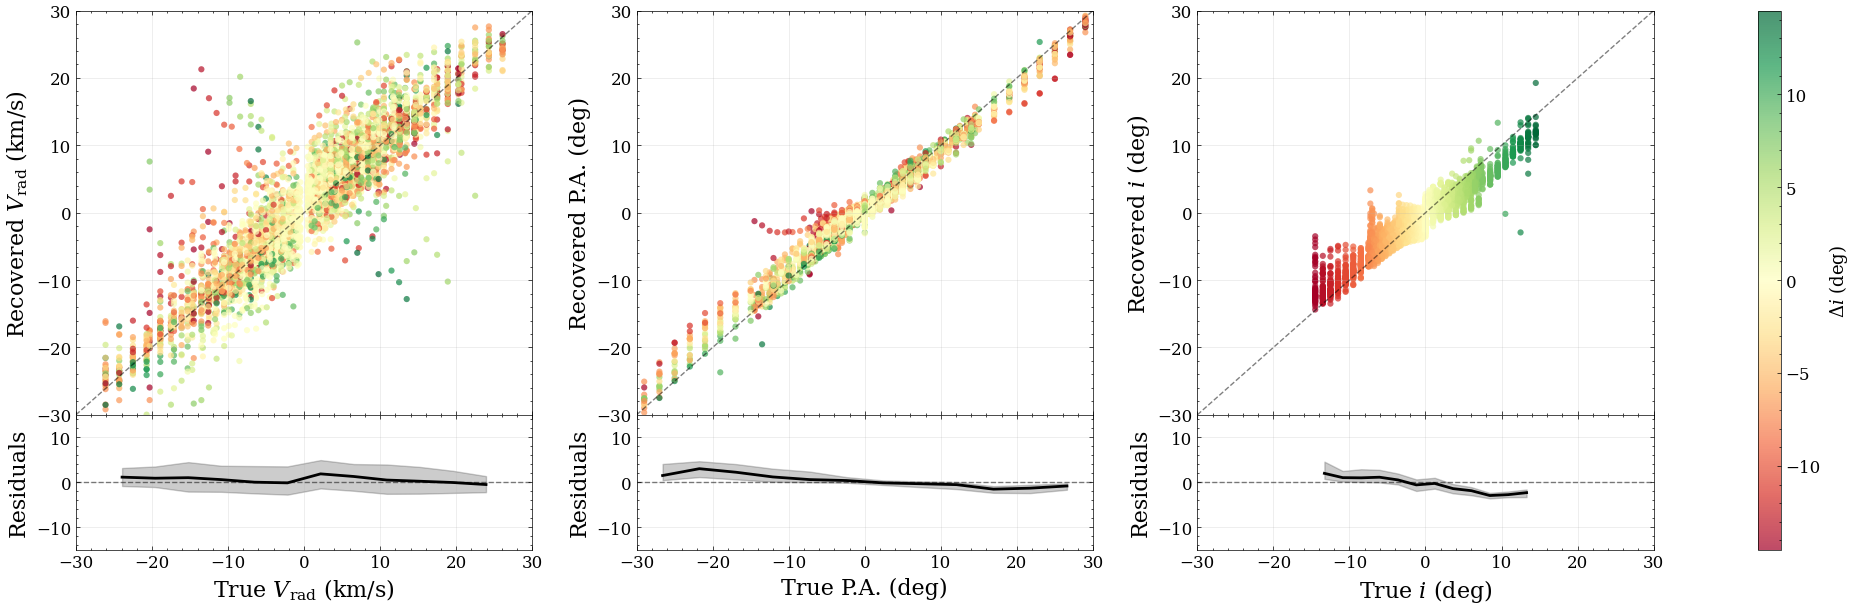

In [3]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm

# ==========================================
# 1. PATH CONFIG
# ==========================================
plt.style.use("/net/dataserver3/data/users/linn/pic_style/science3.mplstyle")
RING_MODEL_DIR = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/varied_inc/"
INITIAL_DIR    = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/varied_inc/initial/"

# ==========================================
# 2. FILENAME PARSER
# ==========================================
pat_fname = re.compile(
    r"^(?:\d+_)?ring_"
    r"v(?P<v>\d+)_R(?P<R>\d+)_"
    r"(?:(?:PAfixed)|PAk(?P<pa_k>-?\d*\.?\d+)_TP(?P<pa_tp>-?\d*\.?\d+))_"
    r"VR(?:(?:k(?P<vr_k>-?\d*\.?\d+)_TP(?P<vr_tp>-?\d*\.?\d+))|(?P<vr_fixed>0))_"
    r"INC(?P<inc>\d+)(?:k(?P<inc_k>-?\d*\.?\d+)_TP(?P<inc_tp>-?\d*\.?\d+))?"
    r"(?:_Res\d+)?"
)

# ==========================================
# 3. DATA LOADING
# ==========================================
def load_single_file(fname):
    m = pat_fname.match(fname)
    if not m: return None
    g = m.groupdict()

    inc_base = int(g["inc"]) if g.get("inc") else None
    inc_k    = float(g["inc_k"]) if g.get("inc_k") else 0.0
    inc_tp   = float(g["inc_tp"]) if g.get("inc_tp") else 0.0

    if inc_base == 75 and inc_k < 0:
        if not (np.isclose(inc_k, -0.05) and np.isclose(inc_tp, 450.0)):
            return None

    in_path = os.path.join(INITIAL_DIR, fname)
    if not os.path.exists(in_path): return None

    base, _ = os.path.splitext(fname)
    out_path = os.path.join(RING_MODEL_DIR, base + "_SNR10", "second_step_check_sinw", "rings_final2.txt")
    if not os.path.exists(out_path): return None

    # 使用 sep='\s+' 代替 delim_whitespace
    df_in  = pd.read_csv(in_path, sep='\s+')
    df_out = pd.read_csv(out_path, sep='\s+')

    n = min(len(df_in), len(df_out))
    delta_inc = df_in["INC(deg)"][:n].values - inc_base
    Measured_delta_inc=df_out["INC(deg)"][:n].values-inc_base
    df = pd.DataFrame({
        "Filename": fname,
        "True_VRAD": df_in["VRAD(km/s)"][:n].values,
        "Measured_VRAD": df_out["VRAD(km/s)"][:n].values,
        "True_PA": df_in["P.A.(deg)"][:n].values,
        "Measured_PA": df_out["P.A.(deg)"][:n].values,
        "True_INC": df_in["INC(deg)"][:n].values,
        "Measured_INC": df_out["INC(deg)"][:n].values,
        "Delta_INC": delta_inc,
        "Measured_delta_inc": Measured_delta_inc,
    })
    return df[df["True_VRAD"] != 0].reset_index(drop=True)

def load_all_data():
    dfs = []
    for fp in sorted(glob.glob(os.path.join(INITIAL_DIR, "*.txt"))):
        fname = os.path.basename(fp)
        if "v200" not in fname: continue
        df = load_single_file(fname)
        if df is not None: dfs.append(df)
    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

# ==========================================
# 4. BIN STATS (Using Median and 16/84 Percentiles)
# ==========================================
def bin_stats(x, y, nbins=12):
    df = pd.DataFrame({"x": x, "y": y})
    df["res"] = df["y"] - df["x"]
    bins = np.linspace(df["x"].min(), df["x"].max(), nbins + 1)
    df["bin"] = pd.cut(df["x"], bins=bins, include_lowest=True)
    
    g = df.groupby("bin", observed=False)["res"]
    
    xc = 0.5 * (bins[:-1] + bins[1:])
    # 计算中位数, 16% 分位数 和 84% 分位数
    median = g.median().values
    low = g.quantile(0.16).values
    high = g.quantile(0.84).values
    
    return xc, median, low, high

# ==========================================
# 5. PANEL PLOTTER
# ==========================================
def plot_panel(ax_sc, ax_rs, df, xcol, ycol, label, is_pa, cmap, norm, is_inc=False):
    x = df[xcol] - 120 if is_pa else df[xcol]
    y = df[ycol] - 120 if is_pa else df[ycol]

    sc = ax_sc.scatter(x, y, c=df["Delta_INC"], cmap=cmap, norm=norm, s=20, alpha=0.7, edgecolor="none")

    # 获取分位数统计结果
    xc, mid, low, high = bin_stats(x, y)
    
    # 绘制中位数线和 16-84 填充区域
    ax_rs.plot(xc, mid, color="k", lw=2, label="Median")
    ax_rs.fill_between(xc, low, high, color="k", alpha=0.2, label="16th-84th Pctl")

    if is_inc:
        ax_sc.set_xlim(-30, 30); ax_sc.set_ylim(-30, 30)
        ax_sc.plot([-30, 30], [-30, 30], "k--", lw=1, alpha=0.5)
        
    else:
        ax_sc.set_xlim(-30, 30); ax_sc.set_ylim(-30, 30)
        ax_sc.plot([-30, 30], [-30, 30], "k--", lw=1, alpha=0.5)

    ax_sc.grid(alpha=0.3); ax_sc.set_ylabel(f"Recovered {label}")
    ax_sc.tick_params(labelbottom=False)
    
    ax_rs.set_ylim(-15, 15); ax_rs.axhline(0, ls="--", color="k", alpha=0.5)
    ax_rs.grid(alpha=0.3); ax_rs.set_xlabel(f"True {label}"); ax_rs.set_ylabel("Residuals")
    return sc

# ==========================================
# 6. 1×3 ROW FIGURE
# ==========================================
def plot_one_row_all(df_all, title):
    dmax = np.max(np.abs(df_all["Delta_INC"]))
    norm = TwoSlopeNorm(vmin=-dmax, vcenter=0.0, vmax=dmax)
    cmap = plt.get_cmap("RdYlGn")

    fig = plt.figure(figsize=(22, 7))
    fig.suptitle(title, fontsize=16, y=1.02)

    # 1行 4列: Vrad, PA, Inc, Colorbar
    outer = gridspec.GridSpec(1, 4, width_ratios=[1, 1, 1, 0.05], wspace=0.3)

    rows = [
        ("True_VRAD", "Measured_VRAD", r"$V_{\rm rad}$ (km/s)", False, False),
        ("True_PA",   "Measured_PA",  "P.A. (deg)",        True,  False),
        ("Delta_INC",  "Measured_delta_inc", "$i$ (deg)",         False, True),
    ]

    mappable = None
    for i, (xcol, ycol, label, is_pa, is_inc) in enumerate(rows):
        inner = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=outer[0, i], height_ratios=[3, 1], hspace=0)
        ax_sc = fig.add_subplot(inner[0])
        ax_rs = fig.add_subplot(inner[1], sharex=ax_sc)

        mappable = plot_panel(ax_sc, ax_rs, df_all, xcol, ycol, label, is_pa, cmap, norm, is_inc=is_inc)
        #ax_sc.set_title(f"{label.split()[0]}", fontsize=14, fontweight="bold")

    if mappable is not None:
        cax = fig.add_subplot(outer[0, 3])
        plt.colorbar(mappable, cax=cax).set_label(r"$\Delta i$ (deg)", fontsize=13)

    plt.savefig("figure_varied_inc_vrad_pa_inc_row_median_inc_new.pdf", bbox_inches='tight')
    plt.show()

# ==========================================
# 7. MAIN
# ==========================================
if __name__ == "__main__":
    print("Loading data...")
    df_all = load_all_data()
    if not df_all.empty:
        print(f"Total points: {len(df_all)}")
        plot_one_row_all(df_all, "")
    else:
        print("Data empty.")

Loading data...
Total points: 4184


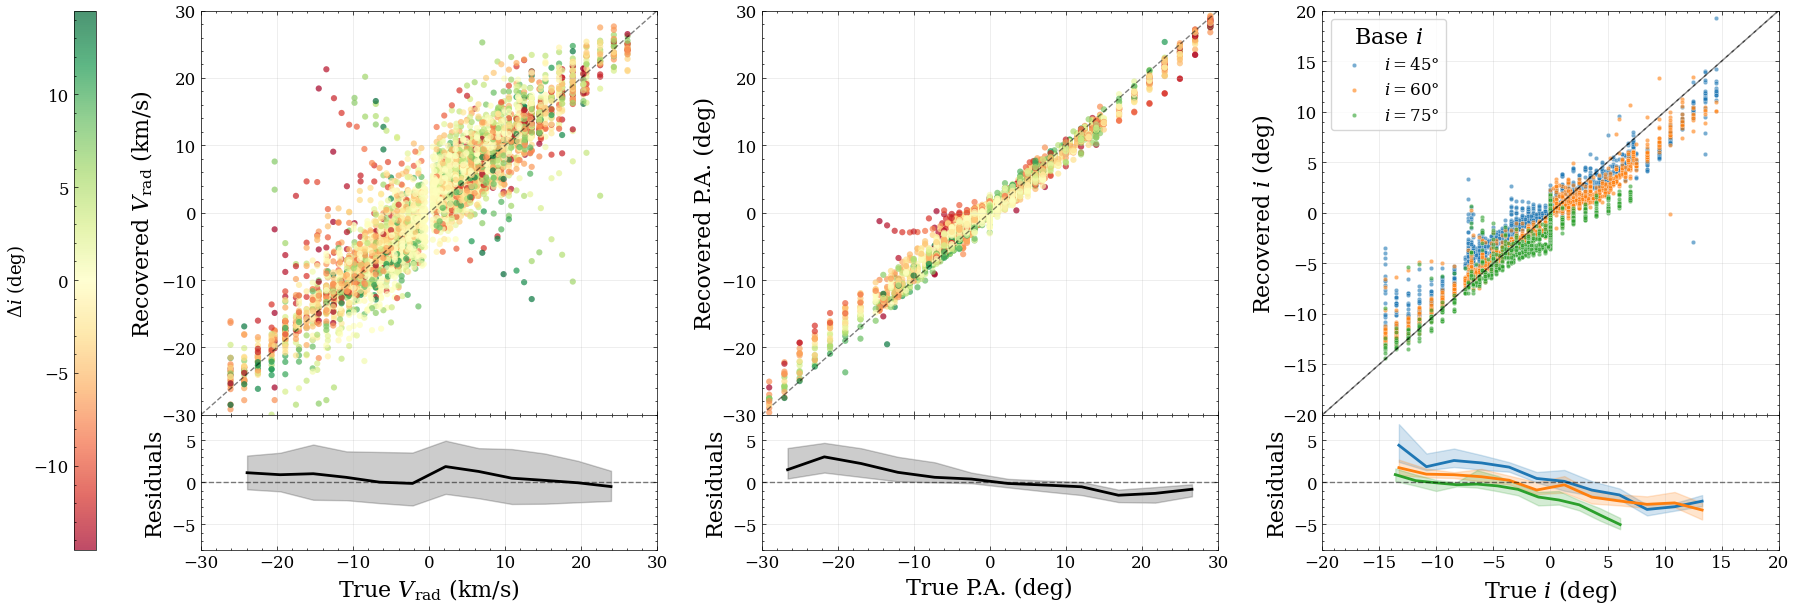

In [5]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm

# ==========================================
# 1. PATH CONFIG
# ==========================================
plt.style.use("/net/dataserver3/data/users/linn/pic_style/science3.mplstyle")

RING_MODEL_DIR = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/varied_inc/"
INITIAL_DIR    = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/varied_inc/initial/"


# ==========================================
# 2. FILENAME PARSER
# ==========================================
pat_fname = re.compile(
    r"^(?:\d+_)?ring_"
    r"v(?P<v>\d+)_R(?P<R>\d+)_"
    r"(?:(?:PAfixed)|PAk(?P<pa_k>-?\d*\.?\d+)_TP(?P<pa_tp>-?\d*\.?\d+))_"
    r"VR(?:(?:k(?P<vr_k>-?\d*\.?\d+)_TP(?P<vr_tp>-?\d*\.?\d+))|(?P<vr_fixed>0))_"
    r"INC(?P<inc>\d+)(?:k(?P<inc_k>-?\d*\.?\d+)_TP(?P<inc_tp>-?\d*\.?\d+))?"
    r"(?:_Res\d+)?"
)


# ==========================================
# 3. DATA LOADING
# ==========================================
def load_single_file(fname):

    m = pat_fname.match(fname)
    if not m:
        return None

    g = m.groupdict()

    inc_base = int(g["inc"]) if g.get("inc") else None
    inc_k    = float(g["inc_k"]) if g.get("inc_k") else 0.0
    inc_tp   = float(g["inc_tp"]) if g.get("inc_tp") else 0.0

    if inc_base == 75 and inc_k < 0:
        if not (np.isclose(inc_k, -0.05) and np.isclose(inc_tp, 450.0)):
            return None

    in_path = os.path.join(INITIAL_DIR, fname)
    if not os.path.exists(in_path):
        return None

    base, _ = os.path.splitext(fname)

    out_path = os.path.join(
        RING_MODEL_DIR,
        base + "_SNR10",
        "second_step_check_sinw",
        "rings_final2.txt"
    )

    if not os.path.exists(out_path):
        return None

    df_in  = pd.read_csv(in_path,  sep='\s+')
    df_out = pd.read_csv(out_path, sep='\s+')

    n = min(len(df_in), len(df_out))

    delta_inc = df_in["INC(deg)"][:n].values - inc_base
    measured_delta_inc = df_out["INC(deg)"][:n].values - inc_base

    df = pd.DataFrame({

        "Filename": fname,

        "Base_INC": inc_base,

        "True_VRAD": df_in["VRAD(km/s)"][:n].values,
        "Measured_VRAD": df_out["VRAD(km/s)"][:n].values,

        "True_PA": df_in["P.A.(deg)"][:n].values,
        "Measured_PA": df_out["P.A.(deg)"][:n].values,

        "True_INC": df_in["INC(deg)"][:n].values,
        "Measured_INC": df_out["INC(deg)"][:n].values,

        "Delta_INC": delta_inc,
        "Measured_delta_inc": measured_delta_inc
    })

    return df[df["True_VRAD"] != 0].reset_index(drop=True)


def load_all_data():

    dfs = []

    for fp in sorted(glob.glob(os.path.join(INITIAL_DIR, "*.txt"))):

        fname = os.path.basename(fp)

        if "v200" not in fname:
            continue

        df = load_single_file(fname)

        if df is not None:
            dfs.append(df)

    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()


# ==========================================
# 4. BIN STATS
# ==========================================
def bin_stats(x, y, nbins=12):

    df = pd.DataFrame({"x": x, "y": y})

    df["res"] = df["y"] - df["x"]

    bins = np.linspace(df["x"].min(), df["x"].max(), nbins + 1)

    df["bin"] = pd.cut(df["x"], bins=bins, include_lowest=True)

    g = df.groupby("bin", observed=False)["res"]

    xc = 0.5 * (bins[:-1] + bins[1:])

    median = g.median().values
    low    = g.quantile(0.16).values
    high   = g.quantile(0.84).values

    return xc, median, low, high


# ==========================================
# 5. PANEL PLOTTER
# ==========================================
def plot_panel(ax_sc, ax_rs, df, xcol, ycol, label, is_pa, cmap, norm, color_values, is_inc=False):

    x = df[xcol] - 120 if is_pa else df[xcol]
    y = df[ycol] - 120 if is_pa else df[ycol]

    sc = ax_sc.scatter(
        x,
        y,
        c=color_values,
        cmap=cmap,
        norm=norm,
        s=20,
        alpha=0.7,
        edgecolor="none"
    )

    xc, mid, low, high = bin_stats(x, y)

    ax_rs.plot(xc, mid, color="k", lw=2)
    ax_rs.fill_between(xc, low, high, color="k", alpha=0.2)

    ax_sc.set_xlim(-30, 30)
    ax_sc.set_ylim(-30, 30)

    ax_sc.plot([-30, 30], [-30, 30], "k--", lw=1, alpha=0.5)

    ax_sc.grid(alpha=0.3)
    ax_sc.set_ylabel(f"Recovered {label}")
    ax_sc.tick_params(labelbottom=False)

    ax_rs.set_ylim(-8, 8)
    ax_rs.axhline(0, ls="--", color="k", alpha=0.5)
    ax_rs.grid(alpha=0.3)

    ax_rs.set_xlabel(f"True {label}")
    ax_rs.set_ylabel("Residuals")

    return sc


# ==========================================
# 6. FIGURE
# ==========================================
def plot_one_row_all(df_all, title):

    dmax = np.max(np.abs(df_all["Delta_INC"]))

    norm = TwoSlopeNorm(vmin=-dmax, vcenter=0.0, vmax=dmax)

    cmap = plt.get_cmap("RdYlGn")

    fig = plt.figure(figsize=(22, 7))

    fig.suptitle(title, fontsize=16, y=1.02)

    outer = gridspec.GridSpec(1, 4, width_ratios=[0.05, 1, 1, 1], wspace=0.3)

    rows = [

        ("True_VRAD", "Measured_VRAD", r"$V_{\rm rad}$ (km/s)", False, False),

        ("True_PA",   "Measured_PA",  "P.A. (deg)", True, False),

        ("Delta_INC", "Measured_delta_inc", "$i$ (deg)", False, True)

    ]

    mappable = None

    for i, (xcol, ycol, label, is_pa, is_inc) in enumerate(rows):

        inner = gridspec.GridSpecFromSubplotSpec(
            2, 1,
            subplot_spec=outer[0, i+1],
            height_ratios=[3, 1],
            hspace=0
        )

        ax_sc = fig.add_subplot(inner[0])
        ax_rs = fig.add_subplot(inner[1], sharex=ax_sc)

        # 左和中 panel
        if i < 2:

            color_values = df_all["Delta_INC"]

            mappable = plot_panel(
                ax_sc, ax_rs,
                df_all,
                xcol, ycol,
                label,
                is_pa,
                cmap,
                norm,
                color_values,
                is_inc=is_inc
            )

        # 右 panel
        else:

            colors = {

                45: "#1f77b4",
                60: "#ff7f0e",
                75: "#2ca02c"

            }

            for inc in [45, 60, 75]:
            
                sub = df_all[df_all["Base_INC"] == inc]
            
                x = sub[xcol]
                y = sub[ycol]
            
                ax_sc.scatter(
                    x,
                    y,
                    color=colors[inc],
                    s=10,
                    alpha=0.6,
                    edgecolor="white",
                    linewidth=0.3,
                    label=f"$i={inc}$°",rasterized=True
                )
            
                # 各自的 residual fit
                xc, mid, low, high = bin_stats(x, y)
            
                ax_rs.plot(
                    xc,
                    mid,
                    color=colors[inc],
                    lw=2
                )
            
                ax_rs.fill_between(
                    xc,
                    low,
                    high,
                    color=colors[inc],
                    alpha=0.2
                )

            # xc, mid, low, high = bin_stats(df_all[xcol], df_all[ycol])

            # ax_rs.plot(xc, mid, color="k", lw=2)
            # ax_rs.fill_between(xc, low, high, color="k", alpha=0.2)
            
            ax_sc.set_xlim(-30, 30)
            ax_sc.set_ylim(-30, 30)
            ax_sc.plot([-30, 30], [-30, 30], "k--", lw=1, alpha=0.5)

            if is_inc:
                ax_sc.set_xlim(-20, 20)
                ax_sc.set_ylim(-20, 20)
                ax_sc.plot([-20, 20], [-20, 20], "k--", lw=1, alpha=0.5)
                

            ax_sc.grid(alpha=0.3)
            ax_sc.set_ylabel(f"Recovered {label}")
            ax_sc.tick_params(labelbottom=False)

            ax_rs.set_ylim(-8, 8)
            ax_rs.axhline(0, ls="--", color="k", alpha=0.5)
            ax_rs.grid(alpha=0.3)

            ax_rs.set_xlabel(f"True {label}")
            ax_rs.set_ylabel("Residuals")

            ax_sc.legend(title="Base $i$",frameon=True,fontsize=12)

    if mappable is not None:

        cax = fig.add_subplot(outer[0, 0])

        cbar = plt.colorbar(mappable, cax=cax)
        cbar.set_label(r"$\Delta i$ (deg)", fontsize=13)
        
        cbar.ax.yaxis.set_label_position("left")
        cbar.ax.yaxis.set_ticks_position("left")

    plt.savefig(
        "figure_varied_inc_vrad_pa_inc_row_median_inc_new_6.pdf",dpi=400,
        bbox_inches='tight'
    )

    plt.show()


# ==========================================
# 7. MAIN
# ==========================================
if __name__ == "__main__":

    print("Loading data...")

    df_all = load_all_data()

    if not df_all.empty:

        print(f"Total points: {len(df_all)}")

        plot_one_row_all(df_all, "")

    else:

        print("Data empty.")

In [ ]:
    45: dict(color="#1f77b4", marker="o", label="$i=45$"),
    60: dict(color="#ff7f0e", marker="s", label="$i=60$"),
    75: dict(color="#2ca02c", marker="^", label="$i=75$"),
}

Loading data...
Total points: 4184


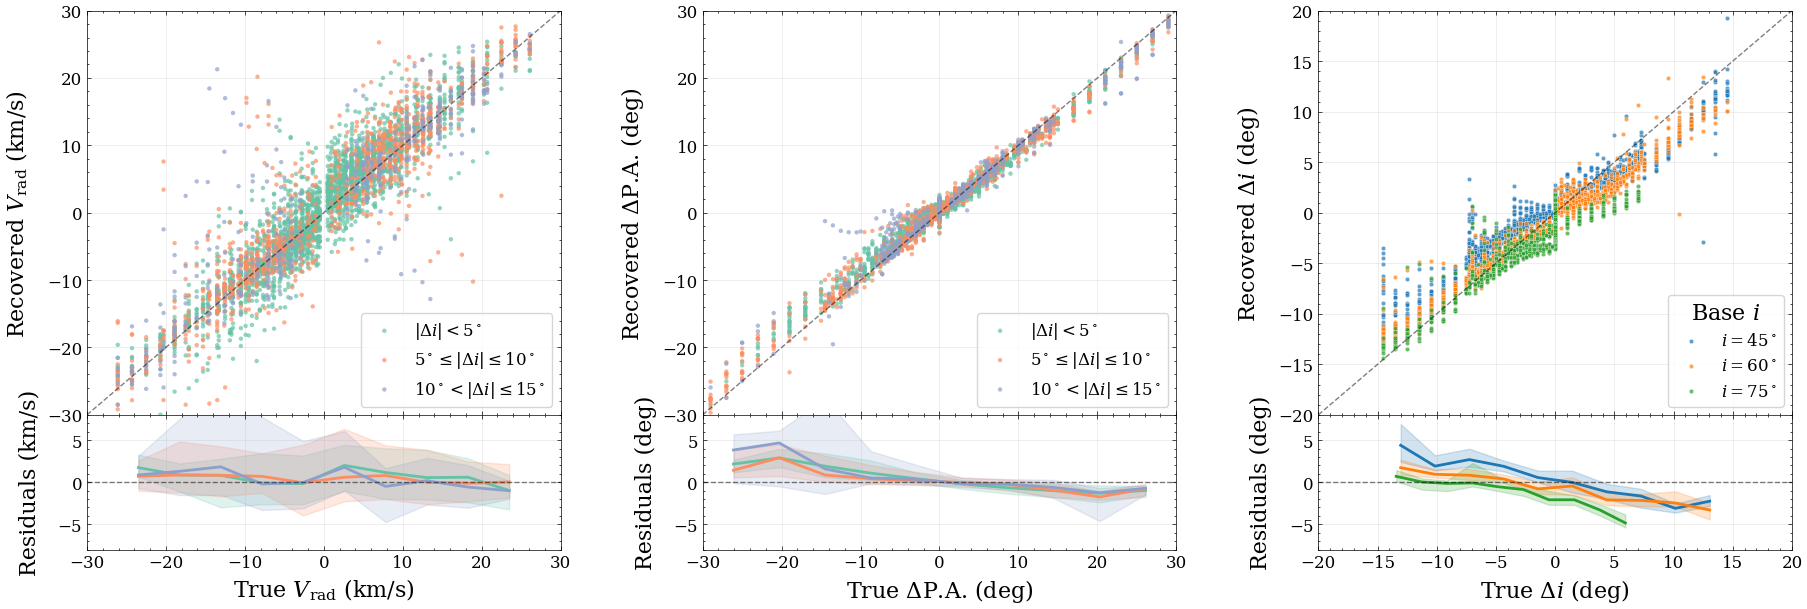

In [7]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ==========================================
# 1. PATH CONFIG
# ==========================================
plt.style.use("/net/dataserver3/data/users/linn/pic_style/science3.mplstyle")

RING_MODEL_DIR = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/varied_inc/"
INITIAL_DIR    = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/varied_inc/initial/"
LABELPAD = 12


# ==========================================
# 2. FILENAME PARSER
# ==========================================
pat_fname = re.compile(
    r"^(?:\d+_)?ring_"
    r"v(?P<v>\d+)_R(?P<R>\d+)_"
    r"(?:(?:PAfixed)|PAk(?P<pa_k>-?\d*\.?\d+)_TP(?P<pa_tp>-?\d*\.?\d+))_"
    r"VR(?:(?:k(?P<vr_k>-?\d*\.?\d+)_TP(?P<vr_tp>-?\d*\.?\d+))|(?P<vr_fixed>0))_"
    r"INC(?P<inc>\d+)(?:k(?P<inc_k>-?\d*\.?\d+)_TP(?P<inc_tp>-?\d*\.?\d+))?"
    r"(?:_Res\d+)?"
)


# ==========================================
# 3. DELTA INC BINNING
# ==========================================
DINC_BIN_COLORS = {
    r"$|\Delta i|<5^\circ$": "#66c2a5",
    r"$5^\circ\leq|\Delta i|\leq10^\circ$": "#fc8d62",
    r"$10^\circ<|\Delta i|\leq15^\circ$": "#8da0cb",
}

def delta_inc_bin(abs_delta):
    if abs_delta < 5:
        return r"$|\Delta i|<5^\circ$"
    elif abs_delta <= 10:
        return r"$5^\circ\leq|\Delta i|\leq10^\circ$"
    elif abs_delta <= 15:
        return r"$10^\circ<|\Delta i|\leq15^\circ$"
    else:
        return None


# ==========================================
# 4. DATA LOADING
# ==========================================
def load_single_file(fname):

    m = pat_fname.match(fname)
    if not m:
        return None

    g = m.groupdict()

    inc_base = int(g["inc"]) if g.get("inc") else None
    inc_k    = float(g["inc_k"]) if g.get("inc_k") else 0.0
    inc_tp   = float(g["inc_tp"]) if g.get("inc_tp") else 0.0

    if inc_base == 75 and inc_k < 0:
        if not (np.isclose(inc_k, -0.05) and np.isclose(inc_tp, 450.0)):
            return None

    in_path = os.path.join(INITIAL_DIR, fname)
    if not os.path.exists(in_path):
        return None

    base, _ = os.path.splitext(fname)

    out_path = os.path.join(
        RING_MODEL_DIR,
        base + "_SNR10",
        "second_step_check_sinw",
        "rings_final2.txt"
    )

    if not os.path.exists(out_path):
        return None

    df_in  = pd.read_csv(in_path, sep=r"\s+")
    df_out = pd.read_csv(out_path, sep=r"\s+")

    n = min(len(df_in), len(df_out))

    delta_inc = df_in["INC(deg)"][:n].values - inc_base
    measured_delta_inc = df_out["INC(deg)"][:n].values - inc_base

    df = pd.DataFrame({
        "Filename": fname,
        "Base_INC": inc_base,

        "True_VRAD": df_in["VRAD(km/s)"][:n].values,
        "Measured_VRAD": df_out["VRAD(km/s)"][:n].values,

        "True_PA": df_in["P.A.(deg)"][:n].values,
        "Measured_PA": df_out["P.A.(deg)"][:n].values,

        "True_INC": df_in["INC(deg)"][:n].values,
        "Measured_INC": df_out["INC(deg)"][:n].values,

        "Delta_INC": delta_inc,
        "Measured_delta_inc": measured_delta_inc
    })

    return df[df["True_VRAD"] != 0].reset_index(drop=True)


def load_all_data():

    dfs = []

    for fp in sorted(glob.glob(os.path.join(INITIAL_DIR, "*.txt"))):

        fname = os.path.basename(fp)

        if "v200" not in fname:
            continue

        df = load_single_file(fname)

        if df is not None and not df.empty:
            dfs.append(df)

    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()


# ==========================================
# 5. BIN STATS
# ==========================================
def bin_stats(x, y, nbins=10):

    df = pd.DataFrame({"x": x, "y": y}).dropna()

    if df.empty:
        return None, None, None, None

    df["res"] = df["y"] - df["x"]

    xmin, xmax = df["x"].min(), df["x"].max()

    if np.isclose(xmin, xmax):
        return None, None, None, None

    bins = np.linspace(xmin, xmax, nbins + 1)

    df["bin"] = pd.cut(df["x"], bins=bins, include_lowest=True)

    g = df.groupby("bin", observed=False)["res"]

    xc = 0.5 * (bins[:-1] + bins[1:])

    median = g.median().values
    low    = g.quantile(0.16).values
    high   = g.quantile(0.84).values

    return xc, median, low, high


# ==========================================
# 6. PANEL PLOTTER: VRAD AND PA
# ==========================================
def plot_panel_dinc_bins(ax_sc, ax_rs, df, xcol, ycol, label, is_pa):

    x = df[xcol].values - 120 if is_pa else df[xcol].values
    y = df[ycol].values - 120 if is_pa else df[ycol].values

    df_plot = pd.DataFrame({
        "x": x,
        "y": y,
        "abs_dinc": np.abs(df["Delta_INC"].values)
    })

    df_plot["dinc_bin"] = df_plot["abs_dinc"].apply(delta_inc_bin)
    df_plot = df_plot.dropna(subset=["dinc_bin"])
    
    for b, col in DINC_BIN_COLORS.items():
        
        sub = df_plot[df_plot["dinc_bin"] == b]

        if sub.empty:
            continue

        ax_sc.scatter(
            sub["x"],
            sub["y"],
            color=col,
            s=10,
            alpha=0.7,
            edgecolor="none",
            label=b,
            rasterized=True
        )

        if len(sub) >= 5:
            xc, mid, low, high = bin_stats(sub["x"], sub["y"])

            if xc is not None:
                ax_rs.plot(xc, mid, color=col, lw=2, label=b)
                ax_rs.fill_between(xc, low, high, color=col, alpha=0.2)
    ax_sc.legend(frameon=True, fontsize=12, loc="lower right")

    ax_sc.set_xlim(-30, 30)
    ax_sc.set_ylim(-30, 30)
    ax_sc.plot([-30, 30], [-30, 30], "k--", lw=1, alpha=0.5)

    ax_sc.grid(alpha=0.3)
    ax_sc.set_ylabel(f"Recovered {label}", labelpad=LABELPAD)
    ax_sc.tick_params(labelbottom=False)

    ax_rs.set_ylim(-8, 8)
    ax_rs.axhline(0, ls="--", color="k", alpha=0.5)
    ax_rs.grid(alpha=0.3)

    ax_rs.set_xlabel(f"True {label}")
    if label.startswith(r"$V_{\rm rad}$"):
        ax_rs.set_ylabel(r"Residuals (km/s)", labelpad=LABELPAD)
    else:
        ax_rs.set_ylabel(r"Residuals (deg)", labelpad=LABELPAD)




# ==========================================
# 7. PANEL PLOTTER: INCLINATION
# ==========================================
def plot_panel_inc(ax_sc, ax_rs, df_all):

    colors = {
        45: "#1f77b4",
        60: "#ff7f0e",
        75: "#2ca02c"
    }

    for inc in [45, 60, 75]:

        sub = df_all[df_all["Base_INC"] == inc]

        if sub.empty:
            continue

        x = sub["Delta_INC"].values
        y = sub["Measured_delta_inc"].values

        ax_sc.scatter(
            x,
            y,
            color=colors[inc],
            s=10,
            alpha=0.7,
            edgecolor="white",
            linewidth=0.3,
            label=f"$i={inc}^\\circ$",
            rasterized=True
        )

        if len(sub) >= 5:
            xc, mid, low, high = bin_stats(x, y)

            if xc is not None:
                ax_rs.plot(xc, mid, color=colors[inc], lw=2)
                ax_rs.fill_between(xc, low, high, color=colors[inc], alpha=0.2)

    ax_sc.set_xlim(-20, 20)
    ax_sc.set_ylim(-20, 20)
    ax_sc.plot([-20, 20], [-20, 20], "k--", lw=1, alpha=0.5)

    ax_sc.grid(alpha=0.3)
    ax_sc.set_ylabel(r"Recovered $\Delta i$ (deg)", labelpad=LABELPAD)
    ax_sc.tick_params(labelbottom=False)

    ax_rs.set_ylim(-8, 8)
    ax_rs.axhline(0, ls="--", color="k", alpha=0.5)
    ax_rs.grid(alpha=0.3)

    ax_rs.set_xlabel(r"True $\Delta i$ (deg)")
    ax_rs.set_ylabel("Residuals (deg)", labelpad=LABELPAD)

    ax_sc.legend(title="Base $i$", frameon=True, fontsize=12,loc="lower right")


# ==========================================
# 8. FIGURE
# ==========================================
def plot_one_row_all(df_all, title=""):

    fig = plt.figure(figsize=(22, 7))

    if title:
        fig.suptitle(title, fontsize=16, y=1.02)

    outer = gridspec.GridSpec(
        1, 3,
        width_ratios=[1, 1, 1],
        wspace=0.3
    )

    rows = [
        ("True_VRAD", "Measured_VRAD", r"$V_{\rm rad}$ (km/s)", False),
        ("True_PA",   "Measured_PA",   "$\Delta$P.A. (deg)", True),
    ]

    for i, (xcol, ycol, label, is_pa) in enumerate(rows):

        inner = gridspec.GridSpecFromSubplotSpec(
            2, 1,
            subplot_spec=outer[0, i],
            height_ratios=[3, 1],
            hspace=0
        )

        ax_sc = fig.add_subplot(inner[0])
        ax_rs = fig.add_subplot(inner[1], sharex=ax_sc)

        plot_panel_dinc_bins(
            ax_sc=ax_sc,
            ax_rs=ax_rs,
            df=df_all,
            xcol=xcol,
            ycol=ycol,
            label=label,
            is_pa=is_pa
        )

    inner = gridspec.GridSpecFromSubplotSpec(
        2, 1,
        subplot_spec=outer[0, 2],
        height_ratios=[3, 1],
        hspace=0
    )

    ax_sc = fig.add_subplot(inner[0])
    ax_rs = fig.add_subplot(inner[1], sharex=ax_sc)

    plot_panel_inc(ax_sc, ax_rs, df_all)

    plt.savefig(
        "figure_varied_inc_vrad_pa_inc_row_median_dinc_bins.pdf",
        dpi=400,
        bbox_inches="tight"
    )

    plt.show()


# ==========================================
# 9. MAIN
# ==========================================
if __name__ == "__main__":

    print("Loading data...")

    df_all = load_all_data()

    if not df_all.empty:

        print(f"Total points: {len(df_all)}")

        plot_one_row_all(df_all, "")

    else:

        print("Data empty.")

In [2]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

plt.rcParams.update({
    "font.size": 14,
    "axes.labelsize": 16,
    "axes.titlesize": 16,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 13,
})

plt.style.use("/net/dataserver3/data/users/linn/pic_style/science3.mplstyle")

# ==========================================
# 1. PATH CONFIG
# ==========================================
RING_BASE      = "/net/dataserver3/data/users/linn/para_Barolo/test_more_model/"
RING_MODEL1123 = os.path.join(RING_BASE, "model1123")
RING_REFEREE   = os.path.join(RING_BASE, "refereerequire")

INITIAL_BASE   = "/net/dataserver3/data/users/linn/para_initial/test_more_model/"
INITIAL_1123   = os.path.join(INITIAL_BASE, "model1123")
INITIAL_REFEREE = os.path.join(INITIAL_BASE, "refereerequire")

INC_STYLES = {
    20: dict(color="#9467bd", marker="D", label=r"$i=20^\circ$"),
    45: dict(color="#1f77b4", marker="o", label=r"$i=45^\circ$"),
    60: dict(color="#ff7f0e", marker="s", label=r"$i=60^\circ$"),
    75: dict(color="#2ca02c", marker="^", label=r"$i=75^\circ$"),
}

# ==========================================
# 2. Filename parser
# ==========================================
pat_fname = re.compile(
    r"^(?:\d+_)?ring_"
    r"v(?P<v>\d+)_R(?P<R>\d+)_"
    r"(?:(?:PAfixed)|PAk(?P<pa_k>-?\d*\.?\d+)_TP(?P<pa_tp>\d+))_"
    r"VR(?:(?:k(?P<vr_k>-?\d*\.?\d+)_TP(?P<vr_tp>\d+))|(?P<vr_fixed>0))_"
    r"INC(?P<inc>\d+)"
    r"(?:_SNR(?P<snr>\d+))?"
)

def get_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return df[c]
    raise KeyError(f"Cannot find any column from {candidates}. Available columns: {list(df.columns)}")

def compute_sign(pa_k, vr_k):
    if pa_k is None or vr_k is None or vr_k == 0:
        return 0
    return 1 if pa_k * vr_k > 0 else -1

def find_initial_file(file_name, ring_root):
    base_name = os.path.splitext(file_name)[0]

    if "model1123" in ring_root:
        roots = [INITIAL_1123, INITIAL_BASE]
    elif "refereerequire" in ring_root:
        roots = [INITIAL_REFEREE, INITIAL_BASE]
    else:
        roots = [INITIAL_BASE]

    candidates = []
    for root in roots:
        candidates += [
            os.path.join(root, file_name),
            os.path.join(root, base_name + ".txt"),
            os.path.join(root, base_name),
        ]

    for p in candidates:
        if os.path.exists(p) and os.path.isfile(p):
            return p

    return None

def find_output_file(file_name, ring_root):
    base_name = os.path.splitext(file_name)[0]

    candidates = [
        os.path.join(ring_root, base_name, "second_step_check_sinw", "rings_final2.txt"),
        os.path.join(ring_root, base_name, "rings_final2.txt"),
        os.path.join(ring_root, file_name, "second_step_check_sinw", "rings_final2.txt"),
        os.path.join(ring_root, file_name, "rings_final2.txt"),
    ]

    for p in candidates:
        if os.path.exists(p):
            return p

    return None

# ==========================================
# 3. Data loading
# ==========================================
def load_single_file(file_name, ring_root):
    m = pat_fname.match(os.path.splitext(file_name)[0])
    if not m:
        return None

    g = m.groupdict()

    # 只保留 SNR10
    if g.get("snr") != "10":
        return None

    pa_k = float(g["pa_k"]) if g.get("pa_k") else None
    vr_k = float(g["vr_k"]) if g.get("vr_k") else None
    inc_val = int(g["inc"])

    in_path = find_initial_file(file_name, ring_root)
    if in_path is None:
        print(f"[skip] no initial file: {file_name}")
        return None

    out_path = find_output_file(file_name, ring_root)
    if out_path is None:
        print(f"[skip] no rings_final2.txt: {file_name}")
        return None

    try:
        inputf = pd.read_csv(in_path, delimiter=r"\s+")
        outputf = pd.read_csv(out_path, delimiter=r"\s+")
    except Exception as e:
        print(f"[skip] read failed: {file_name} -> {e}")
        return None

    n = min(len(inputf), len(outputf))

    true_pa = get_col(inputf, ["P.A.(deg)", "PA(deg)", "P.A.", "PA"])[:n].values
    meas_pa = get_col(outputf, ["P.A.(deg)", "PA(deg)", "P.A.", "PA"])[:n].values

    try:
        true_inc = get_col(inputf, ["INC(deg)", "INCL(deg)", "Inclination(deg)", "INC", "INCL"])[:n].values
    except KeyError:
        true_inc = np.full(n, inc_val)

    meas_inc = get_col(outputf, ["INC(deg)", "INCL(deg)", "Inclination(deg)", "INC", "INCL"])[:n].values

    df = pd.DataFrame({
        "True_PA": true_pa,
        "Measured_PA": meas_pa,
        "True_INC": true_inc,
        "Measured_INC": meas_inc,
        "INC": inc_val,
        "pa_k": pa_k,
        "vr_k": vr_k,
        "sign": compute_sign(pa_k, vr_k),
        "file": file_name,
        "ring_root": ring_root,
    })

    return df.reset_index(drop=True)

def collect_names_from_root(root):
    """
    同时支持：
    1. root 下有 .txt 初始配置/文件名
    2. root 下直接是运行结果文件夹
    """
    names = []

    for fp in glob.glob(os.path.join(root, "*SNR10*")):
        name = os.path.basename(fp)

        if "v200" not in name:
            continue

        if not any(f"INC{i}" in name for i in [20, 45, 60, 75]):
            continue

        # 如果是 .txt，保留文件名；如果是目录，直接用目录名
        names.append(name)

    return sorted(set(names))

def load_all_data():
    df_list = []

    roots = [
        RING_MODEL1123,
        RING_BASE,
        RING_REFEREE,
    ]

    for root in roots:
        for fname in collect_names_from_root(root):
            df = load_single_file(fname, root)
            if df is not None:
                df_list.append(df)

    return pd.concat(df_list, ignore_index=True) if df_list else pd.DataFrame()

# ==========================================
# 4. Plotting
# ==========================================
def bin_stats(x_plot, y_plot, nbins=10):
    temp_df = pd.DataFrame({
        "x": np.array(x_plot),
        "y": np.array(y_plot),
    }).dropna()

    temp_df["res"] = temp_df["y"] - temp_df["x"]

    if temp_df.empty:
        return [], [], [], []

    if temp_df["x"].min() == temp_df["x"].max():
        return [], [], [], []

    bin_edges = np.linspace(temp_df["x"].min(), temp_df["x"].max(), nbins + 1)
    temp_df["bin_cat"] = pd.cut(temp_df["x"], bins=bin_edges, include_lowest=True)

    grouped = temp_df.groupby("bin_cat", observed=False)["res"]

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    median_res = grouped.median().values
    q16_res = grouped.quantile(0.16).values
    q84_res = grouped.quantile(0.84).values

    return bin_centers, median_res, q16_res, q84_res

def plot_combined_panel(ax_scatter, ax_resid, x, y, inc_col, label_prefix, is_pa=False, show_legend=False):
    if x.empty or y.empty:
        return

    for inc, style in INC_STYLES.items():
        sub = inc_col[inc_col == inc].index
        if len(sub) == 0:
            continue

        x_sub = x.loc[sub]
        y_sub = y.loc[sub]

        if is_pa:
            x_plot = x_sub - 120
            y_plot = y_sub - 120
        else:
            x_plot = x_sub
            y_plot = y_sub

        ax_scatter.scatter(
            x_plot, y_plot,
            s=12,
            alpha=0.65,
            edgecolor="white",
            linewidth=0.3,
            rasterized=True,
            **style
        )

        bin_centers, med, q16, q84 = bin_stats(x_plot, y_plot)
        if len(bin_centers) > 0:
            ax_resid.plot(bin_centers, med, **style)
            fill_style = {k: v for k, v in style.items() if k not in ["marker", "label"]}
            ax_resid.fill_between(bin_centers, q16, q84, alpha=0.2, **fill_style)

    if is_pa:
        ax_scatter.set_xlim(-32, 32)
        ax_scatter.set_ylim(-32, 32)
        ax_resid.set_ylim(-6, 6)
    else:
        ax_scatter.set_xlim(15, 80)
        ax_scatter.set_ylim(15, 80)
        ax_resid.set_ylim(-10, 10)

    xmin, xmax = ax_scatter.get_xlim()
    ax_scatter.plot([xmin, xmax], [xmin, xmax], "k--", lw=1, alpha=0.5)

    ax_scatter.grid(True, alpha=0.3)
    ax_scatter.set_ylabel(f"Recovered {label_prefix}")
    ax_scatter.tick_params(labelbottom=False)

    if show_legend:
        ax_scatter.legend(loc="best", fontsize=13, frameon=True)

    ax_resid.axhline(0, color="k", linestyle="--", lw=1, alpha=0.5)
    ax_resid.grid(True, alpha=0.3)
    ax_resid.set_xlabel(f"True {label_prefix}")
    ax_resid.set_ylabel("Residuals")

def plot_PA_INC_all_data(df_all):
    fig = plt.figure(figsize=(12, 8))

    outer_grid = gridspec.GridSpec(
        1, 2,
        wspace=0.25
    )

    panels = [
        (r"P.A. (deg)", "True_PA", "Measured_PA", True),
        (r"$i$ (deg)", "True_INC", "Measured_INC", False),
    ]

    for col_idx, (label, xcol, ycol, is_pa) in enumerate(panels):
        inner_grid = gridspec.GridSpecFromSubplotSpec(
            2, 1,
            subplot_spec=outer_grid[col_idx],
            height_ratios=[3, 1],
            hspace=0.0
        )

        ax_sc = fig.add_subplot(inner_grid[0])
        ax_rs = fig.add_subplot(inner_grid[1], sharex=ax_sc)

        plot_combined_panel(
            ax_sc,
            ax_rs,
            df_all[xcol],
            df_all[ycol],
            df_all["INC"],
            label_prefix=label,
            is_pa=is_pa,
            show_legend=(col_idx == 0)
        )

        ax_sc.set_title(label, fontsize=16, fontweight="bold")

    #plt.savefig("figure_PA_INC_all_SNR10.pdf", dpi=300, bbox_inches="tight")
    plt.show()

# ==========================================
# 5. Main
# ==========================================
if __name__ == "__main__":
    df_all = load_all_data()

    print("Loaded rows:", len(df_all))
    if not df_all.empty:
        print(df_all.groupby("INC")["file"].nunique())

        plot_PA_INC_all_data(df_all)
    else:
        print("No data loaded.")

[skip] no initial file: ring_v200_R50_PAfixed_VR0_INC75_SNR10
[skip] no initial file: ring_v200_R50_PAfixed_VR0_INC20_SNR10
Loaded rows: 0
No data loaded.
